In [ ]:
from matplotlib import rcParams, rc
rcParams.update({'figure.autolayout': True})
import torch
import matplotlib.pyplot as plt
import numpy as np
import math
from utils import Params
from tqdm import tqdm
from GLOnet_thinfilm import GLOnet
import scipy.io as io
from TMM import *
from material_database import MatDatabase
from scipy.optimize import fsolve
import os
import random

### Optimization for HR sensor


In [6]:
Vis = [0.45, 0.575]
params = Params()
params.N_layers = 7
params.pol = 'TM'
params.k =  2 * math.pi / torch.linspace(Vis[0], Vis[1], 100)
params.theta =   torch.tensor([0.]) 
params.n_top = torch.tensor([1.46]) #sustrato
params.n_bot = torch.tensor([1.]) #superestrato

params.user_define = False
## choose from material database
params.sensor = True
if params.sensor:
    params.materials_full_A =['TiO2_solgel_P45_agua', 'SiO2_solgel_P42_agua', 'ZrO2_solgel_P26_agua','TiO2_solgel_densa', 'SiO2_solgel_densa', 'ZrO2_solgel_densa']
    params.materials_full_B =['TiO2_solgel_P45_tolueno', 'SiO2_solgel_P42_tolueno', 'ZrO2_solgel_P26_tolueno','TiO2_solgel_densa', 'SiO2_solgel_densa', 'ZrO2_solgel_densa']
    params.materials_empty =['TiO2_solgel_P45_aire', 'SiO2_solgel_P42_aire', 'ZrO2_solgel_P26_aire','TiO2_solgel_densa', 'SiO2_solgel_densa','ZrO2_solgel_densa']
    #params.materials_full =['TiO2_solgel_P471_ll', 'SiO2_solgel_P363_ll', 'ZrO2_solgel_P296_ll']#,'TiO2_solgel_densa', 'SiO2_solgel_densa', 'ZrO2_solgel_densa']
    #params.materials_empty =['TiO2_solgel_P471_v', 'SiO2_solgel_P363_v', 'ZrO2_solgel_P296_v']#,'TiO2_solgel_densa', 'SiO2_solgel_densa','ZrO2_solgel_densa']
    params.matdatabase_full_A = MatDatabase(params.materials_full_A)
    params.matdatabase_full_B = MatDatabase(params.materials_full_B)
    params.matdatabase_empty = MatDatabase(params.materials_empty)
    params.n_database_full_A = params.matdatabase_full_A.interp_wv(2 * math.pi/params.k, params.materials_full_A, False) # number of materials x number of frequencies
    params.n_database_full_B = params.matdatabase_full_B.interp_wv(2 * math.pi/params.k, params.materials_full_B, False) # number of materials x number of frequencies
    params.n_database_empty = params.matdatabase_empty.interp_wv(2 * math.pi/params.k, params.materials_empty, False) # number of materials x number of frequencies
    params.M_materials = params.n_database_empty.size(0)
else:
    params.materials =['TiO2_solgel_P45_v', 'SiO2_solgel_P42_v', 'ZrO2_solgel_P26_v','TiO2_solgel_densa', 'SiO2_solgel_densa', 'ZrO2_solgel_densa']
    params.matdatabase = MatDatabase(params.materials)
    params.n_database = params.matdatabase.interp_wv(2 * math.pi/params.k, params.materials, False) # number of materials x number of frequencies
    params.M_materials = params.n_database.size(0)
    params.target_reflection = torch.zeros((1, params.k.size(0), 1, 1)) # 1 x number of frequencies x number of angles x (number of pol or 1)
    params.target_reflection[:,42:100, :, :] = 1

params.thickness_sup = 0.2 # [um]
params.thickness_l = 0.02 # [um]

params.net = 'Res'
params.res_layers = 16 
params.res_dim = 256 
params.noise_dim = 16 


In [ ]:
params.res_layers = 16 
params.res_dim = 256 
params.noise_dim = 16 

params.lr = 0.01
params.beta1 = 0.95
params.beta2 = 0.95
params.weight_decay = 0.000001
params.step_size = 700
params.gamma = 0.3
params.numIter = 700
params.alpha_sup = 3.5
params.batch_size = 300
params.sigma = 0.8
params.ruta = 'sensor/2025/porosidades_tesis/serie_PD/N7/aire_agua_tolueno/opt'
os.makedirs(params.ruta, exist_ok=True)

100%|██████████| 700/700 [02:30<00:00,  4.66it/s]
/home/aviaggio/GLOnet_for_thin_film/GLOnet_thinfilm.py:330: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (20, 5))
100%|██████████| 700/700 [01:42<00:00,  6.84it/s]


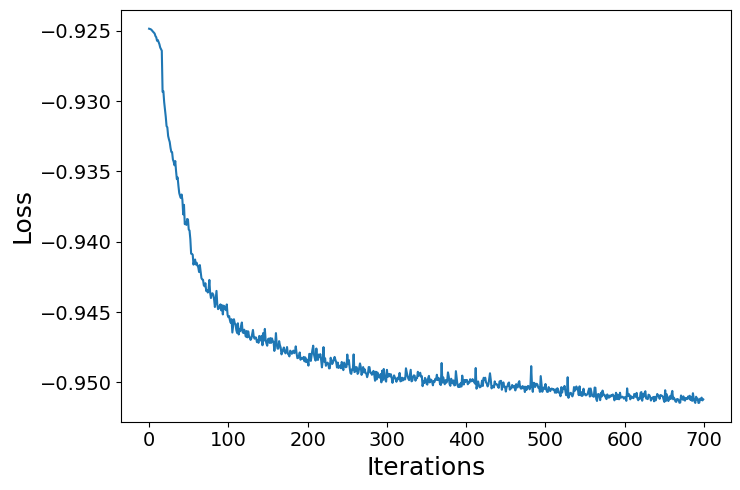

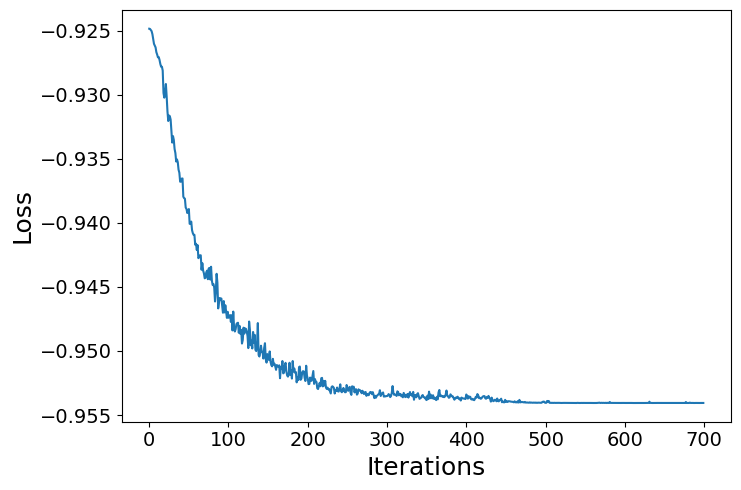

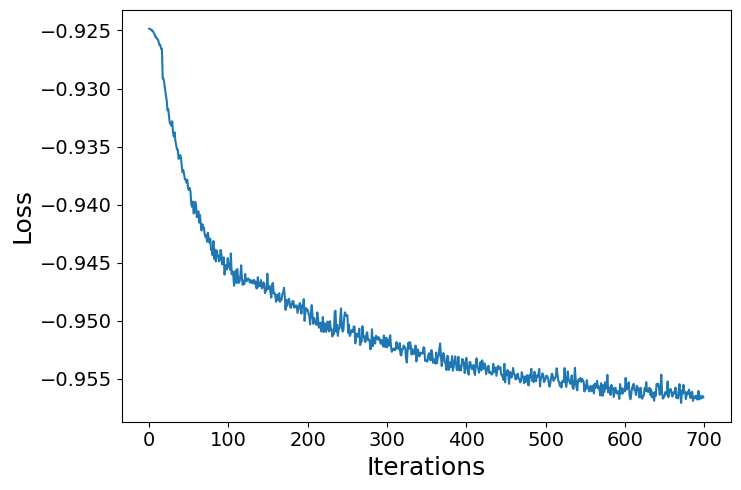

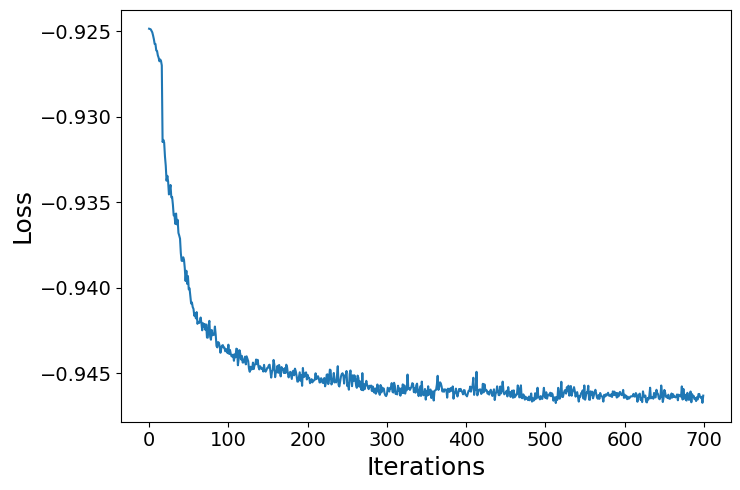

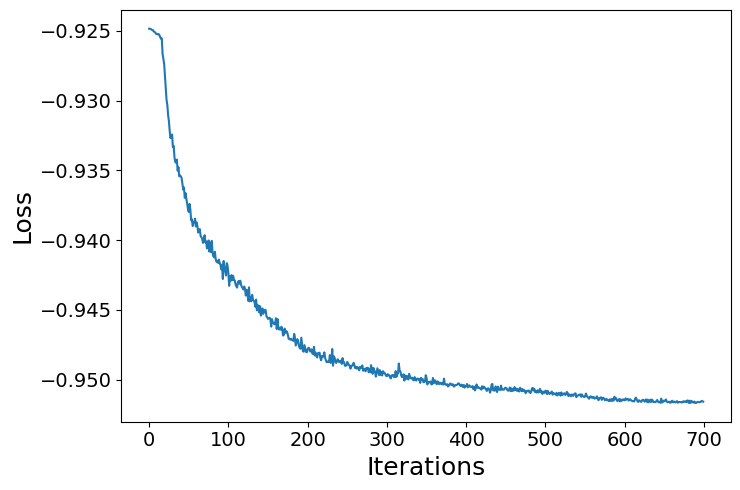

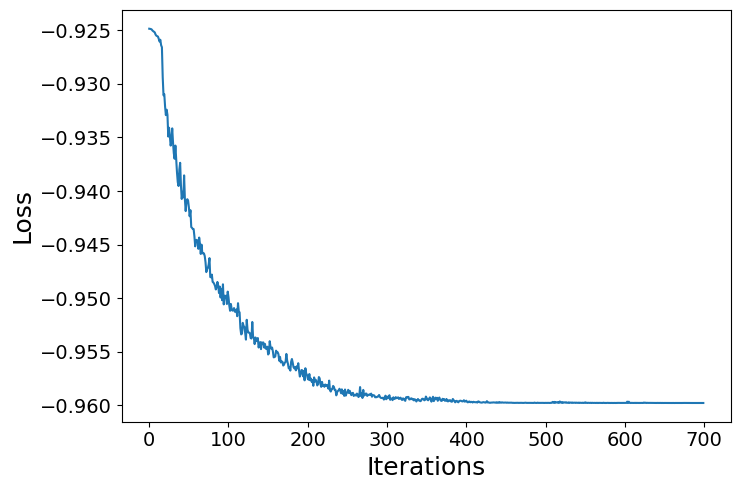

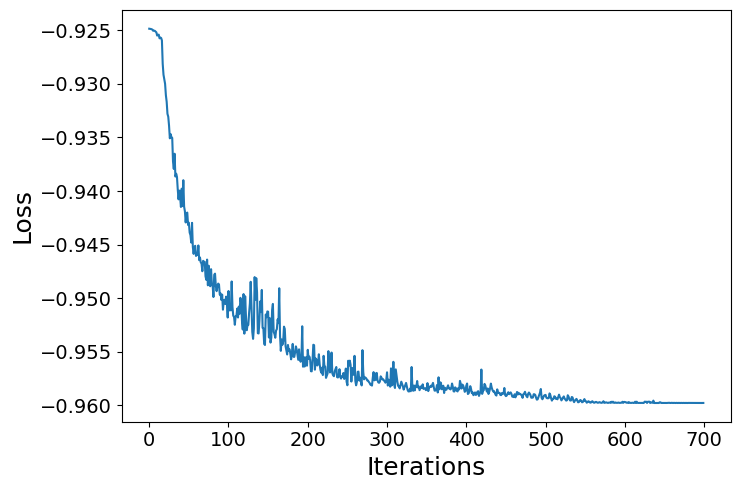

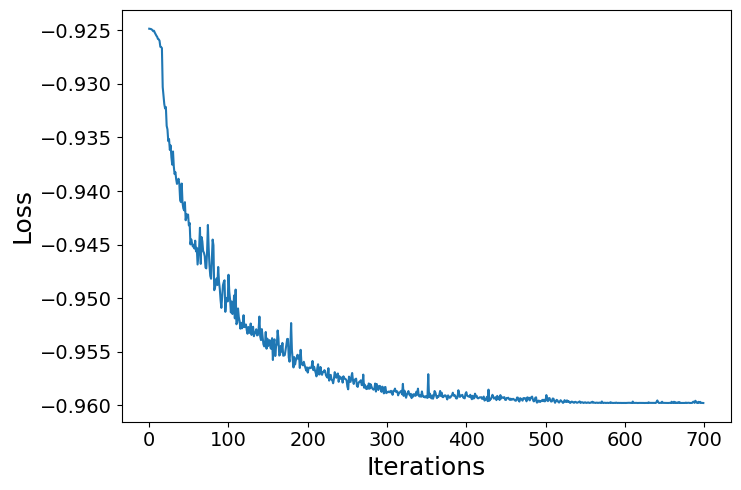

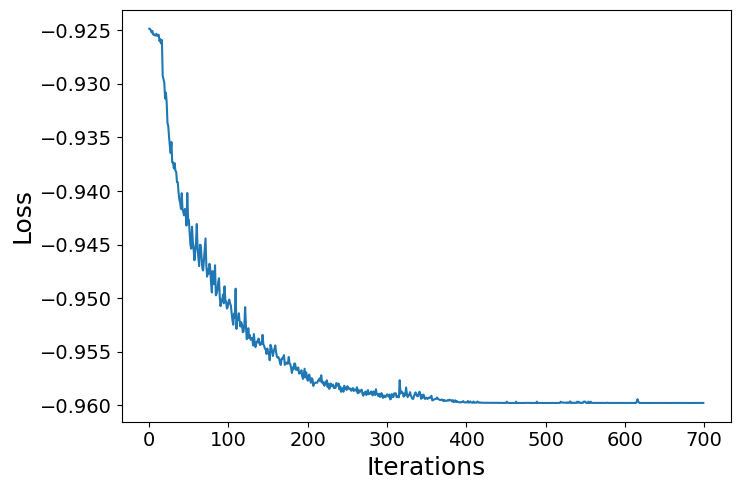

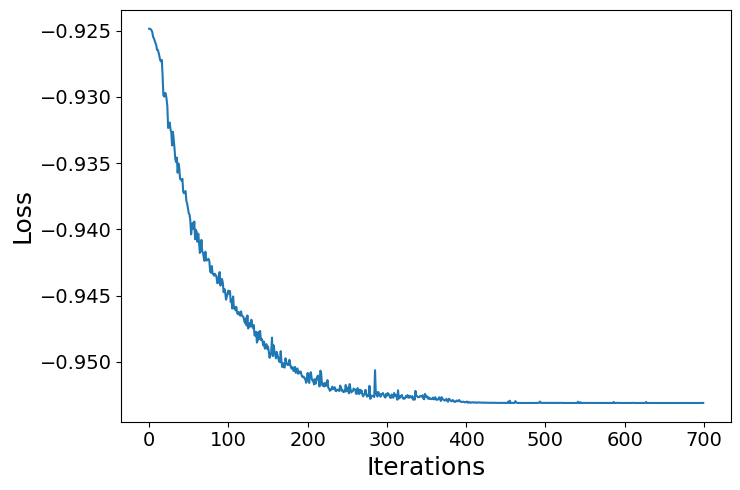

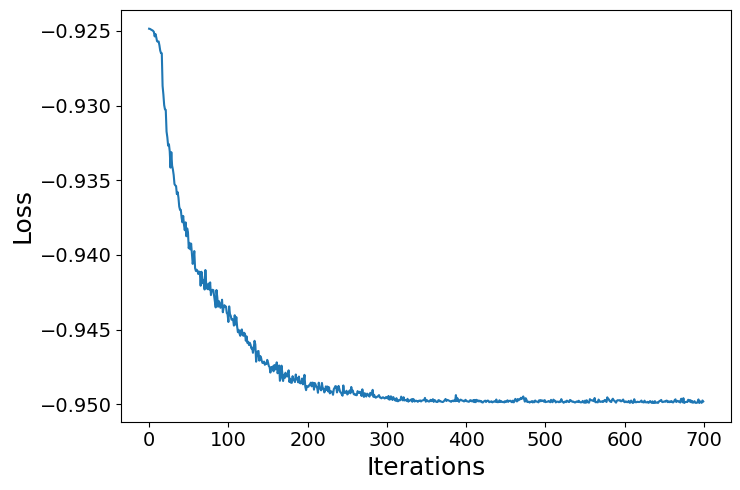

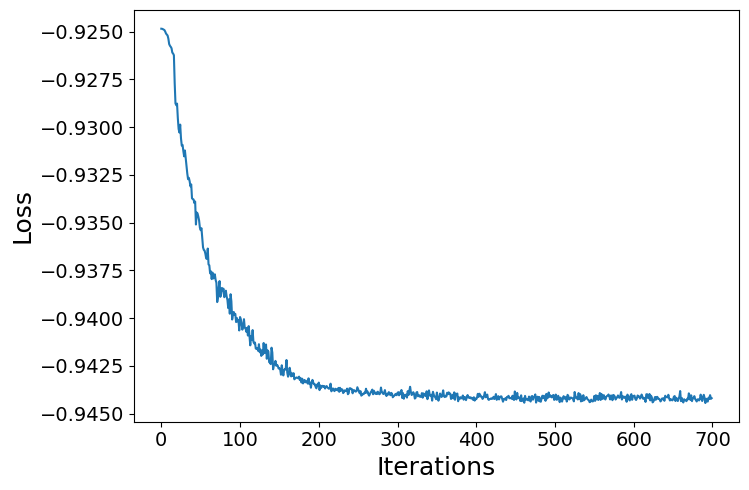

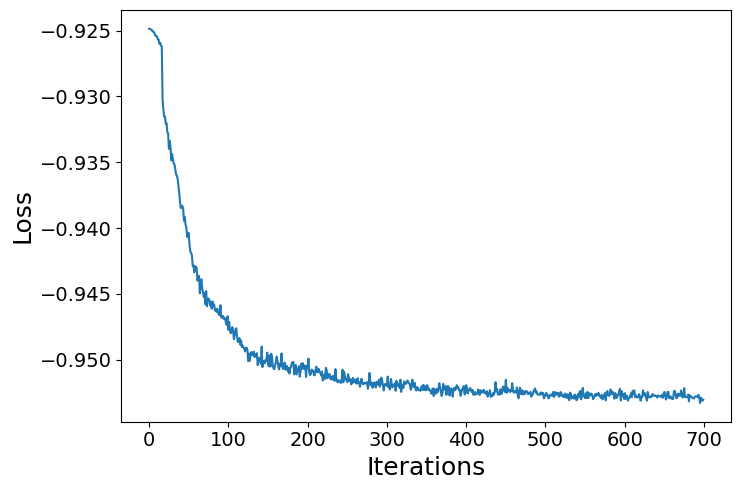

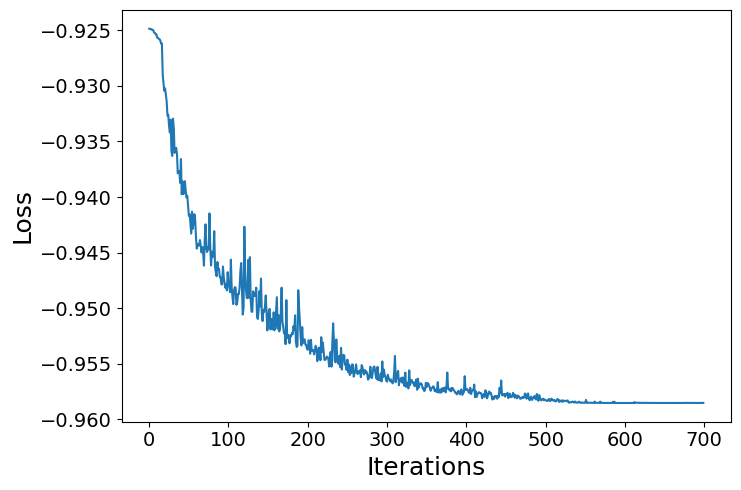

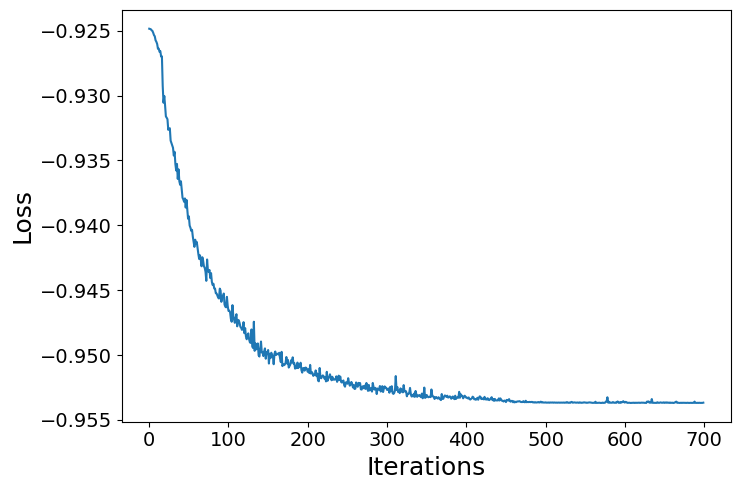

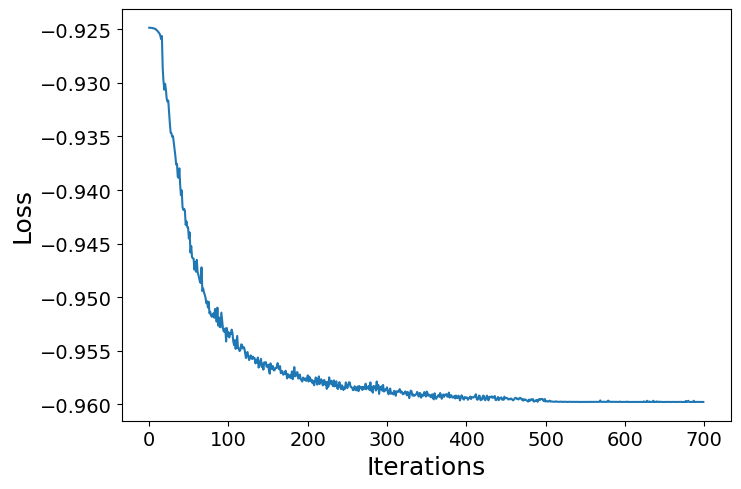

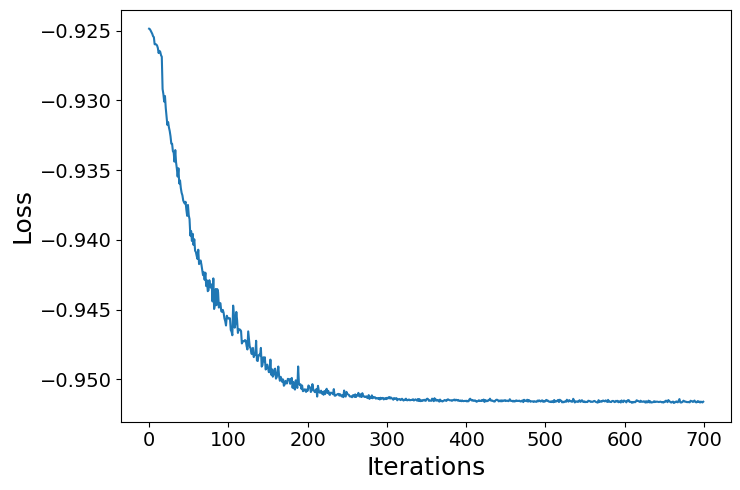

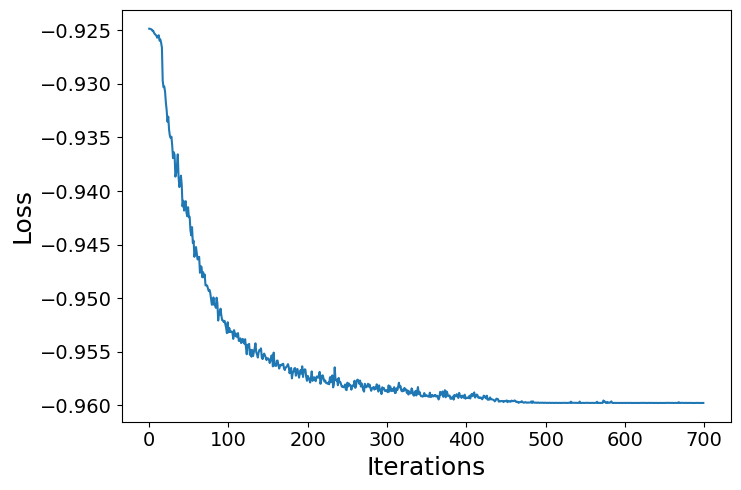

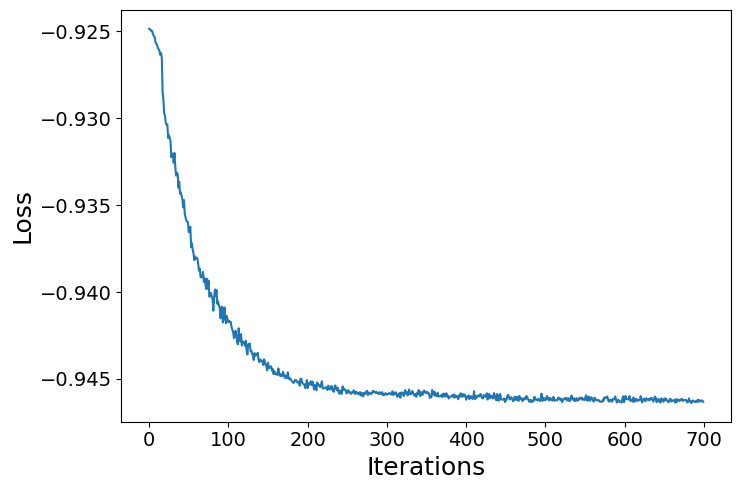

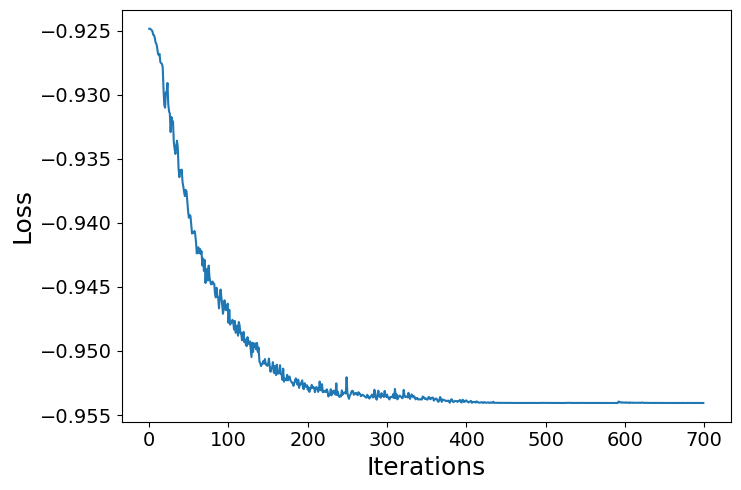

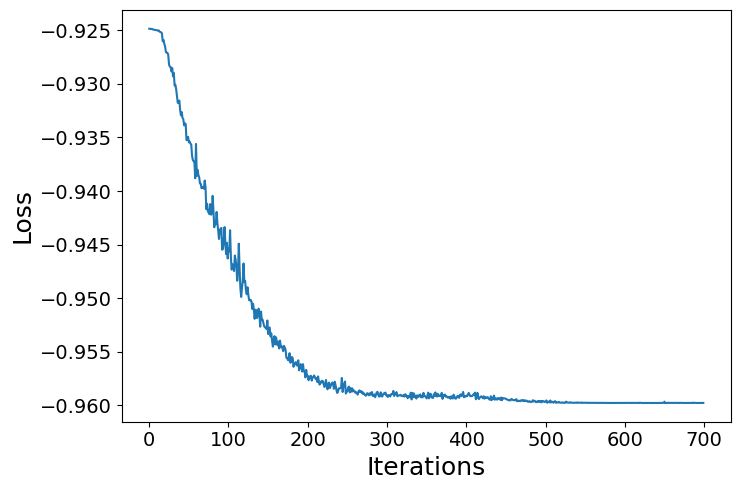

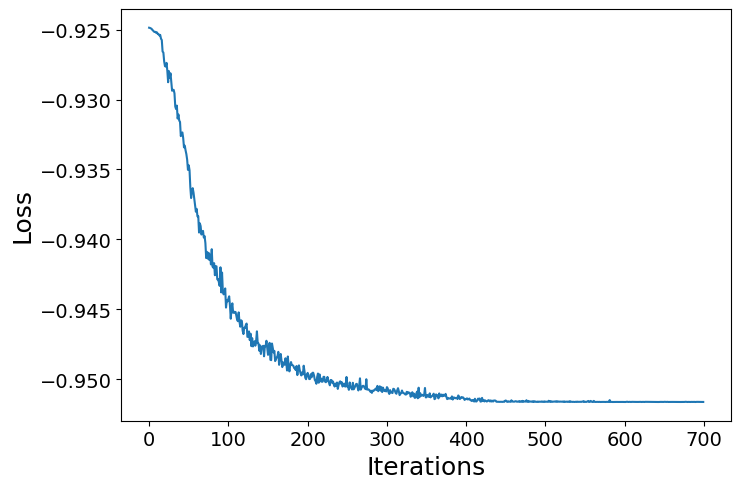

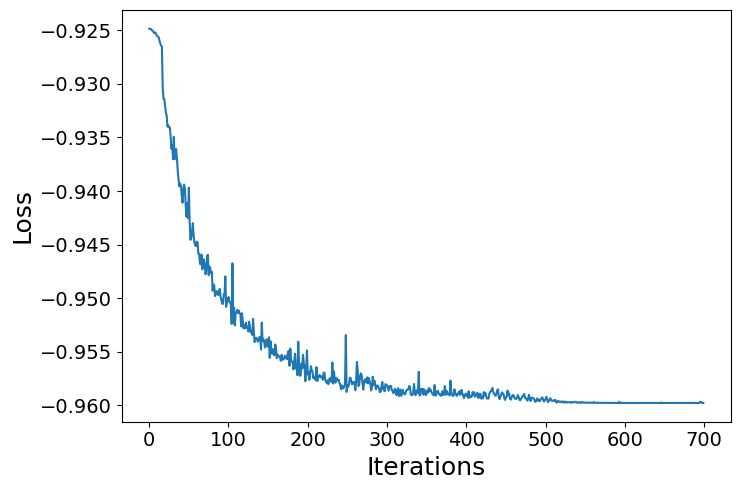

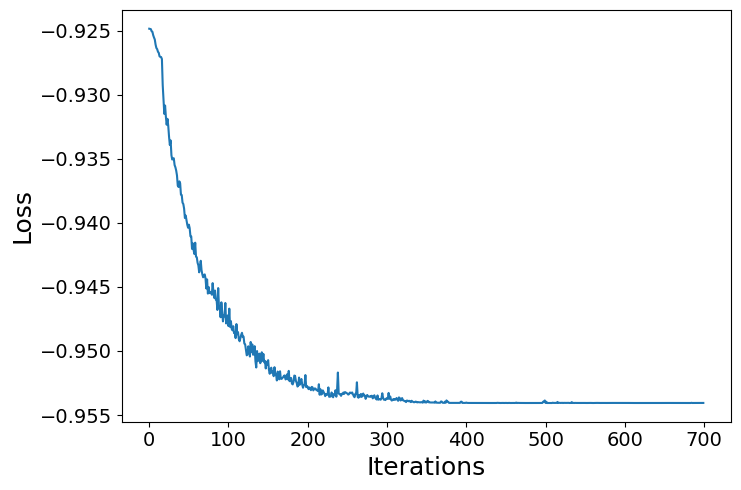

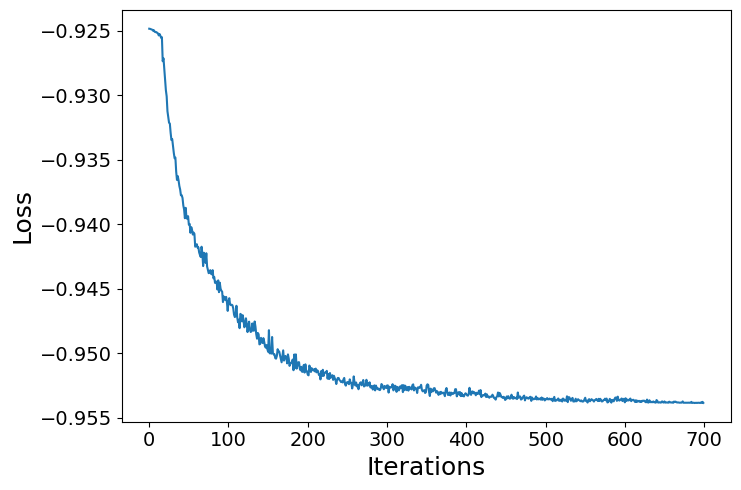

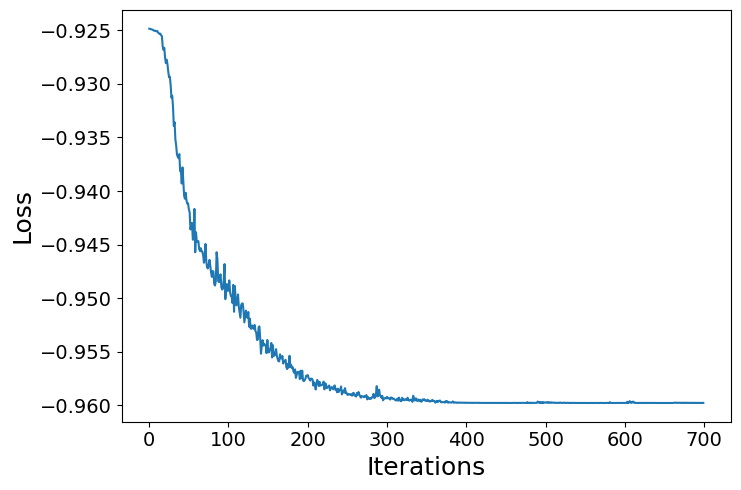

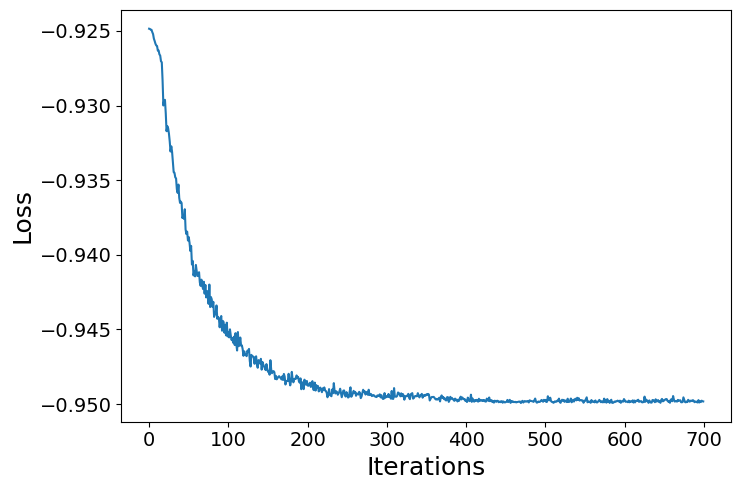

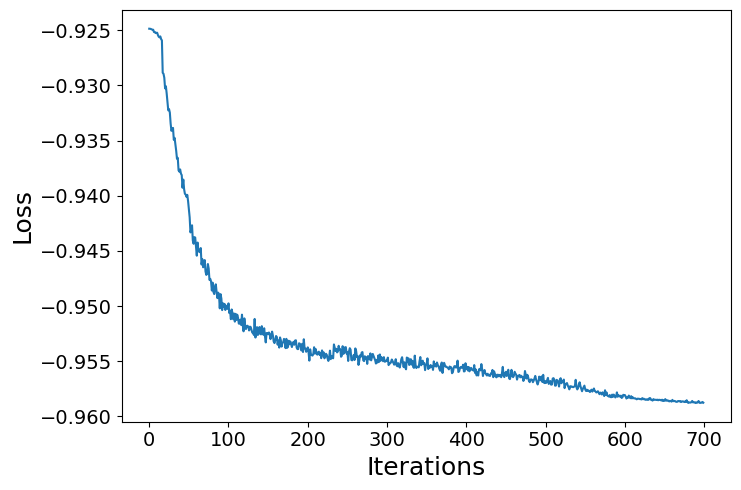

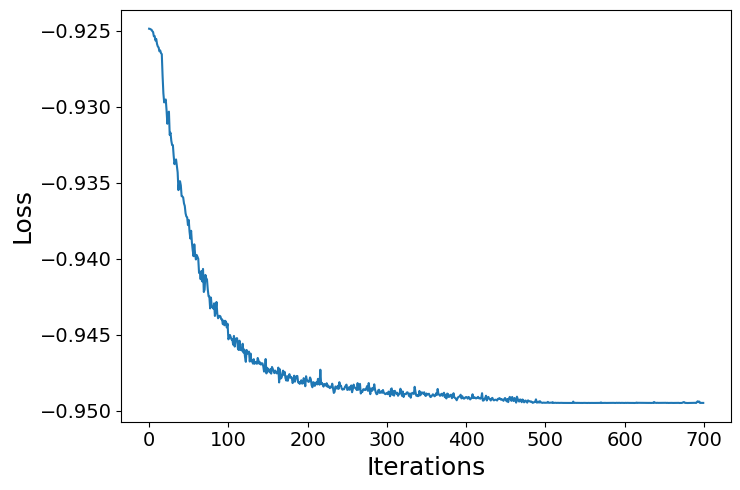

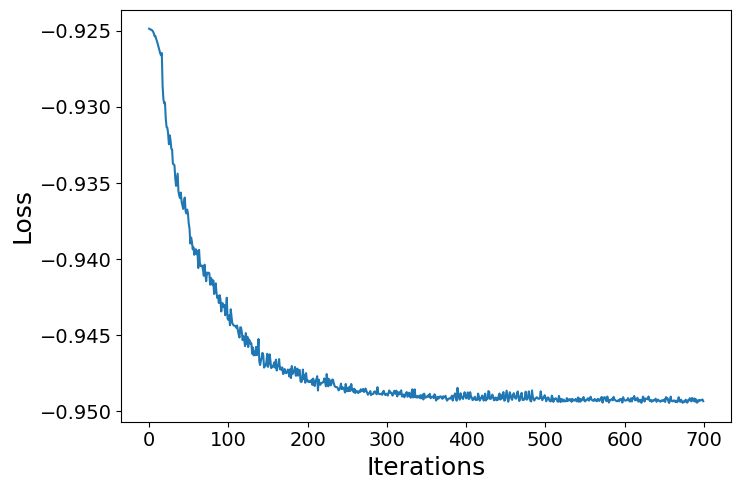

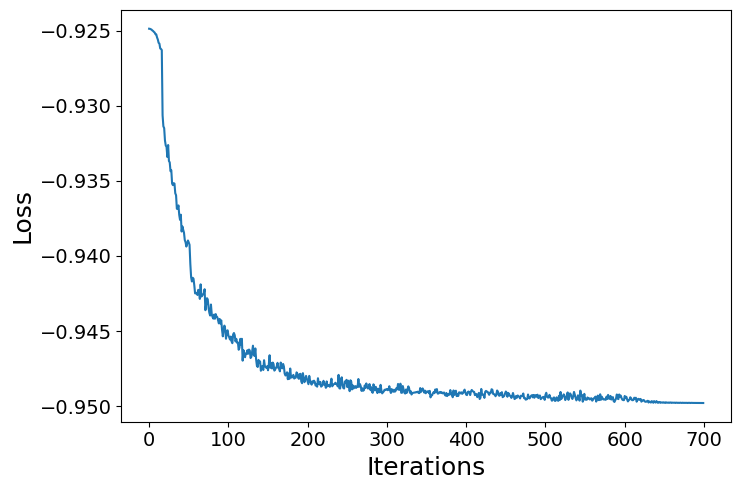

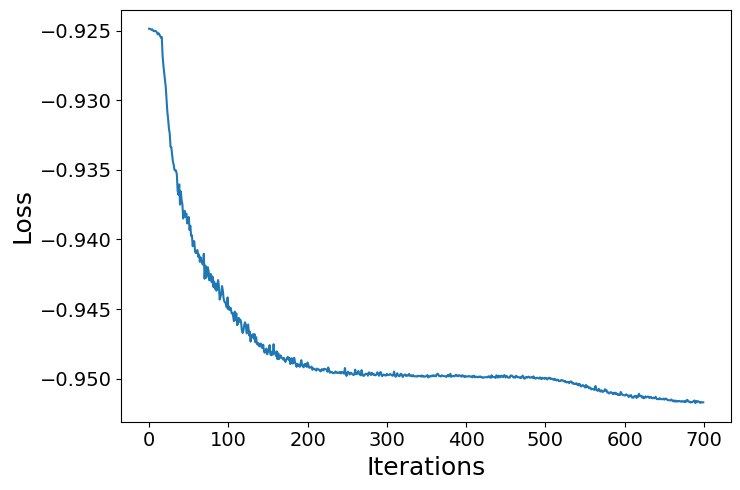

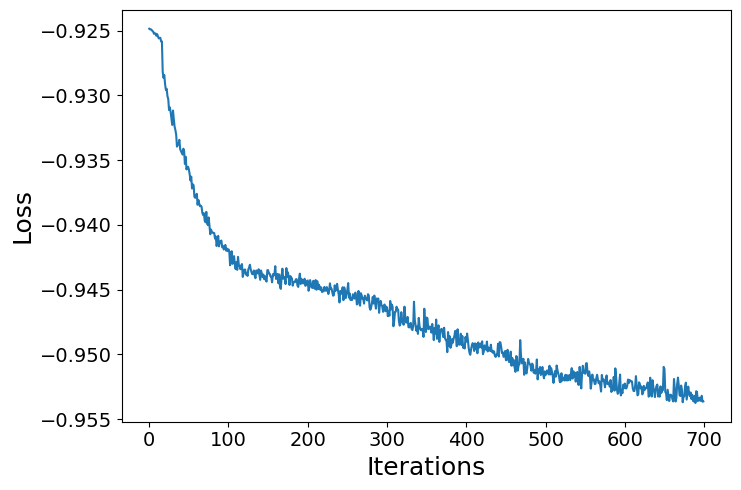

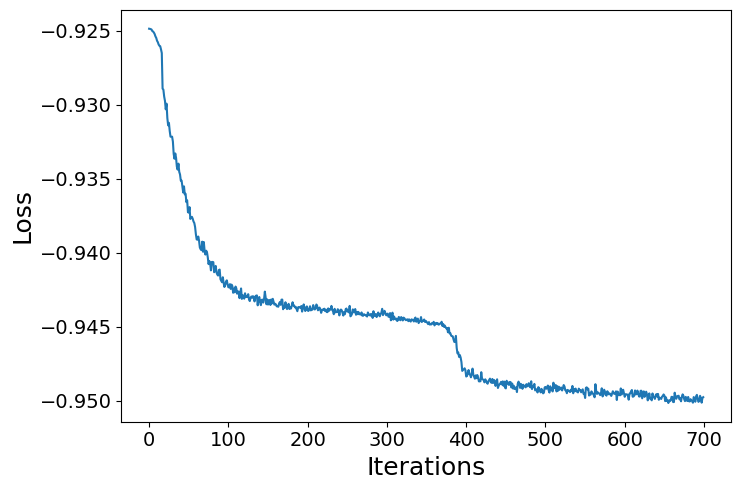

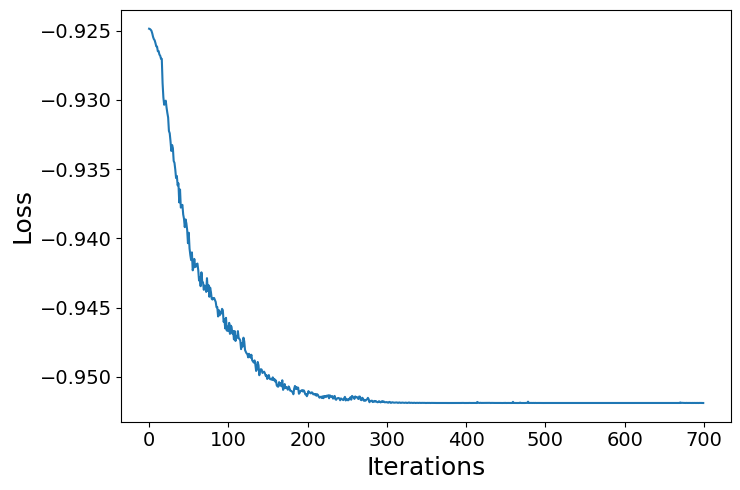

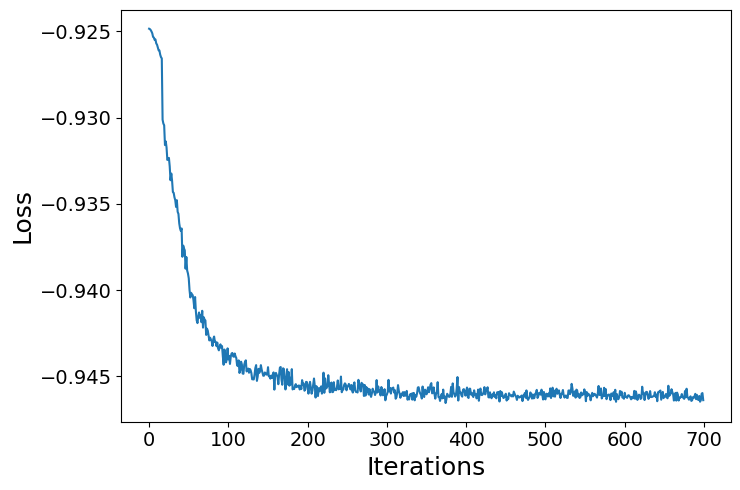

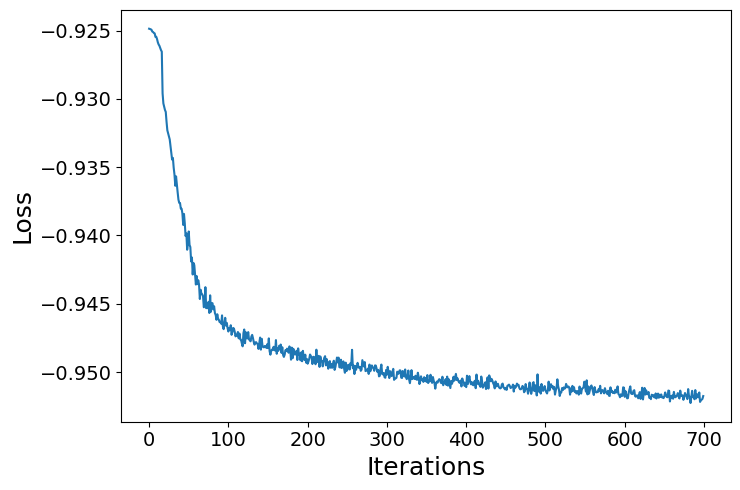

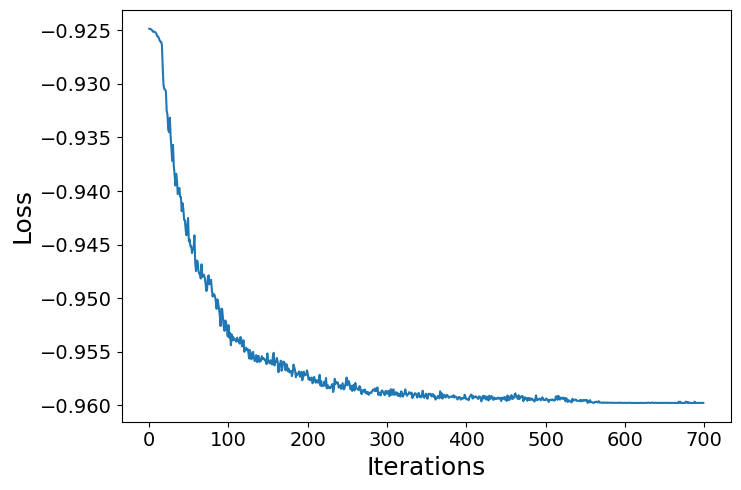

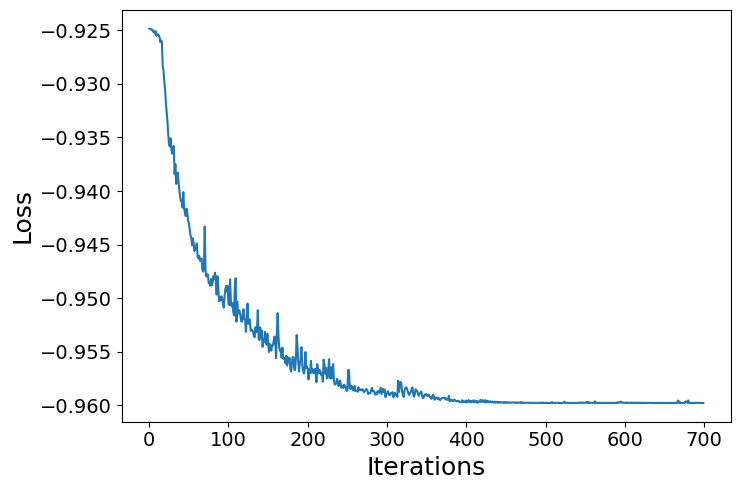

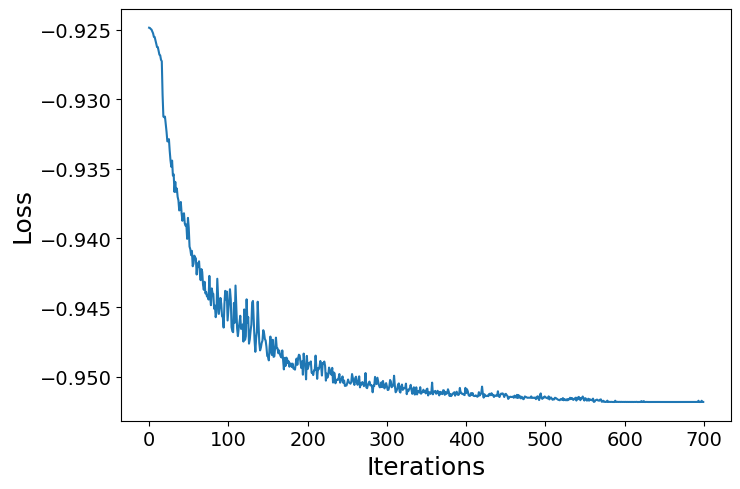

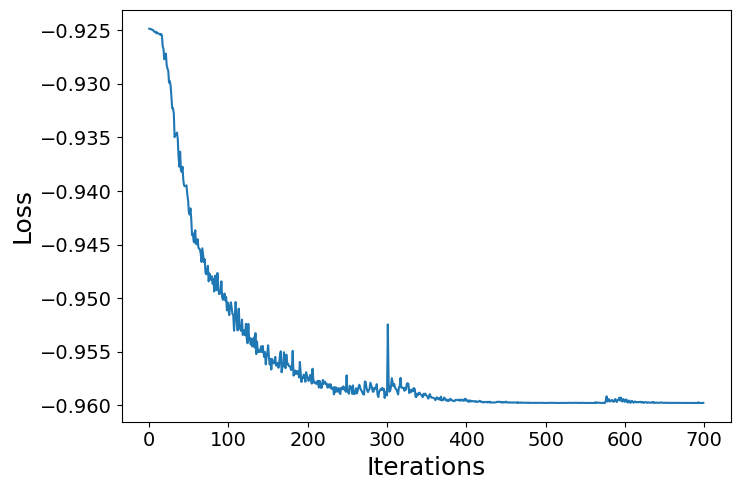

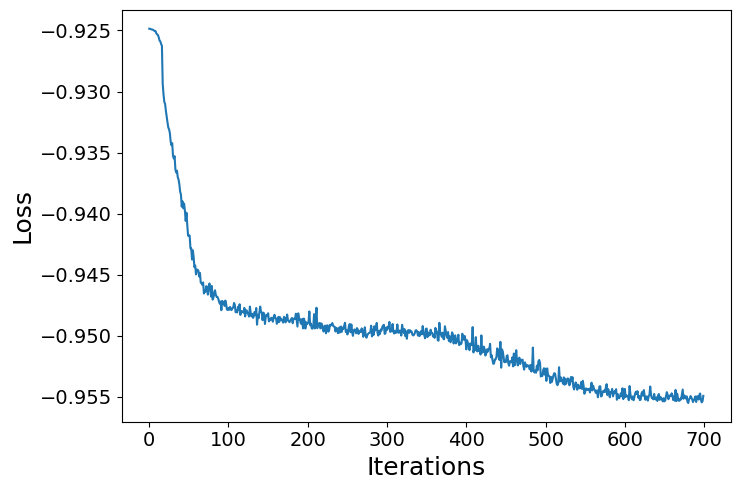

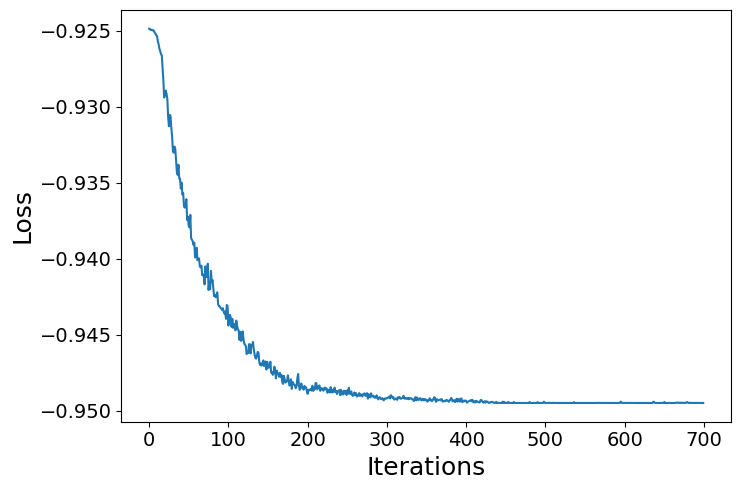

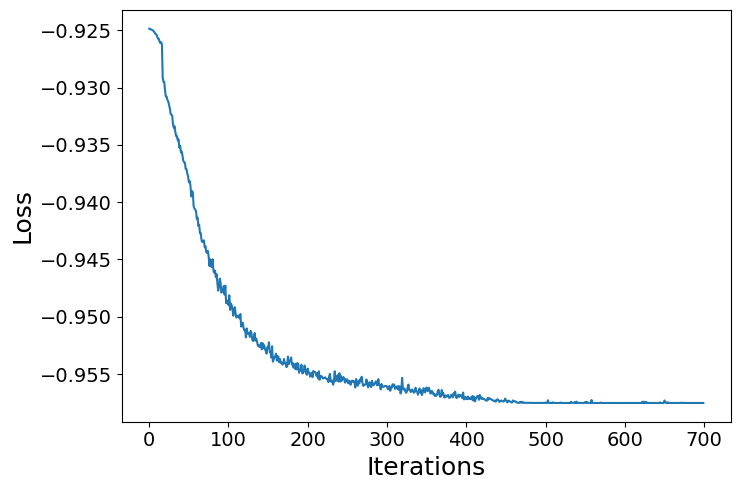

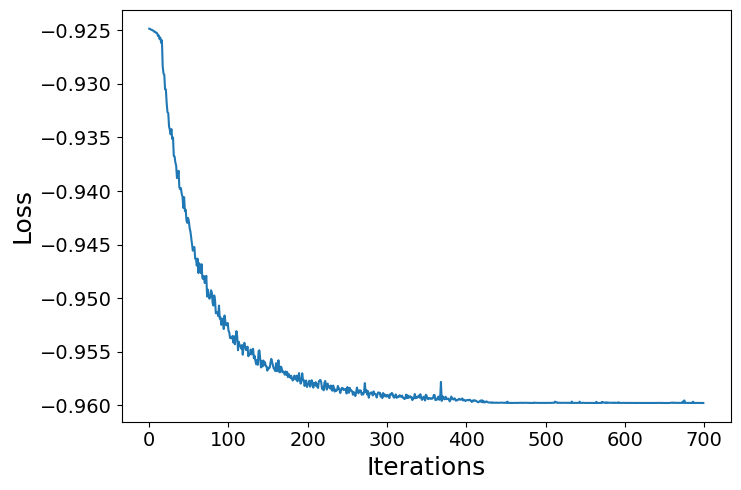

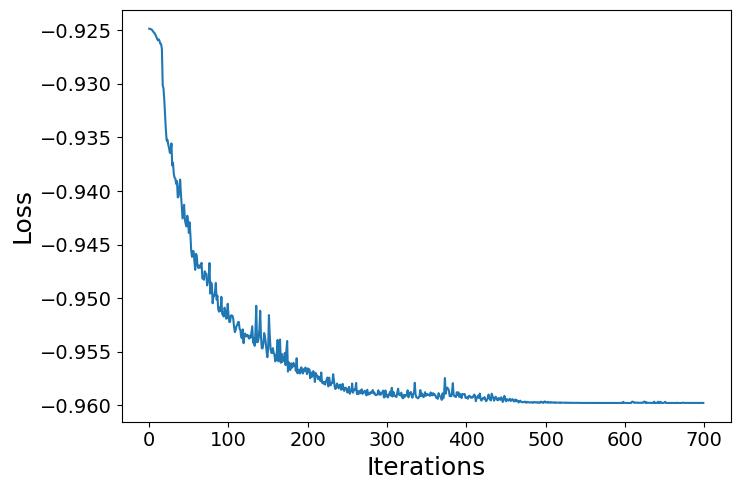

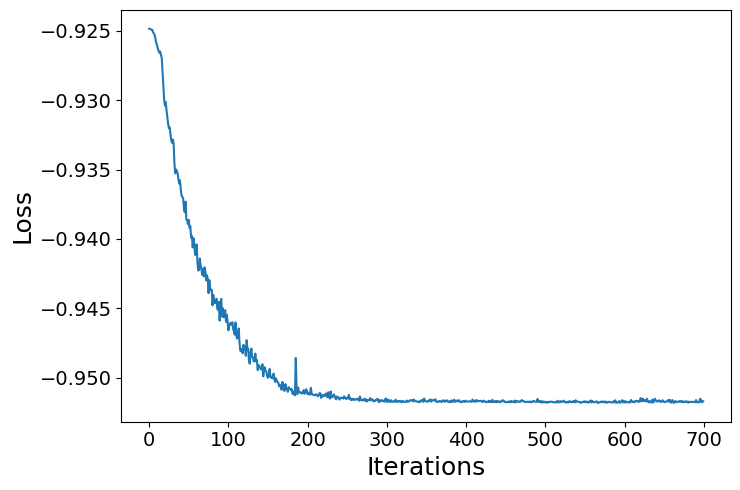

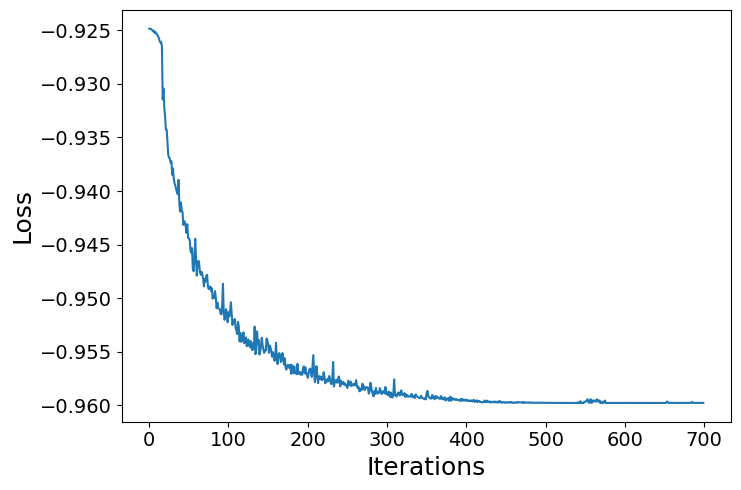

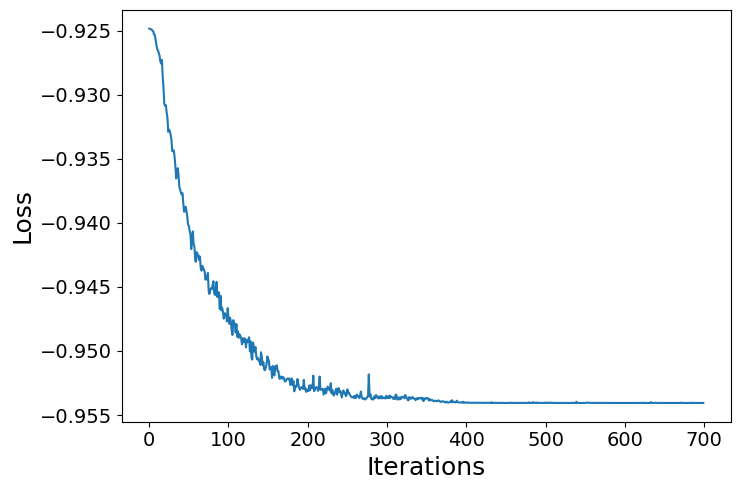

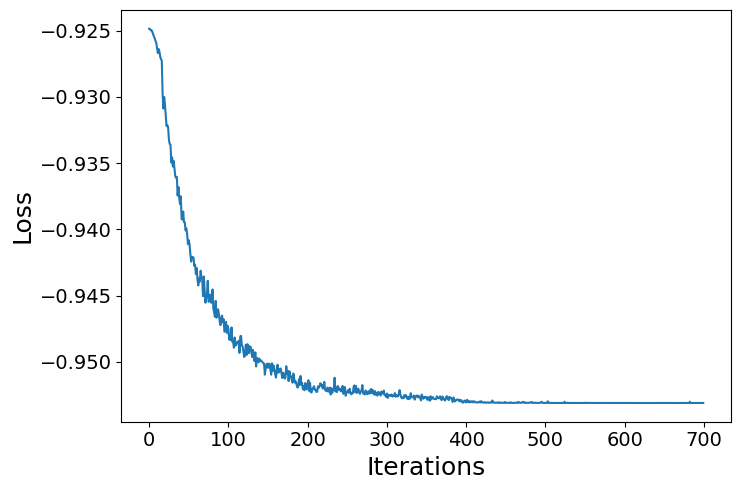

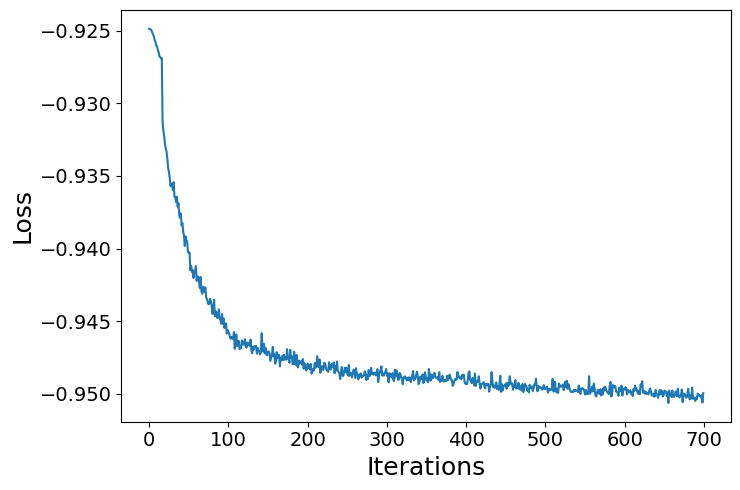

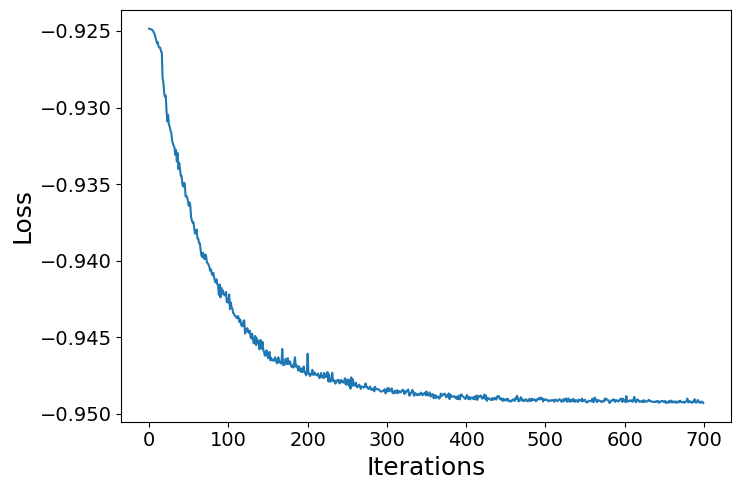

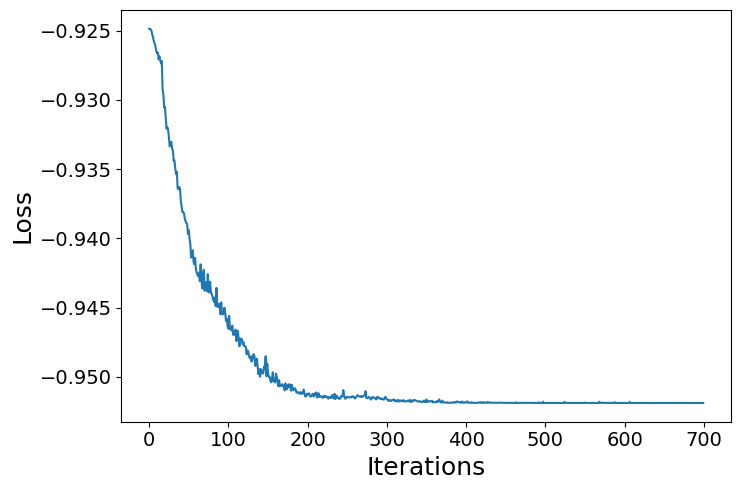

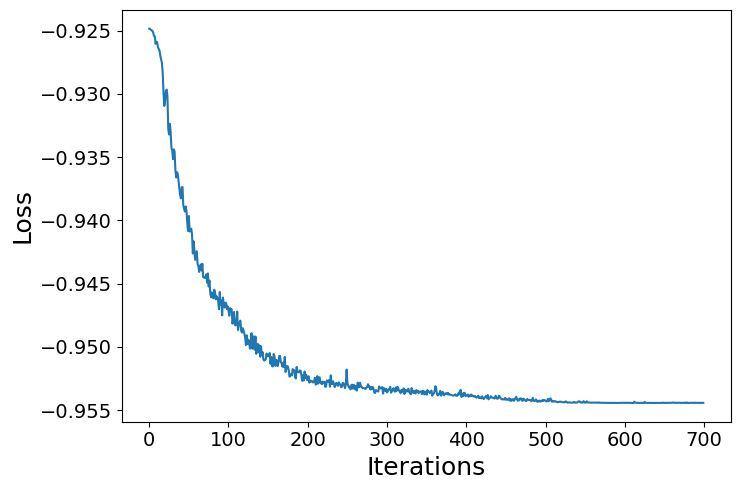

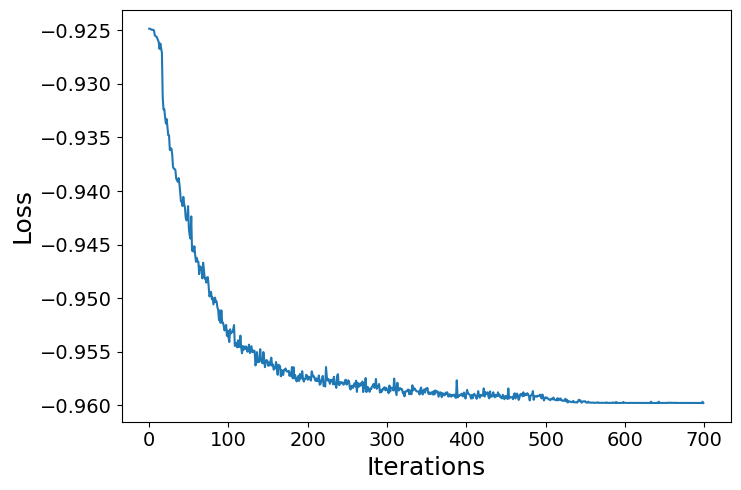

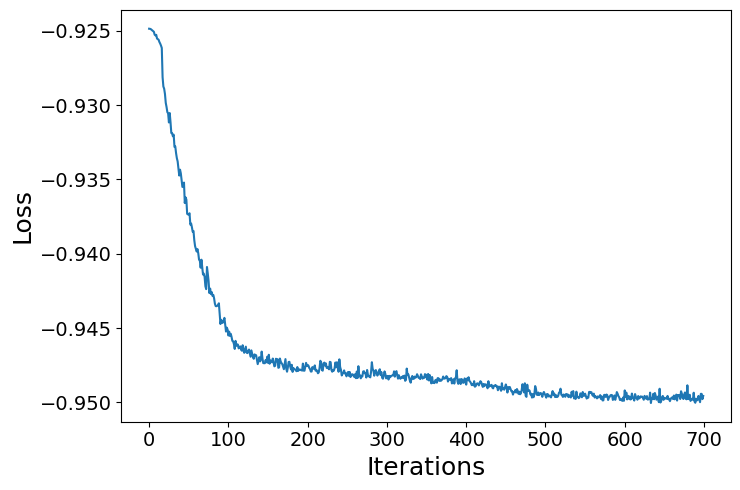

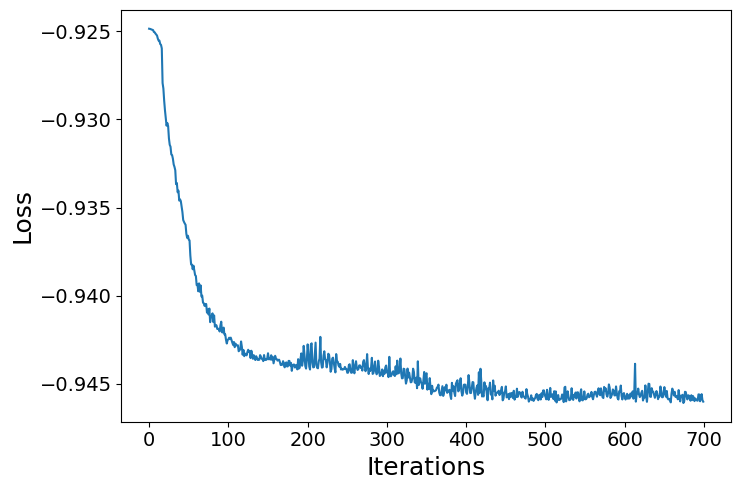

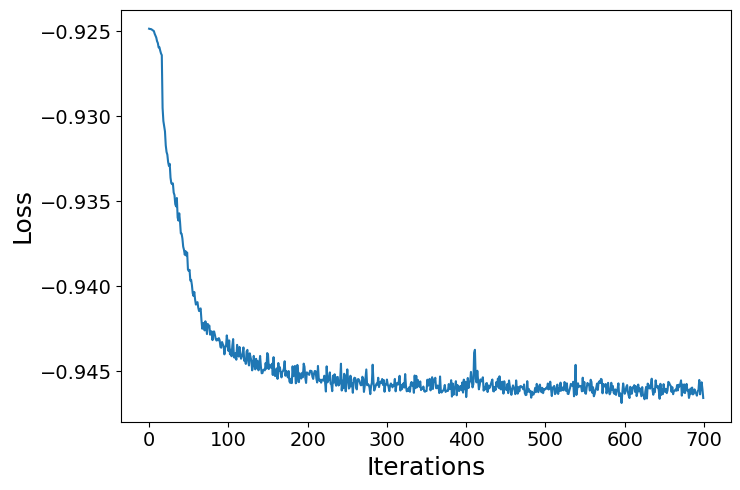

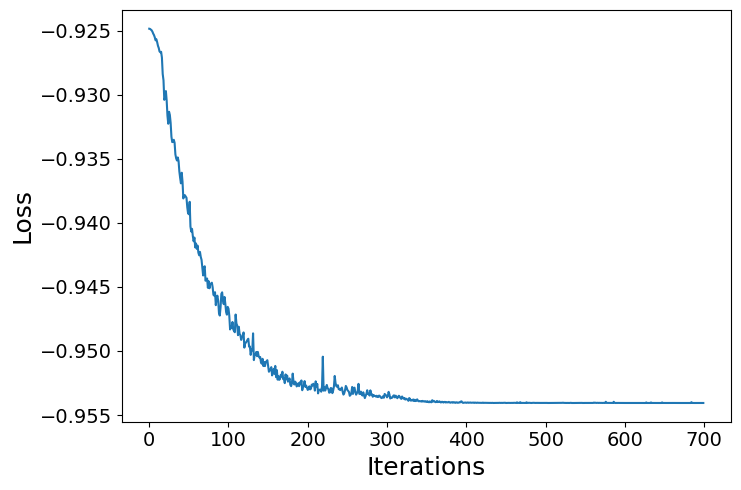

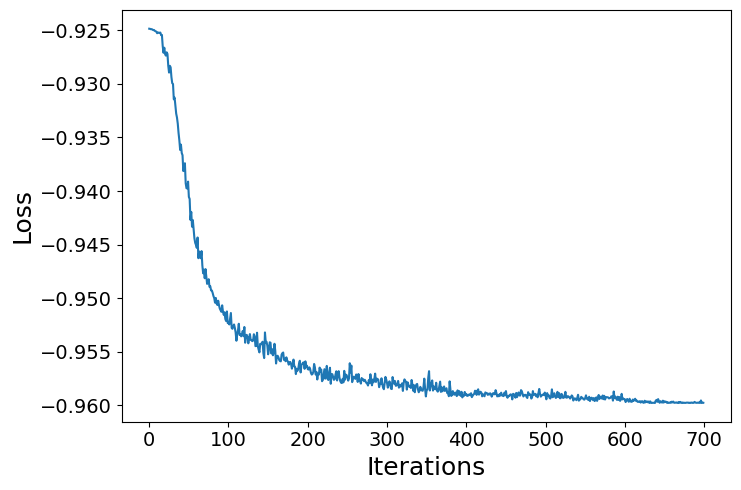

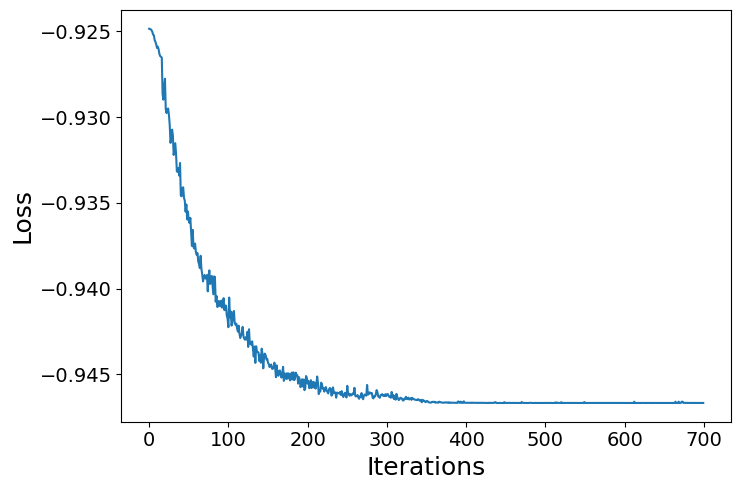

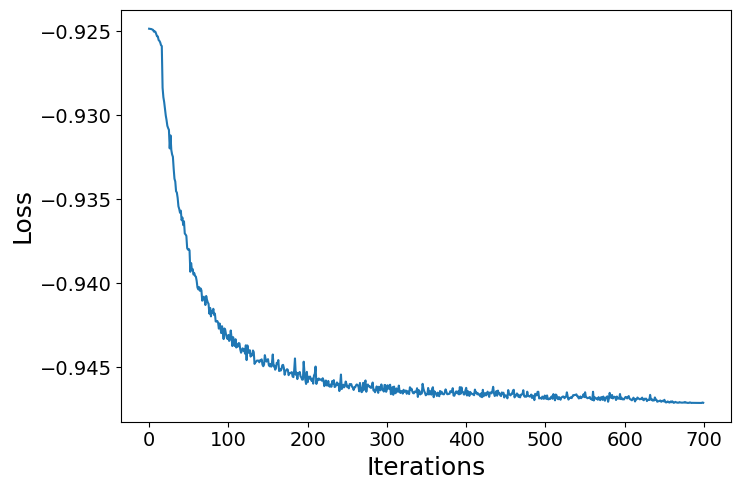

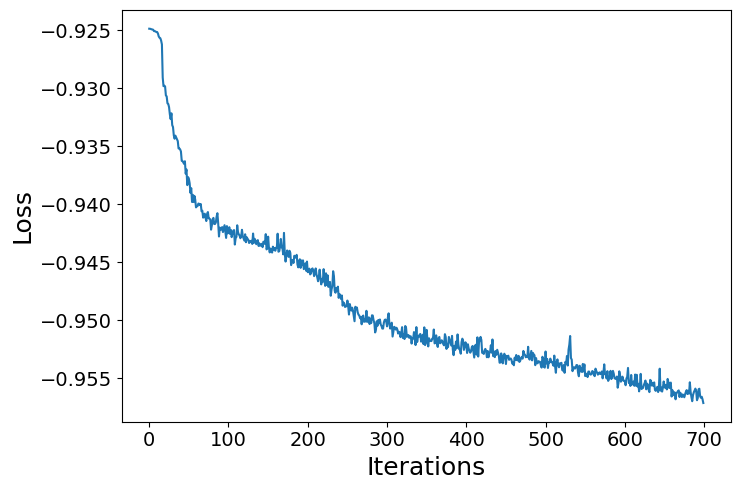

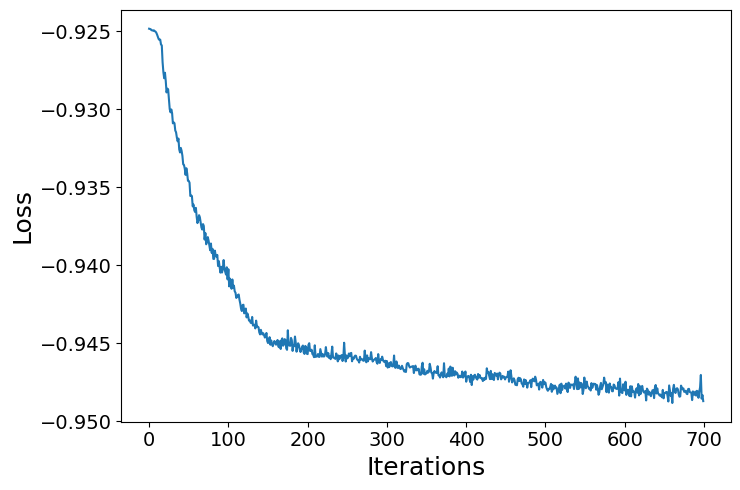

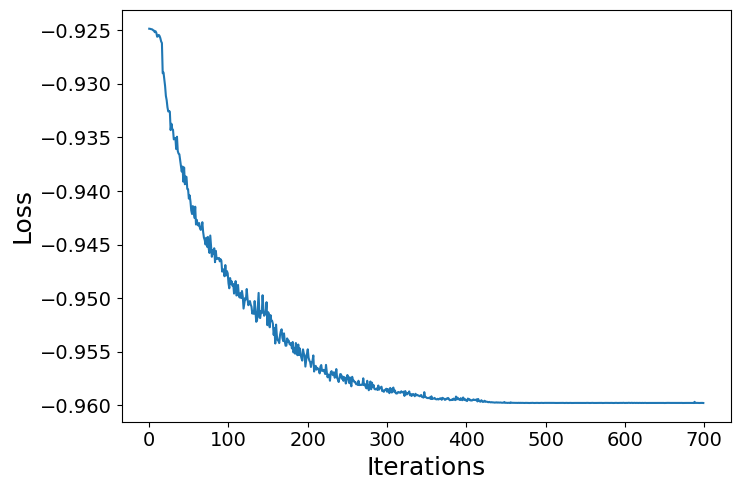

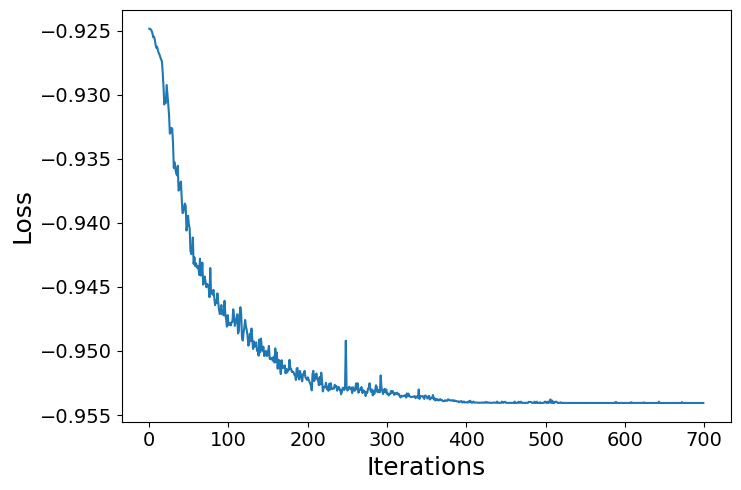

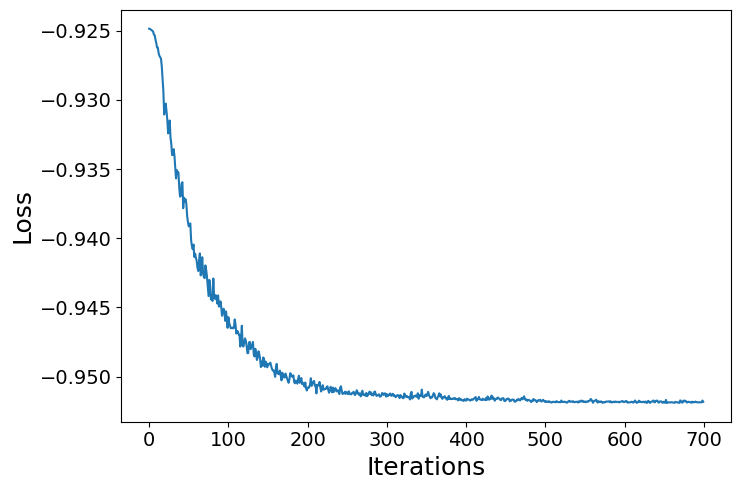

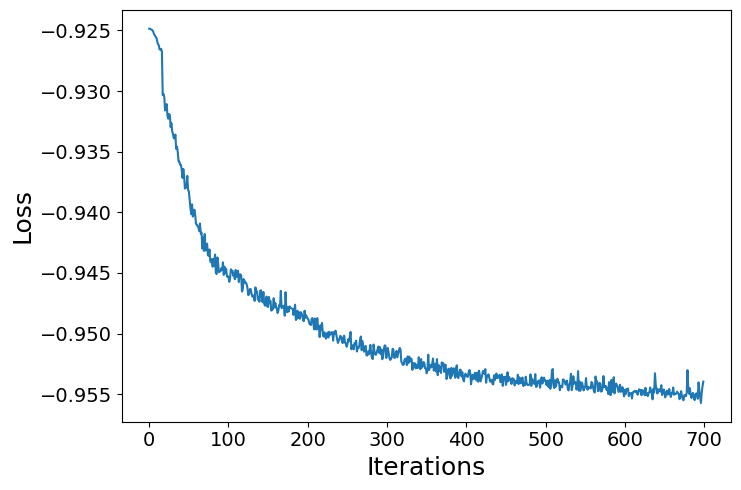

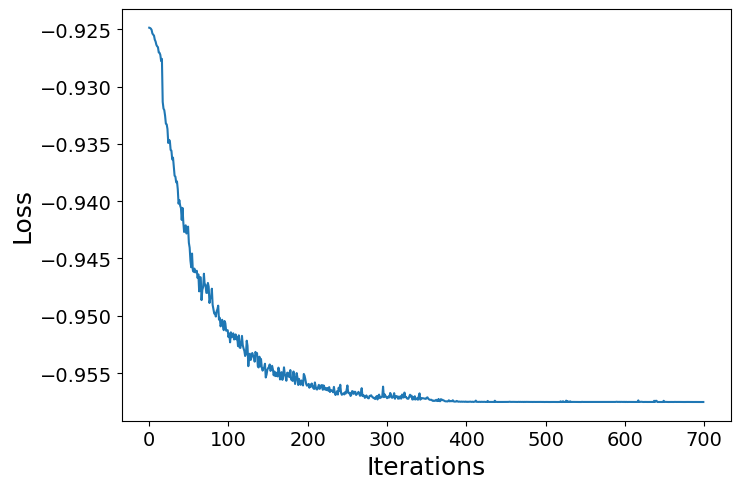

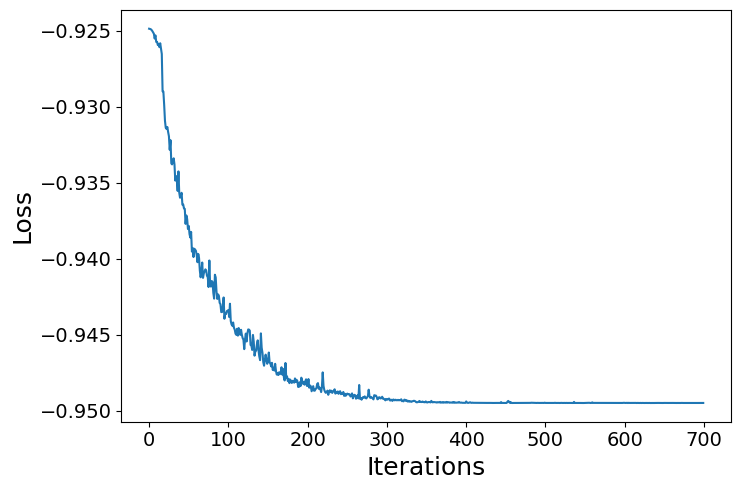

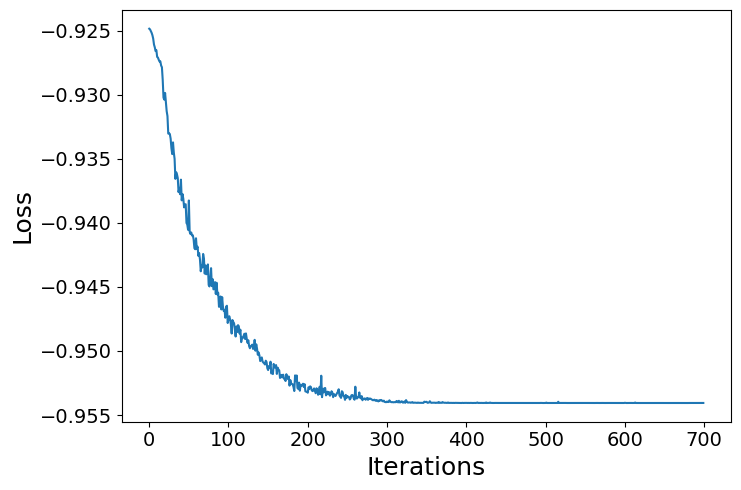

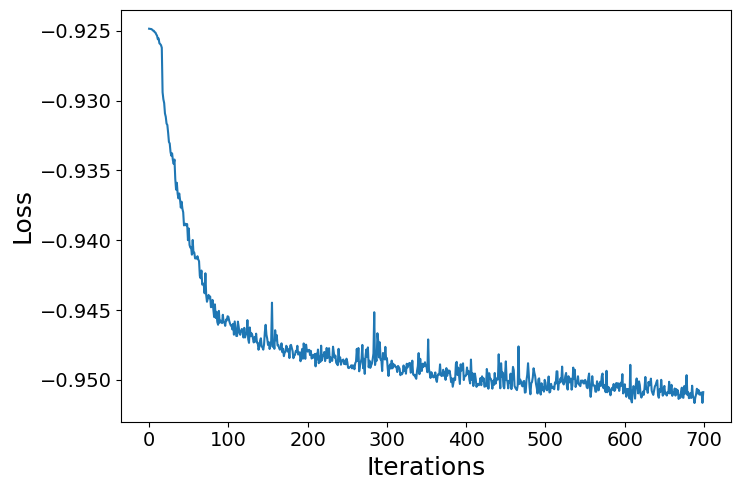

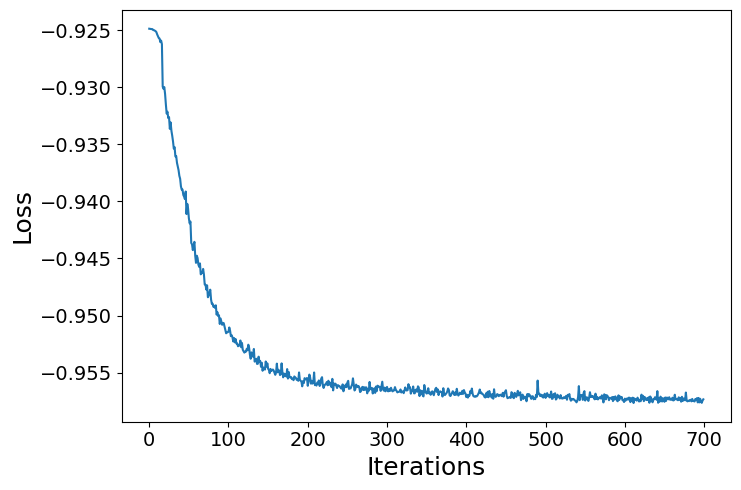

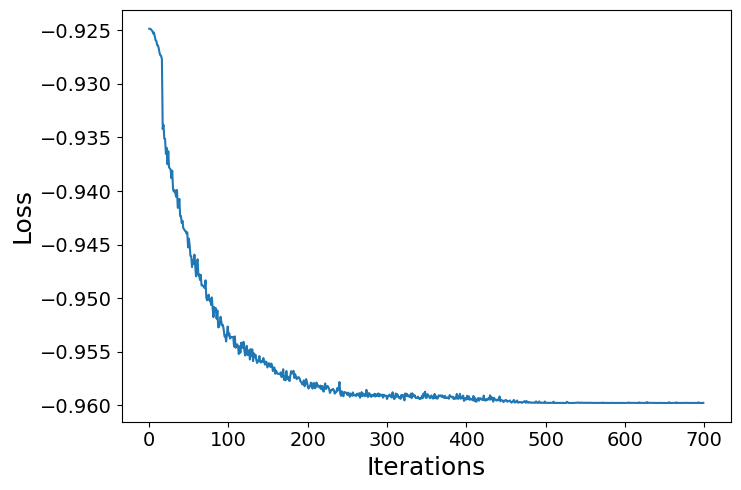

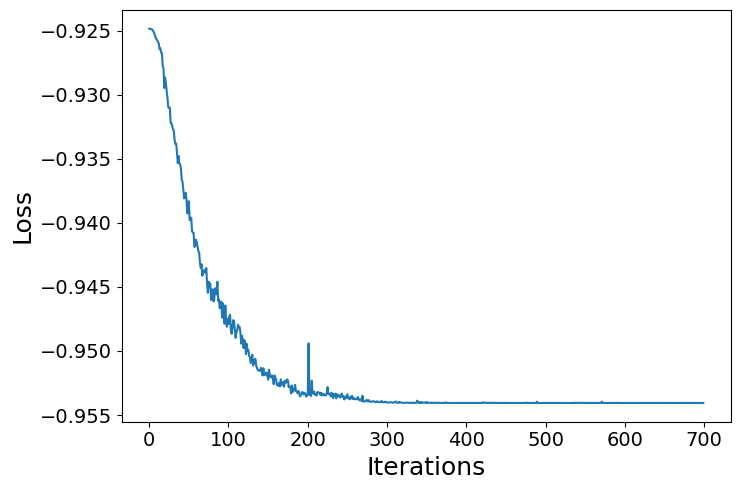

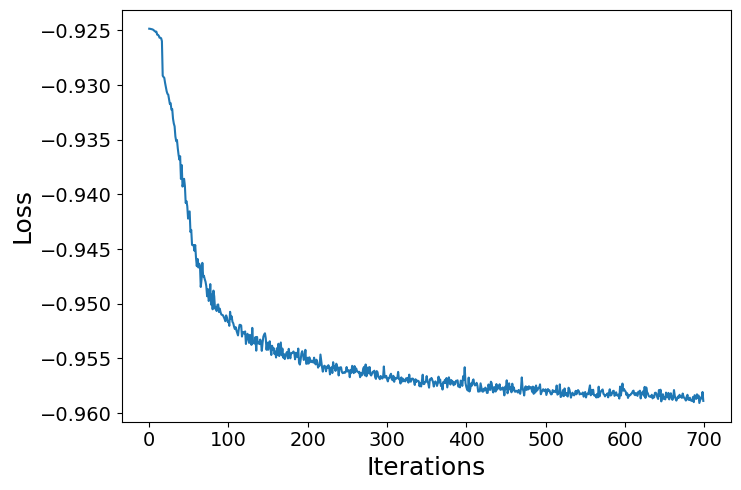

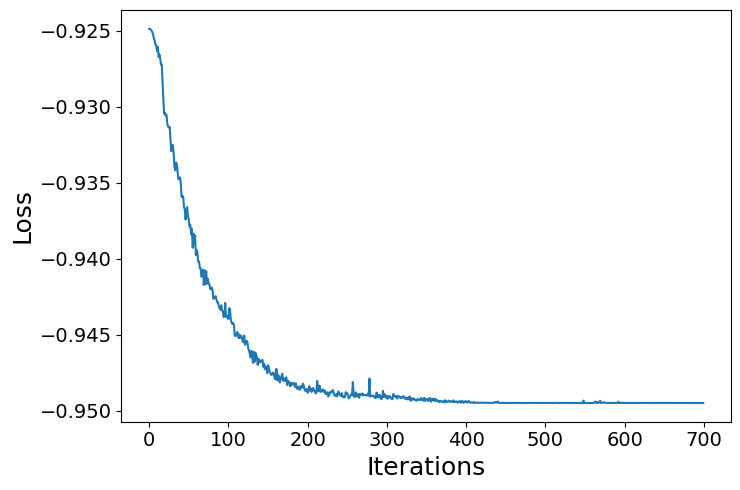

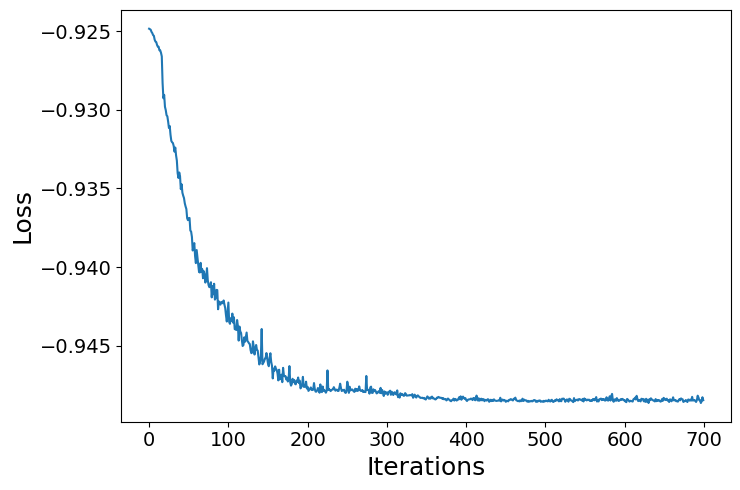

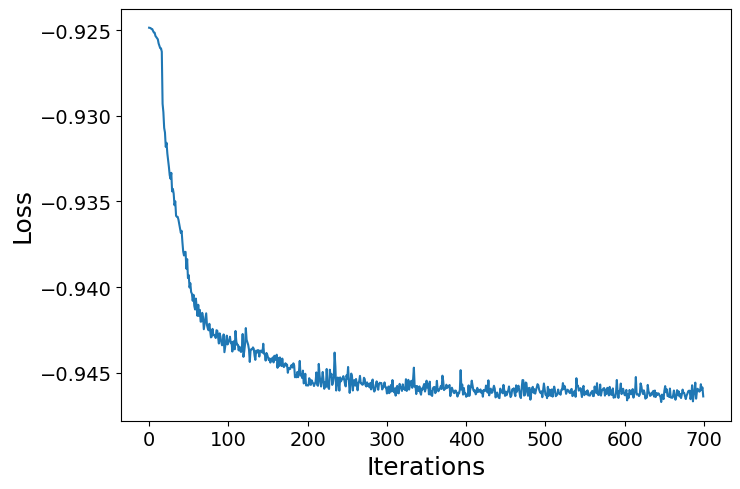

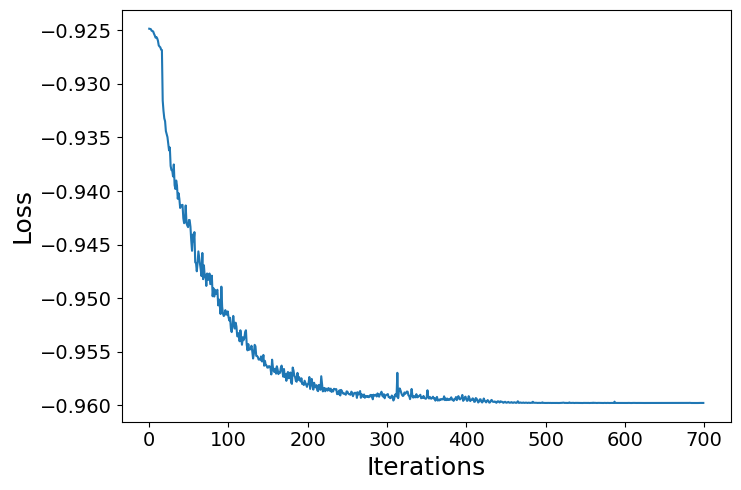

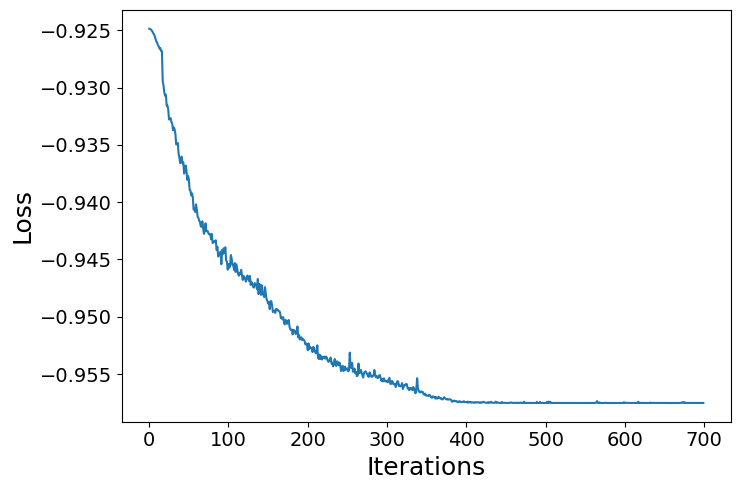

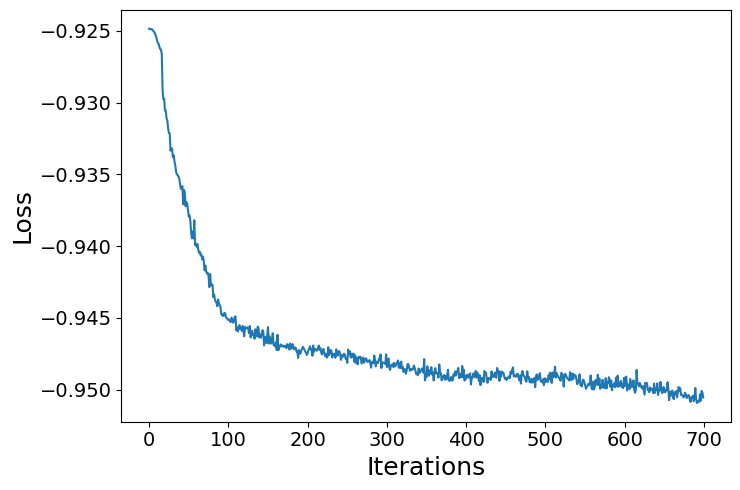

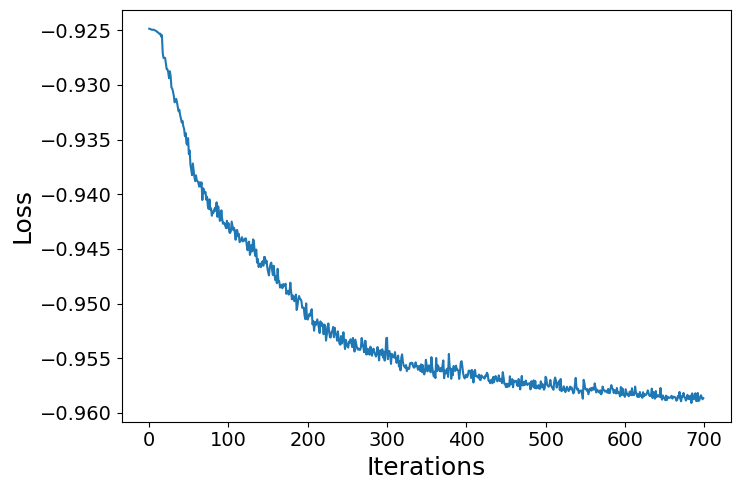

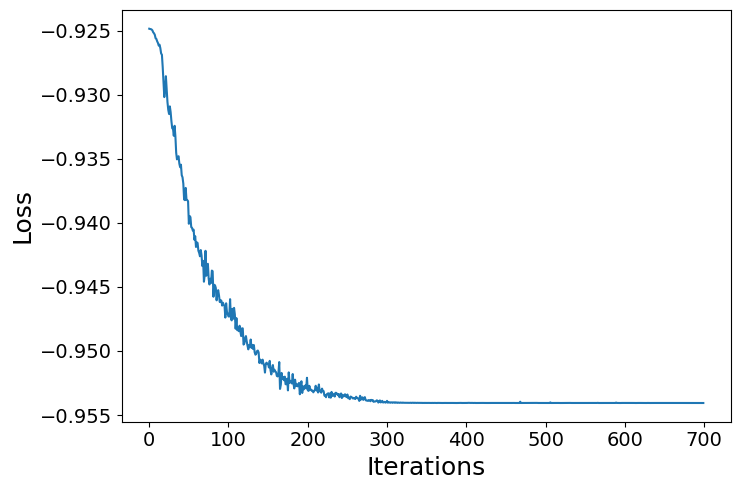

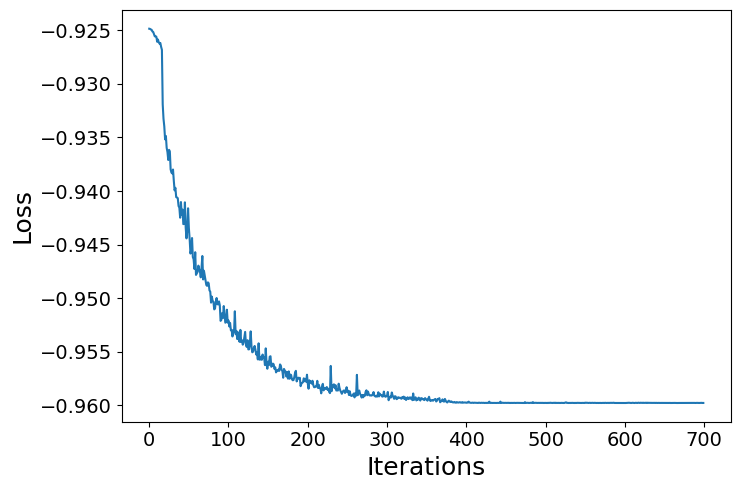

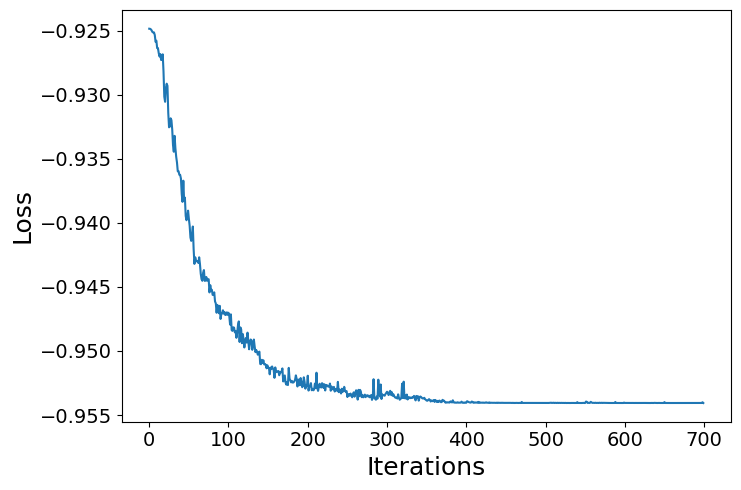

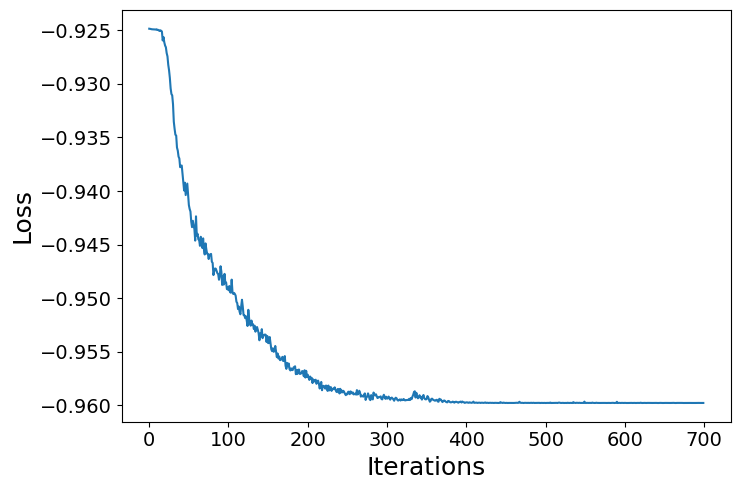

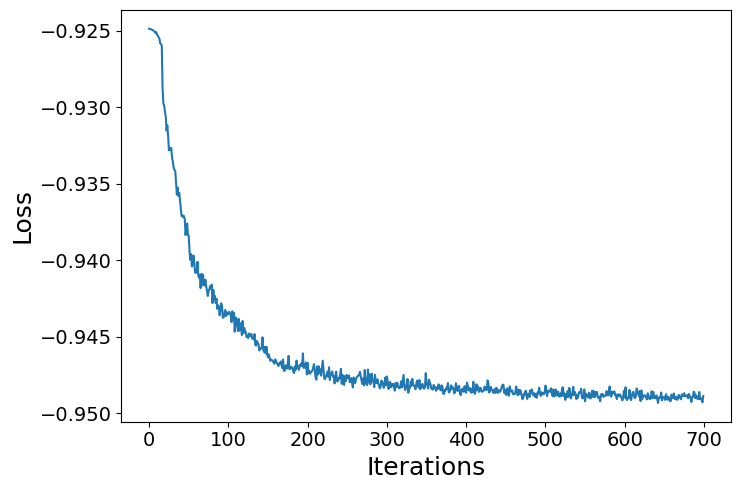

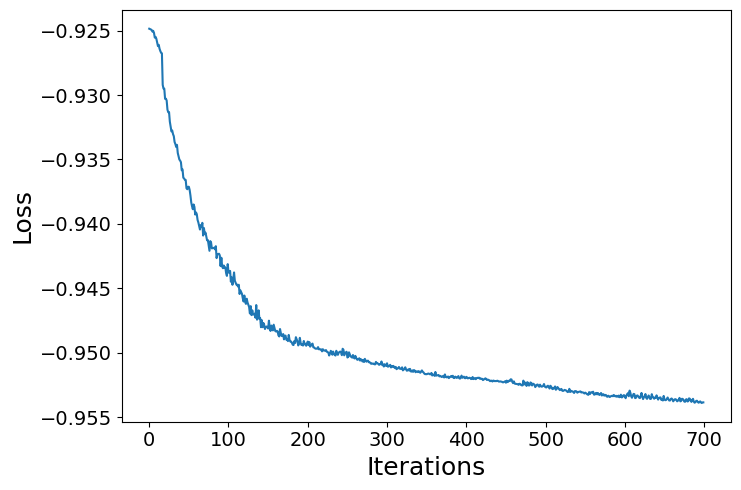

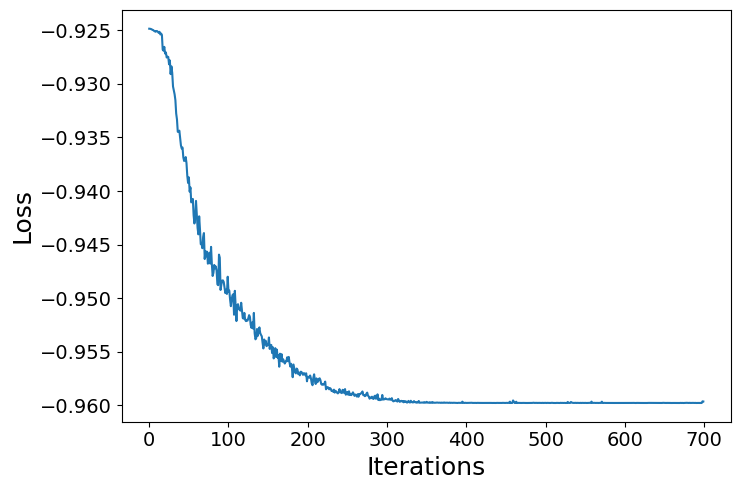

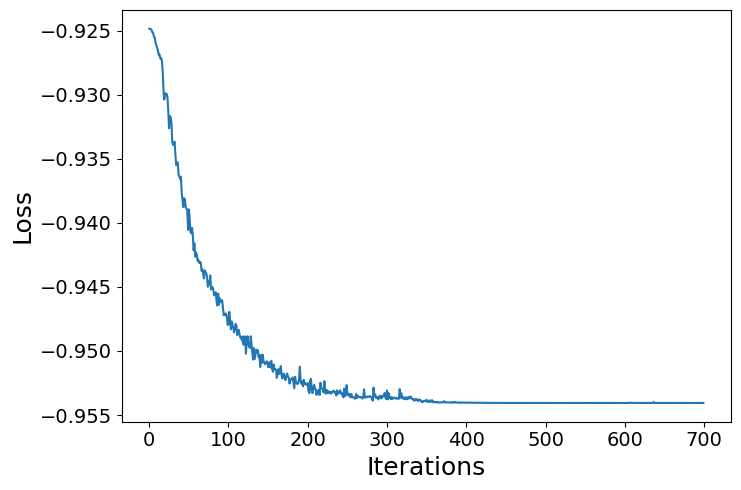

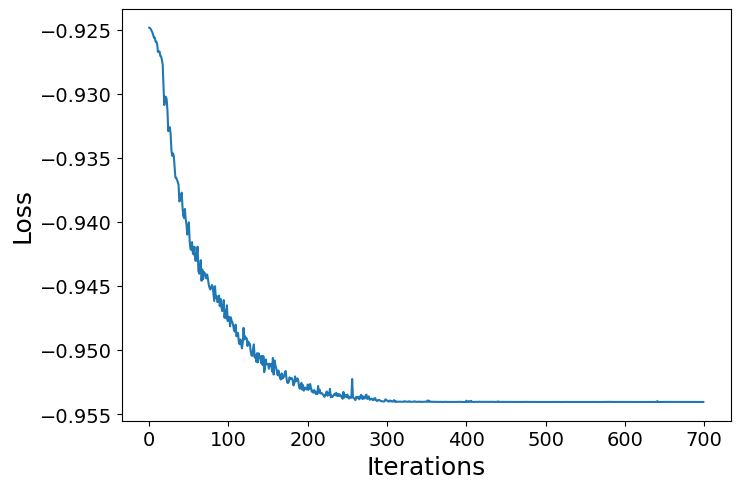

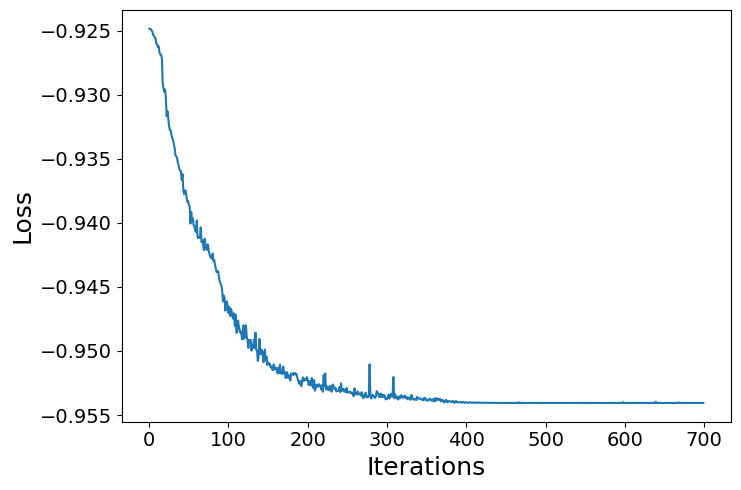

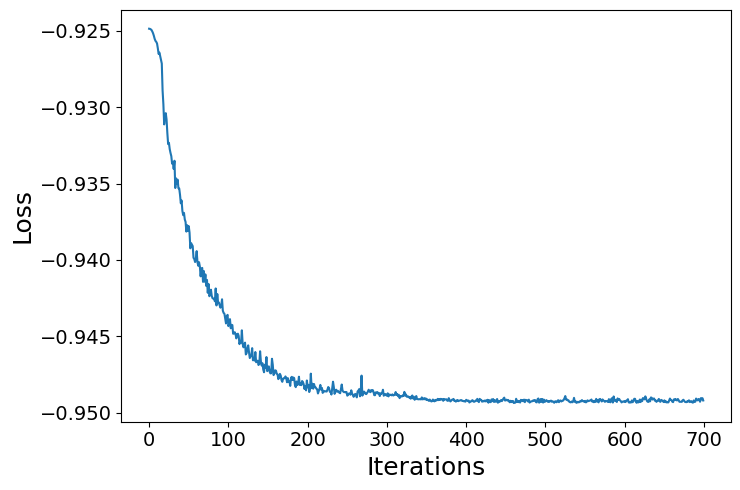

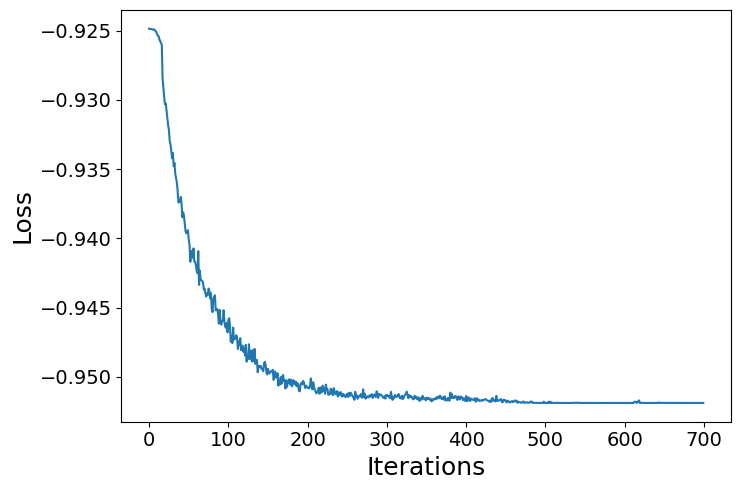

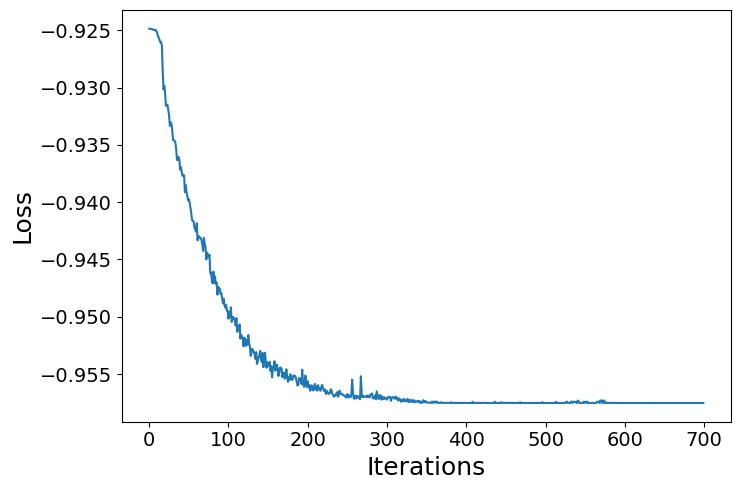

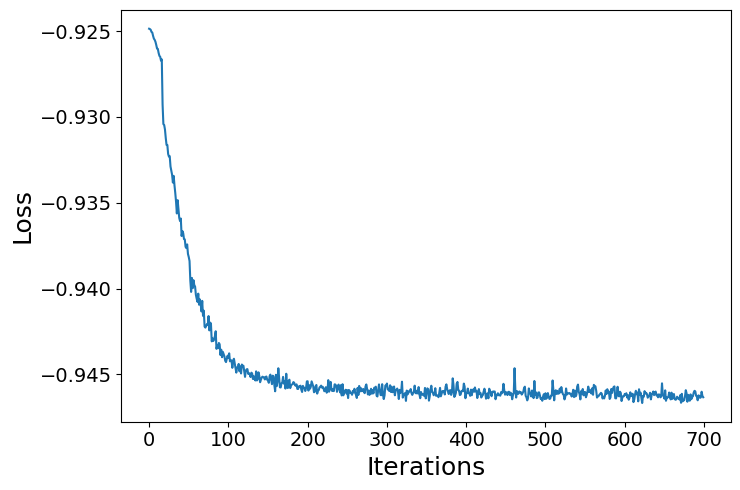

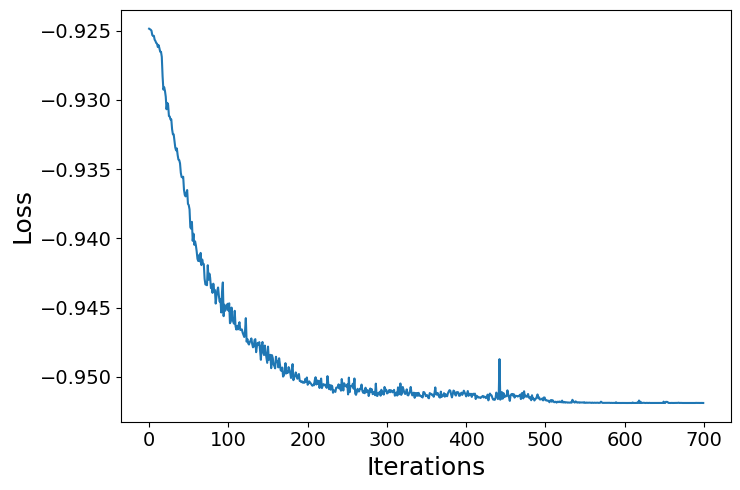

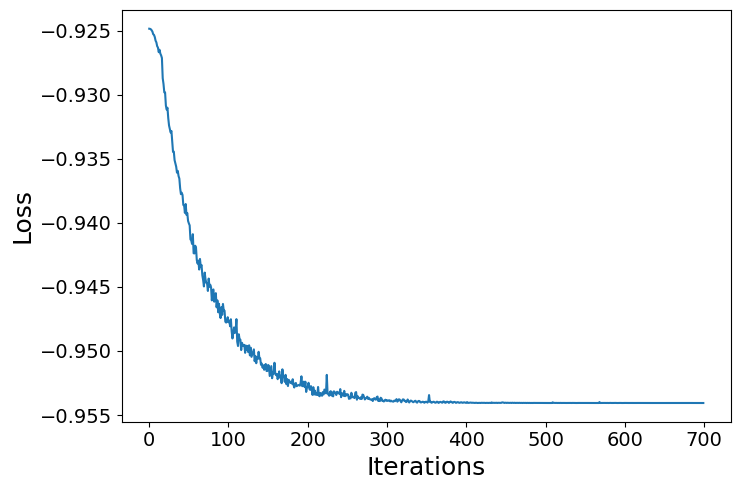

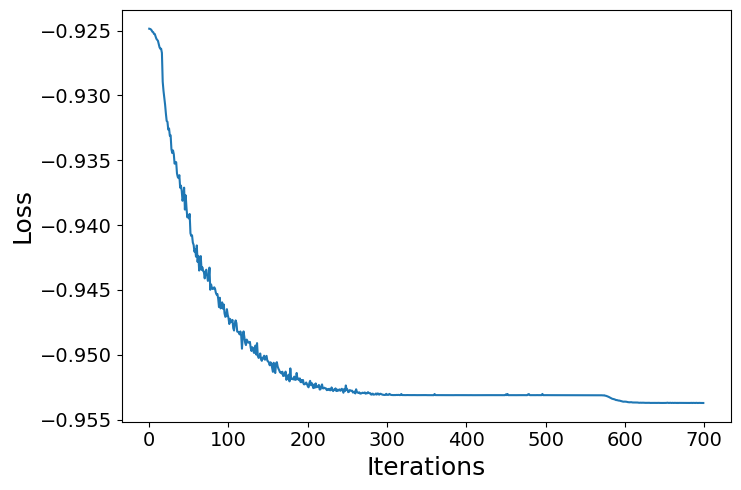

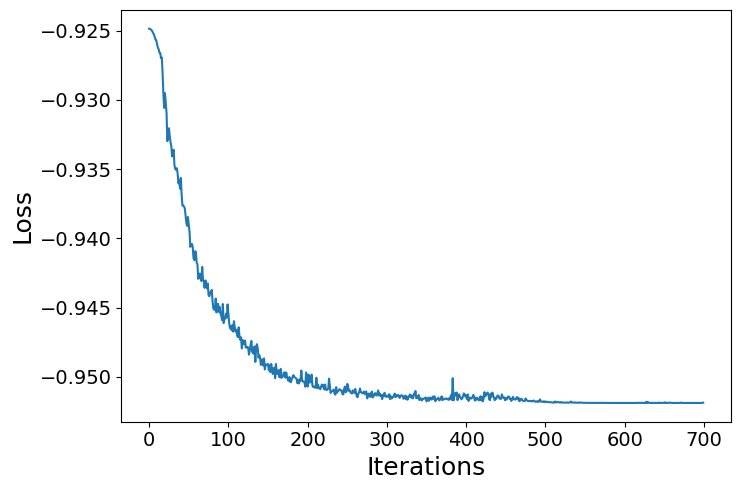

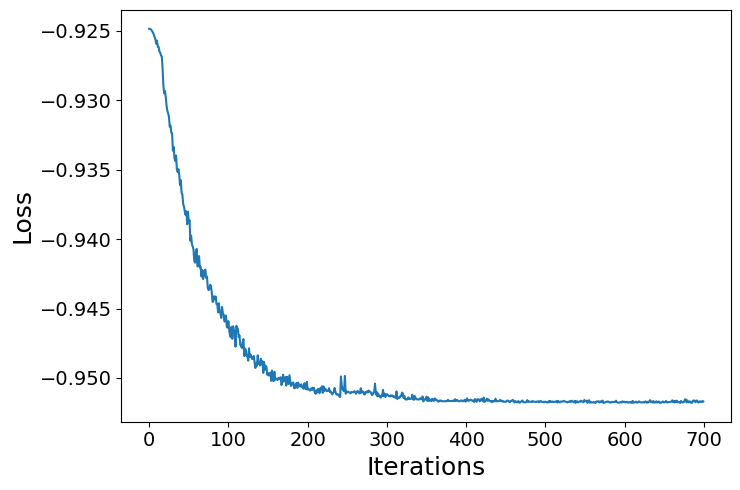

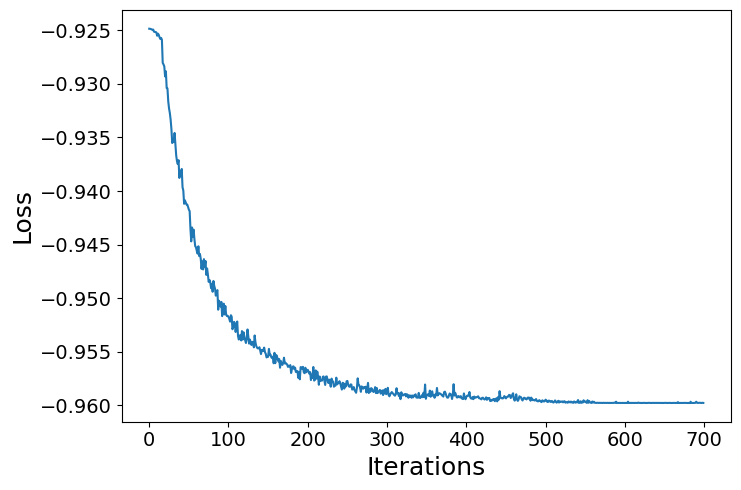

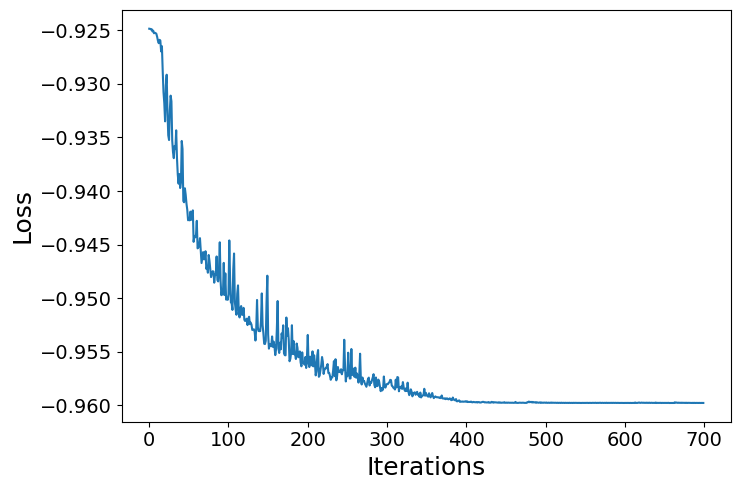

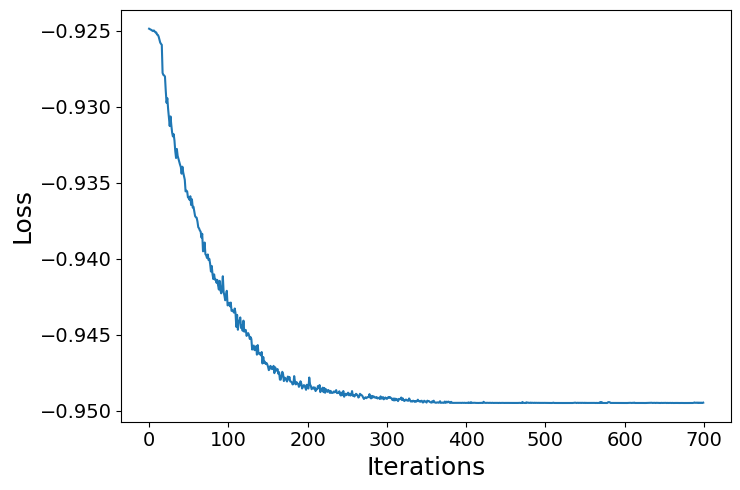

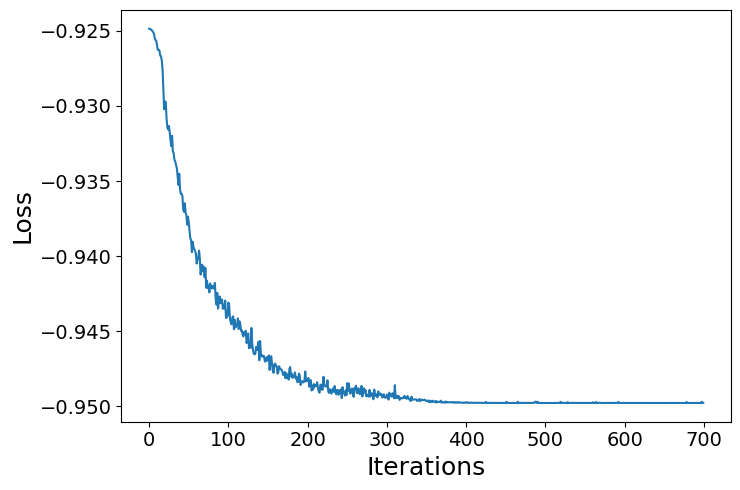

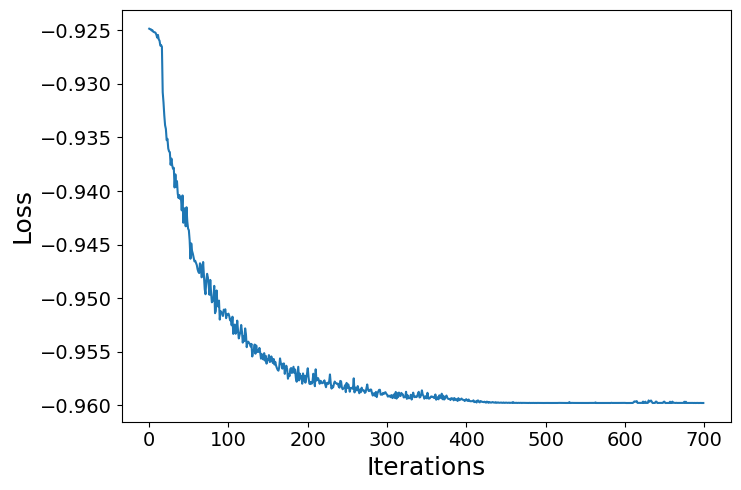

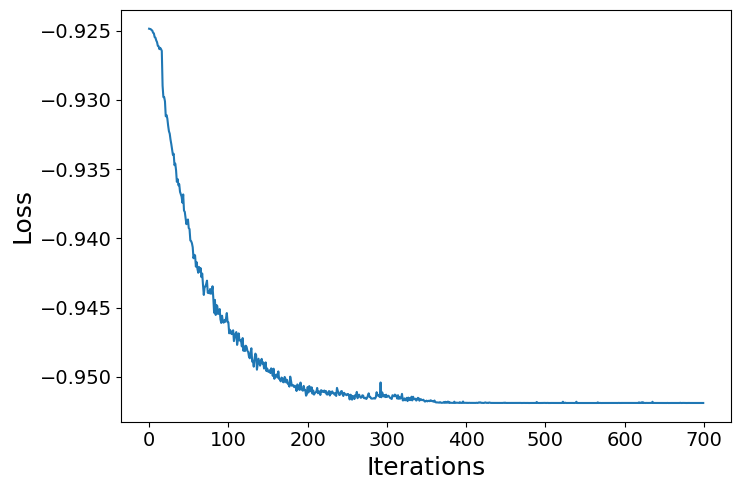

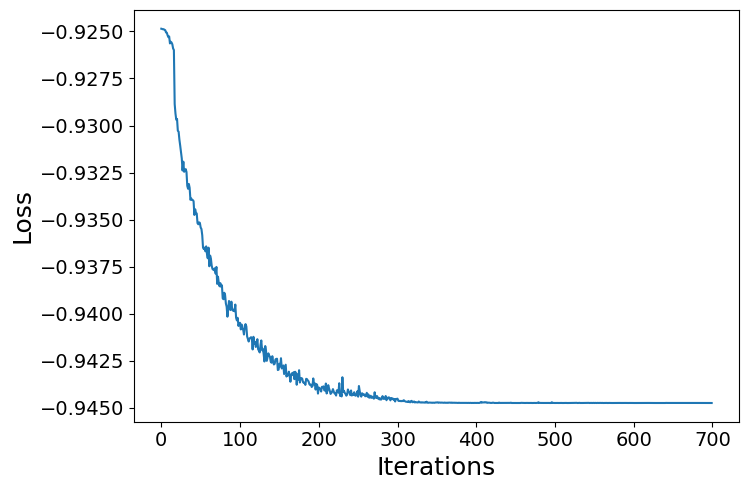

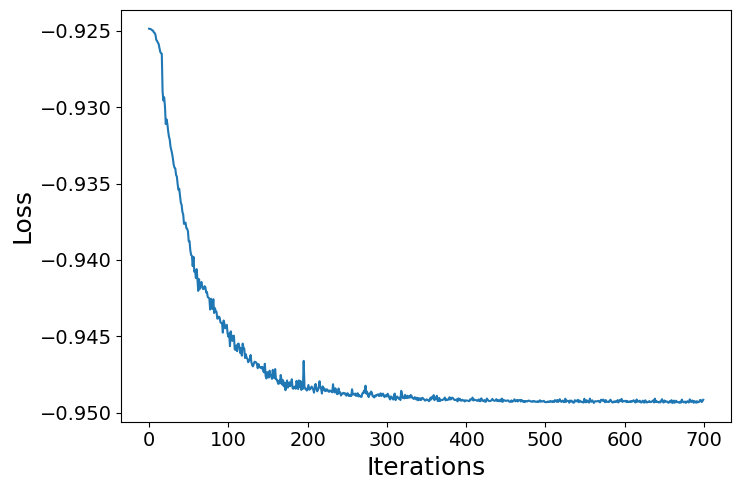

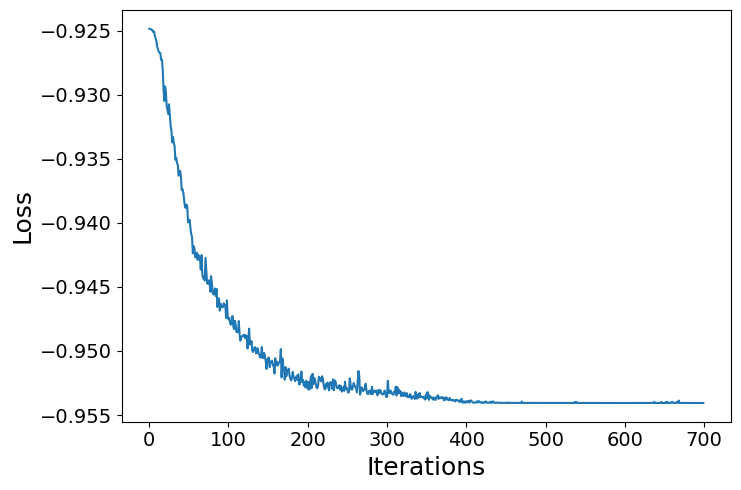

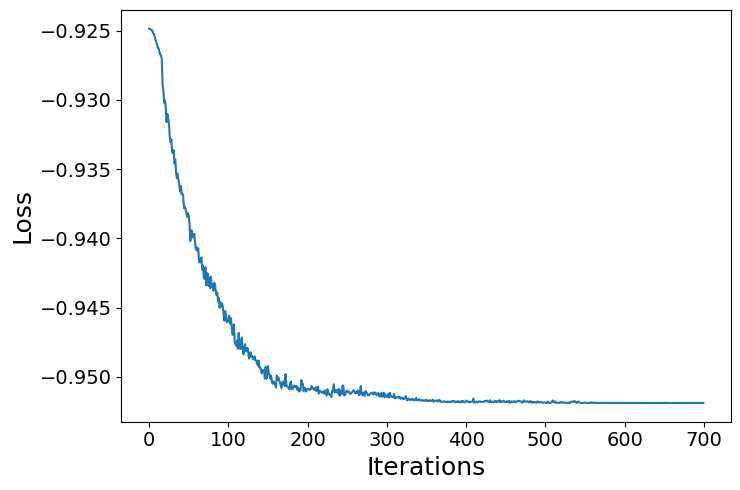

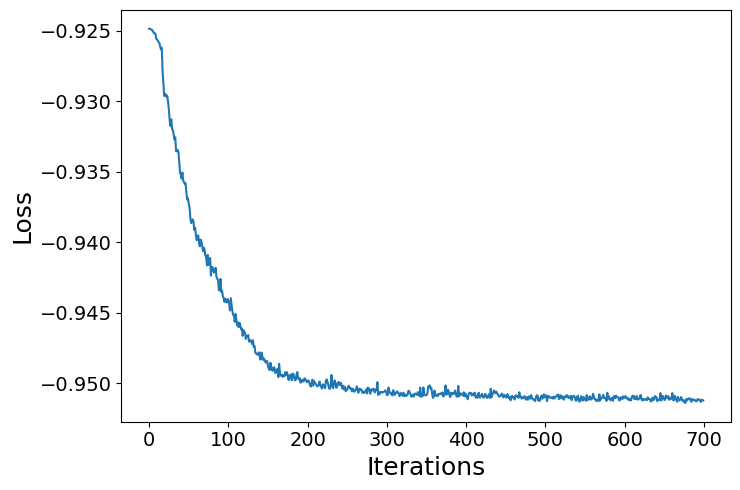

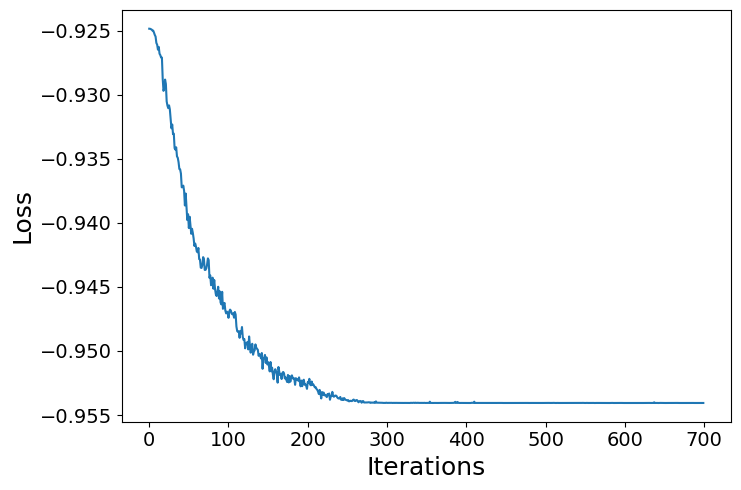

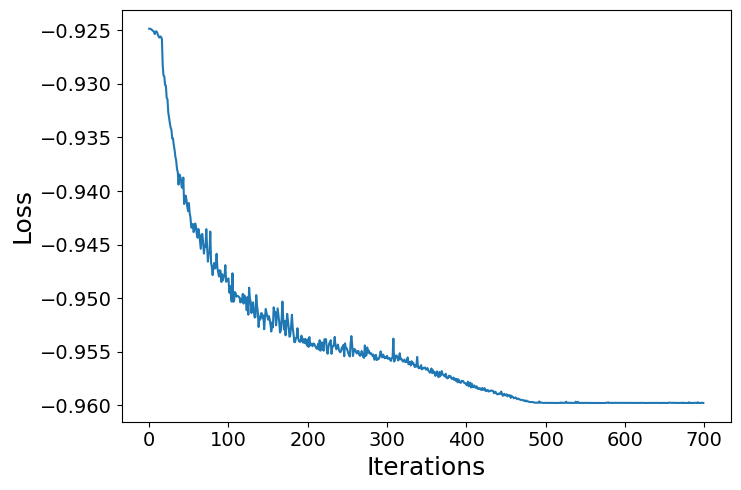

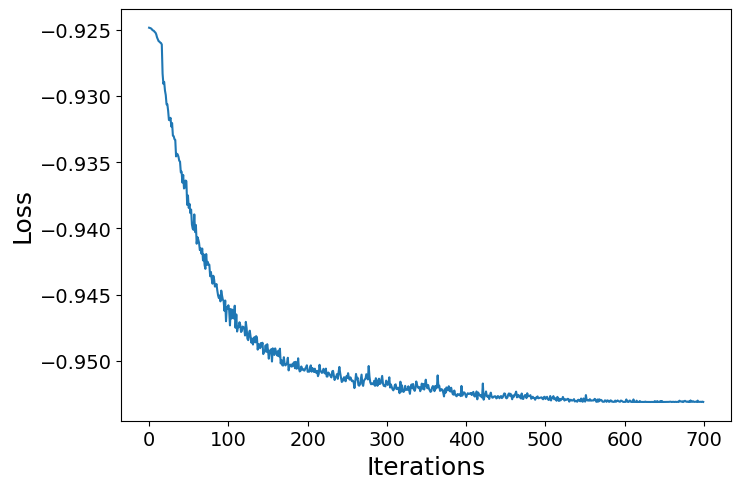

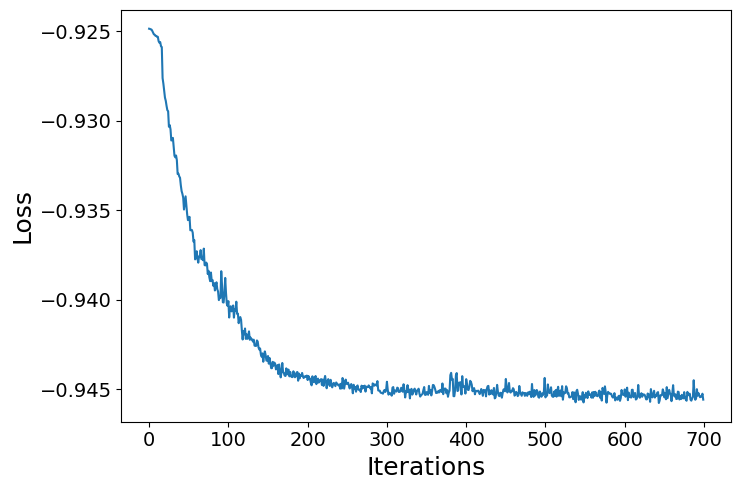

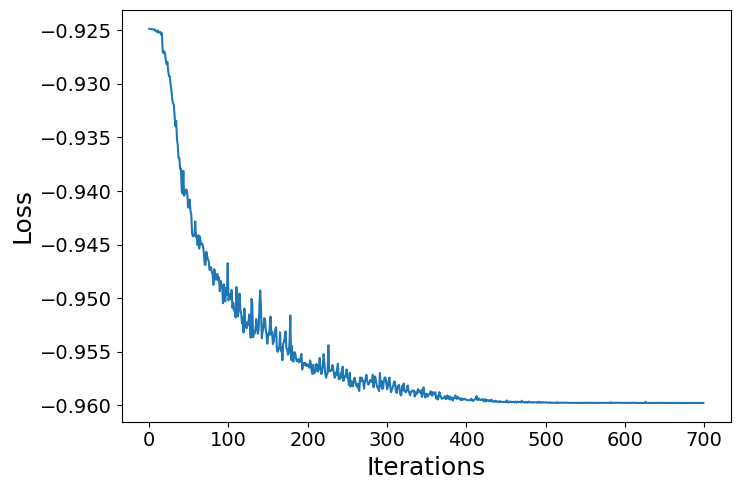

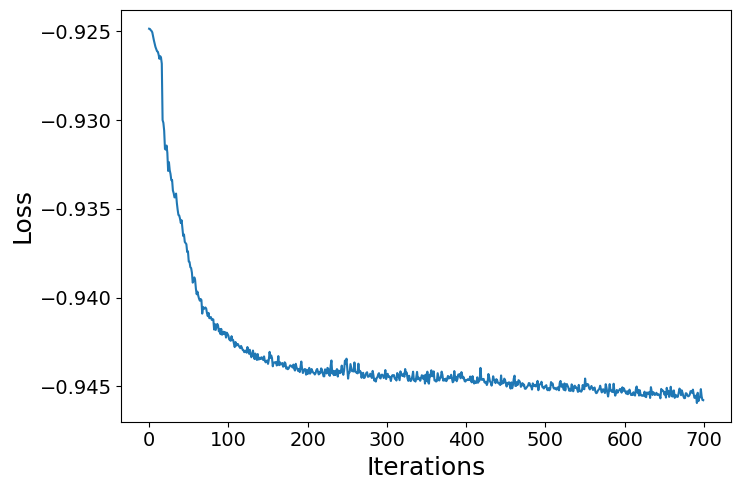

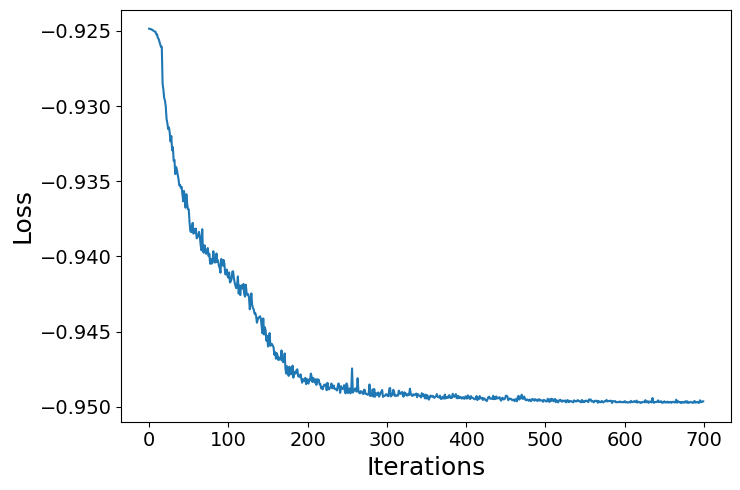

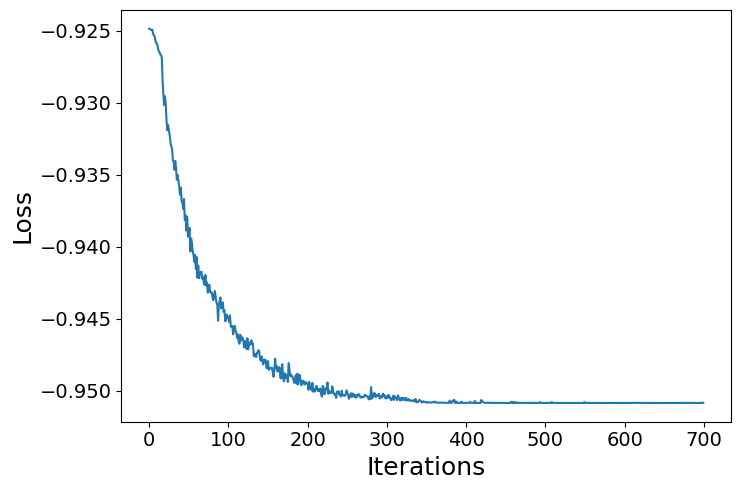

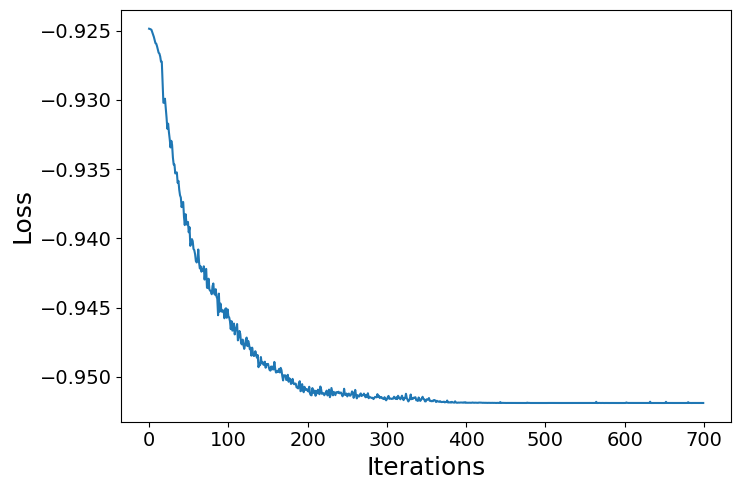

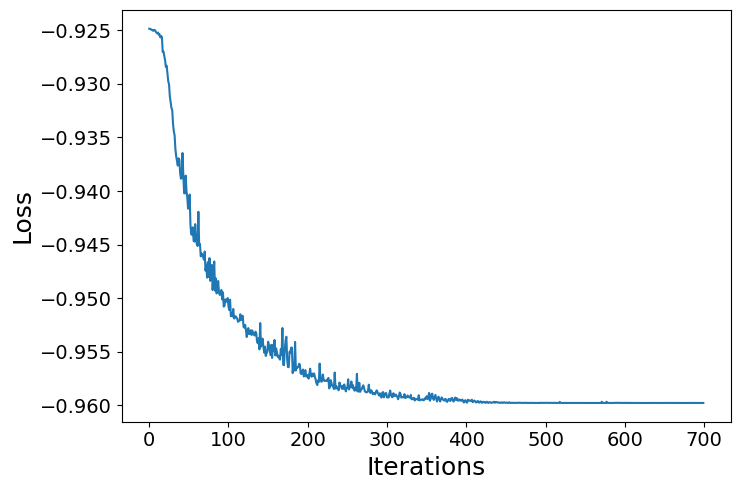

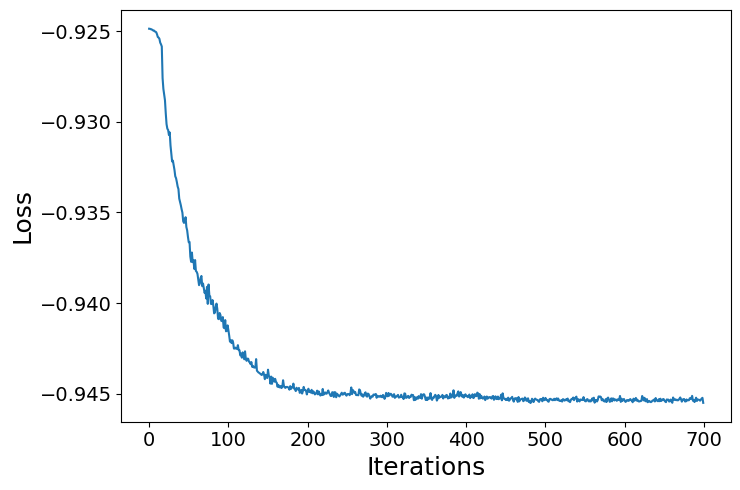

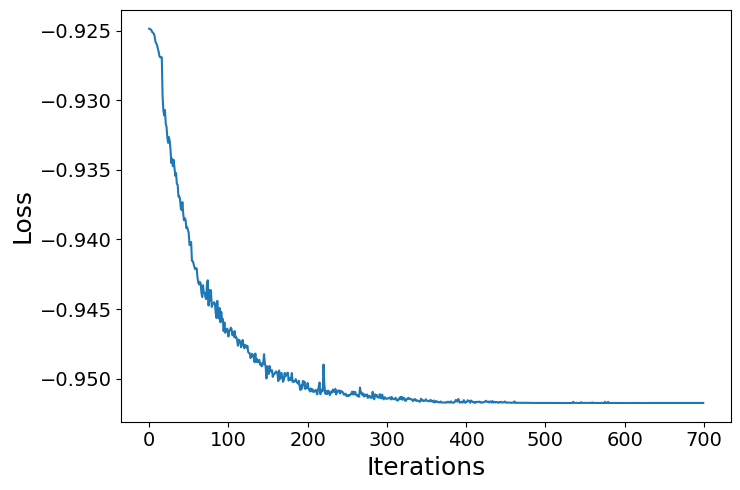

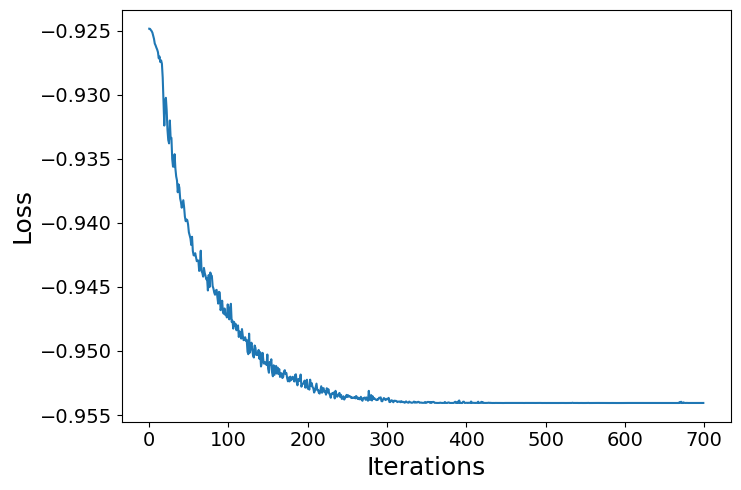

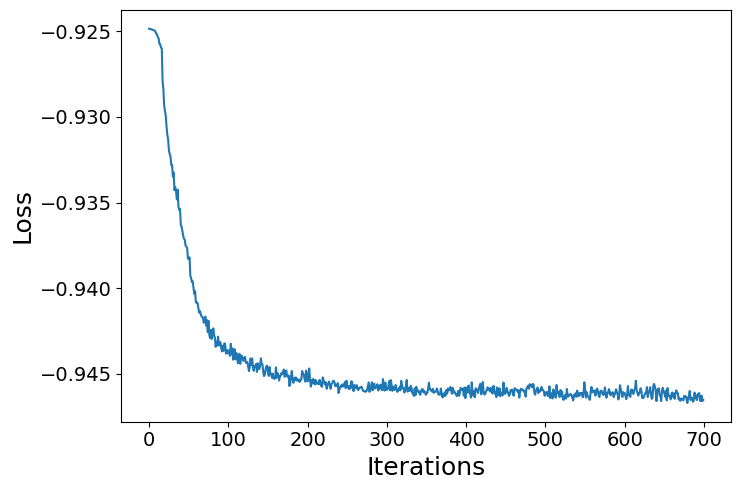

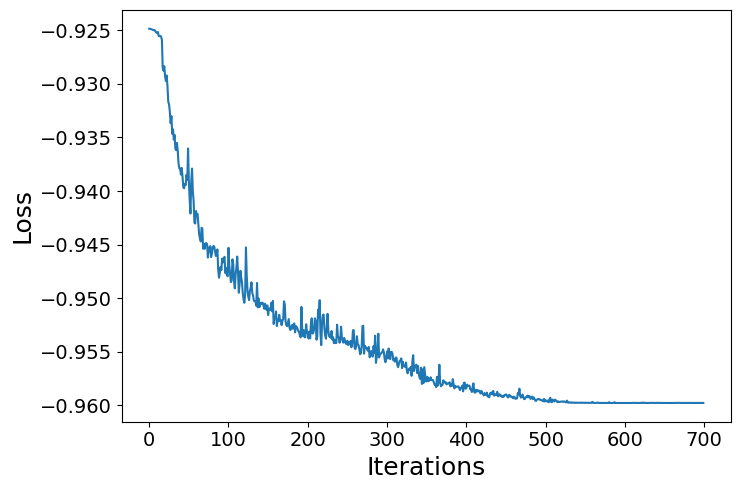

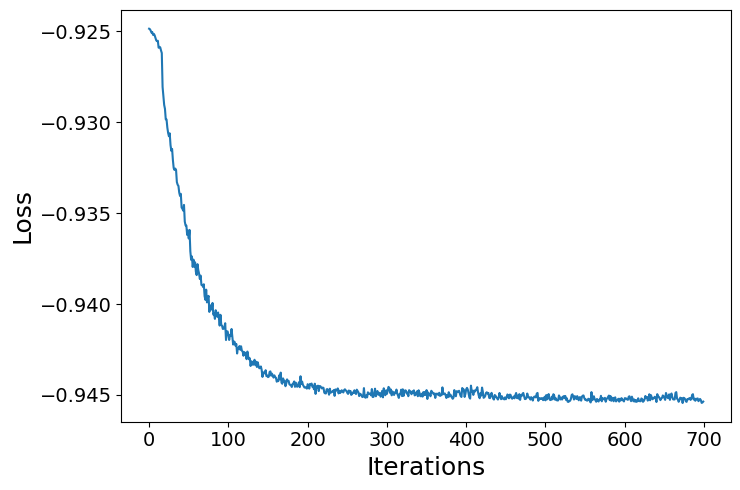

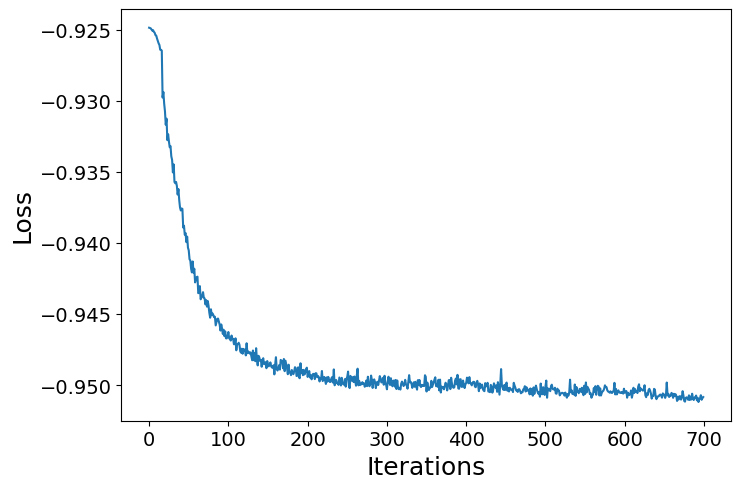

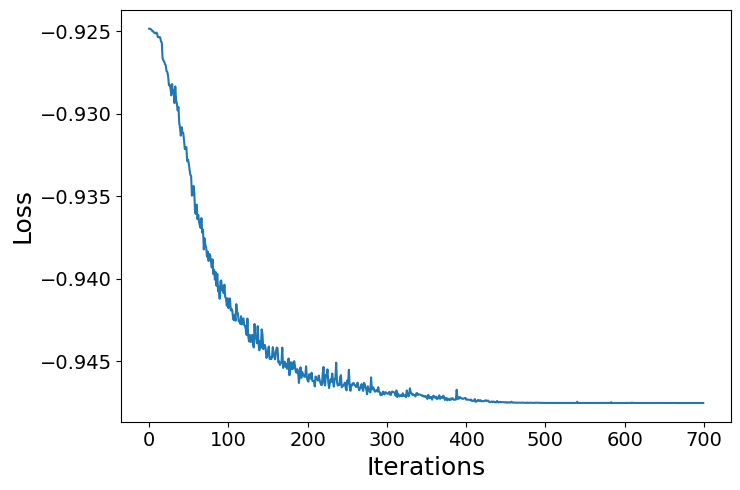

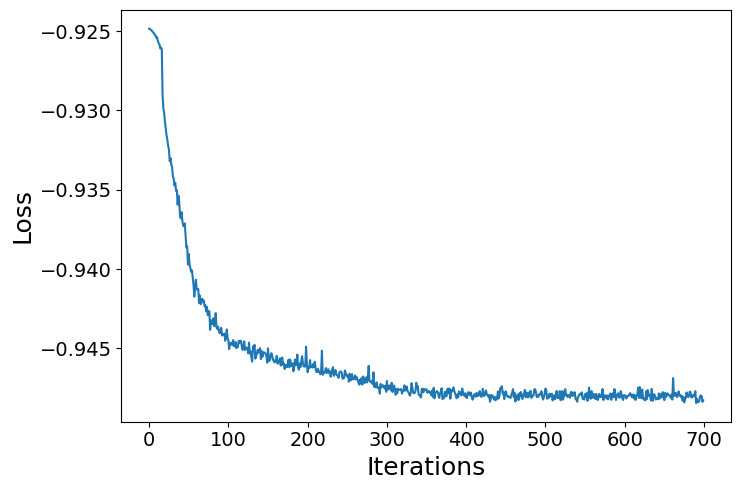

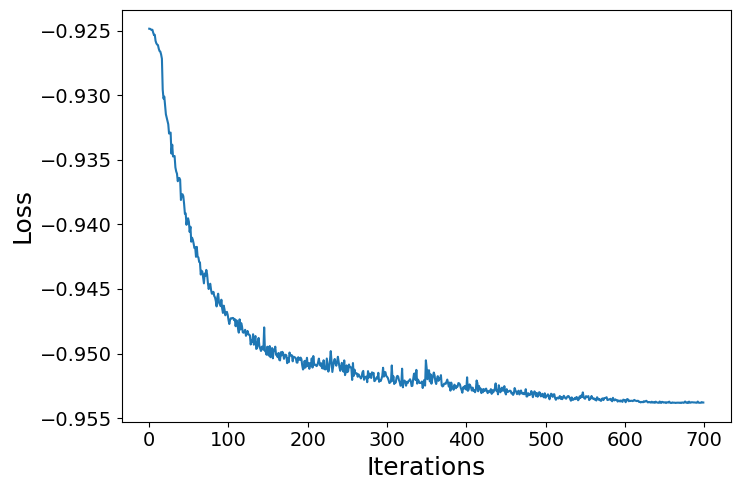

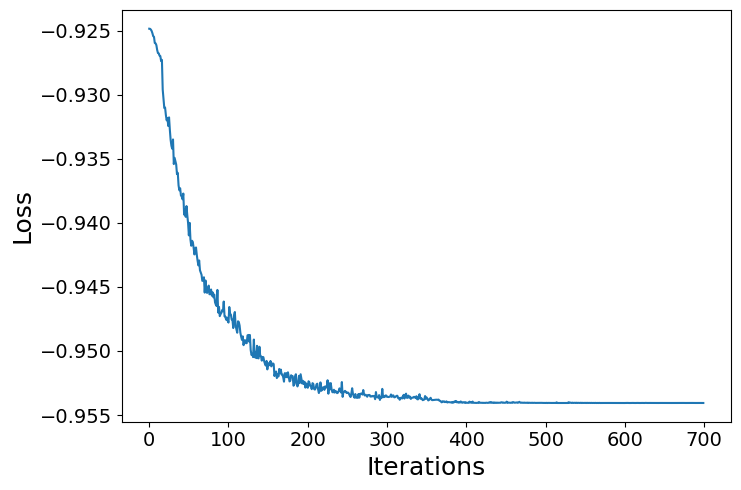

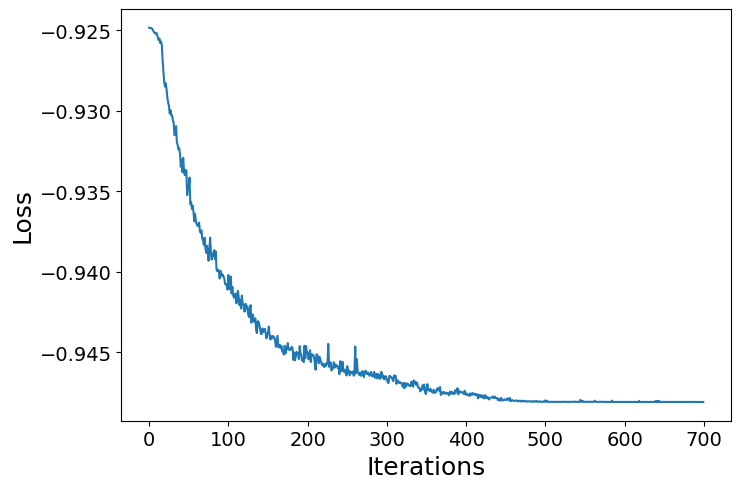

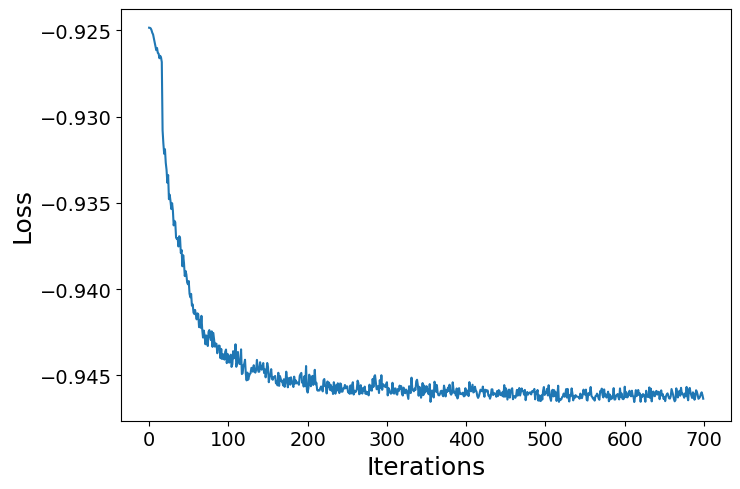

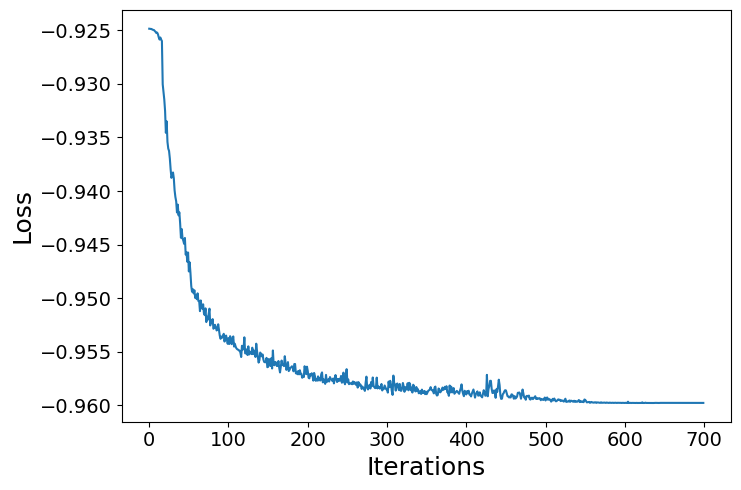

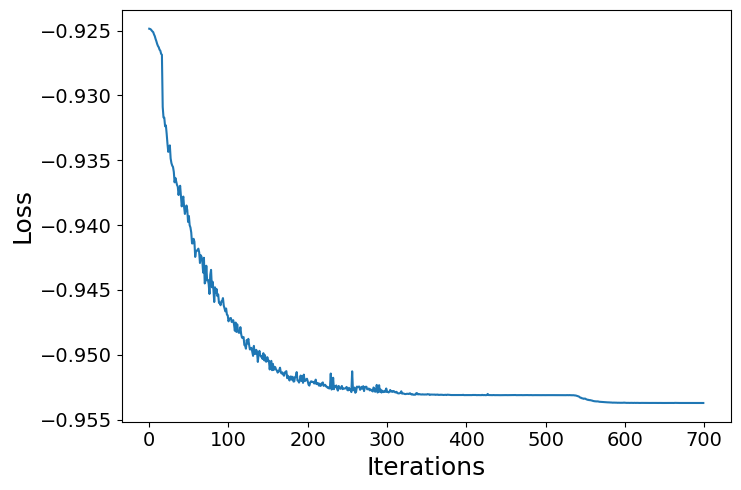

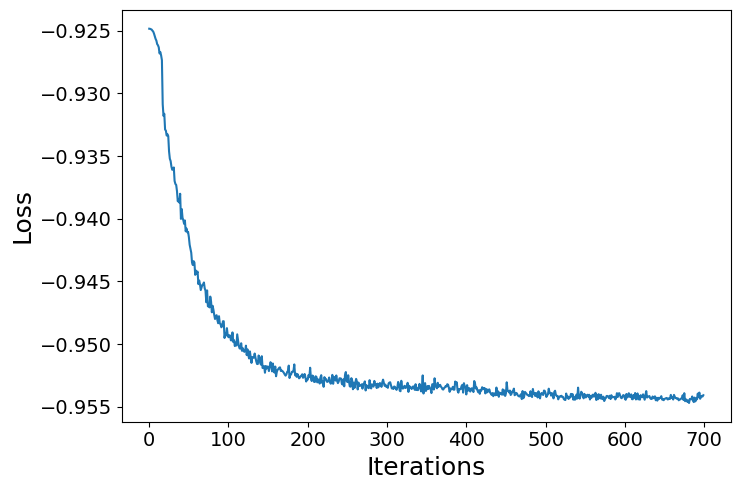

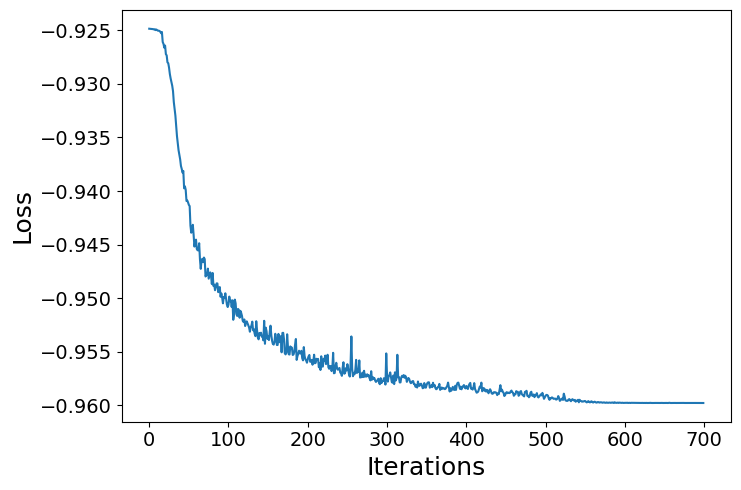

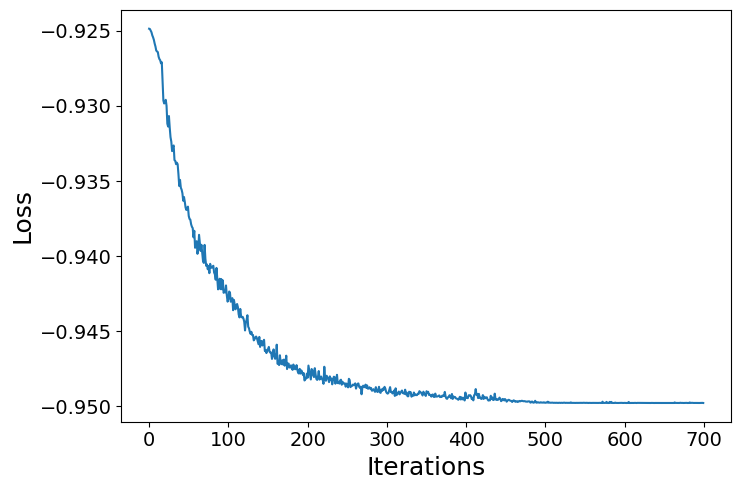

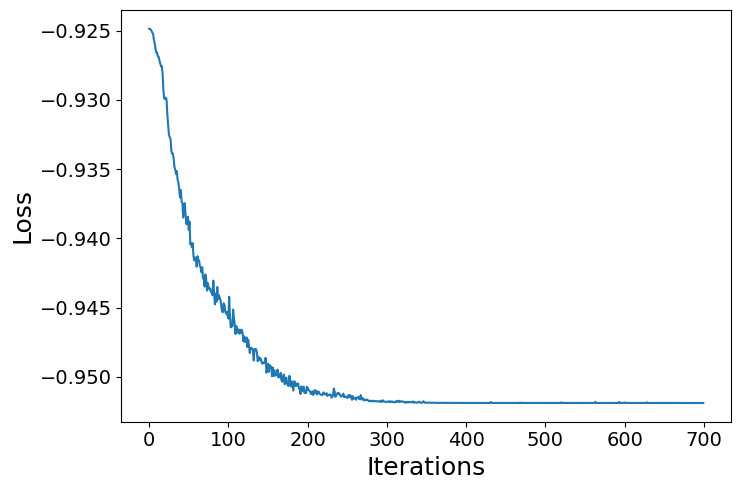

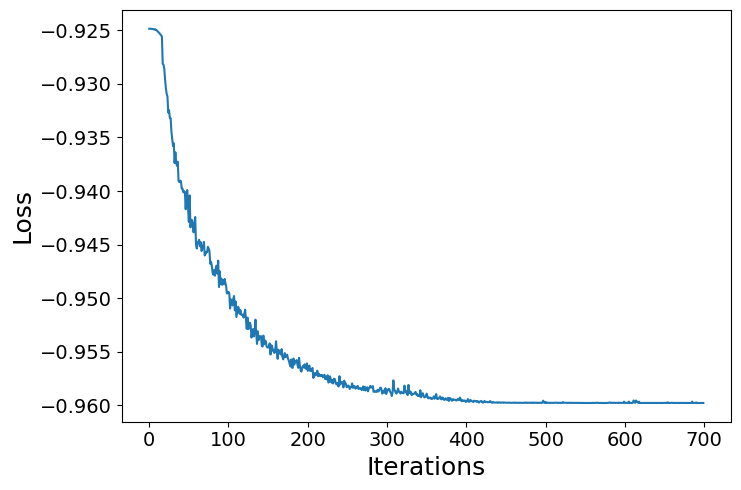

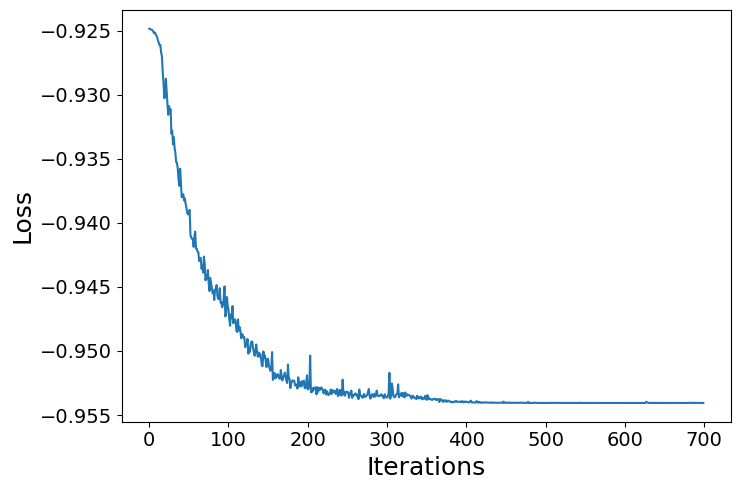

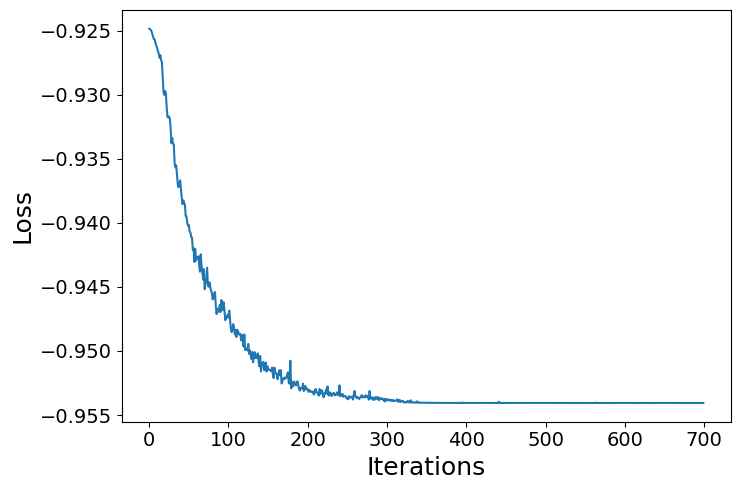

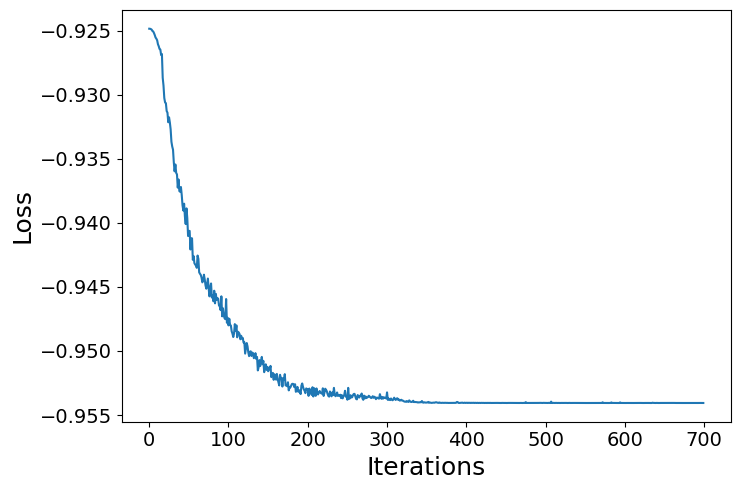

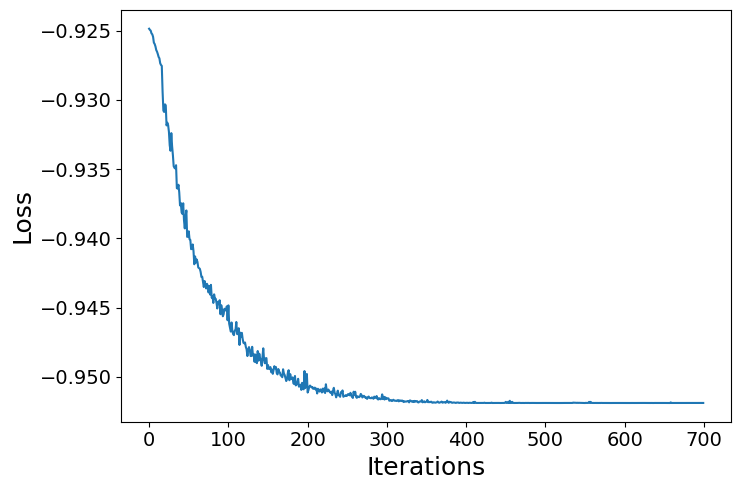

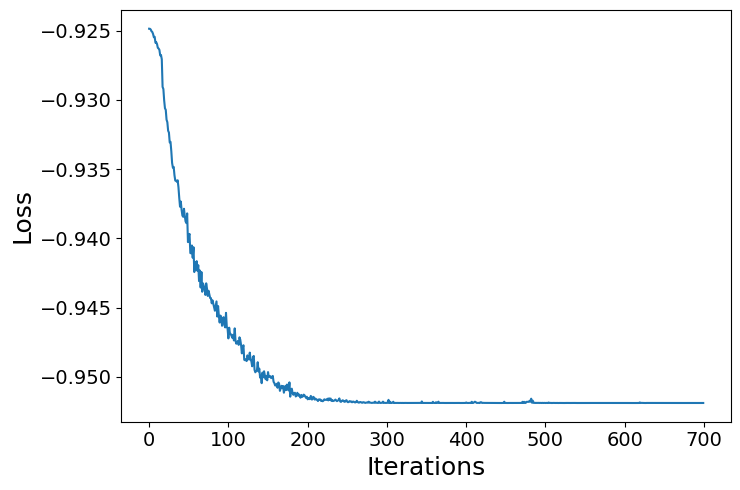

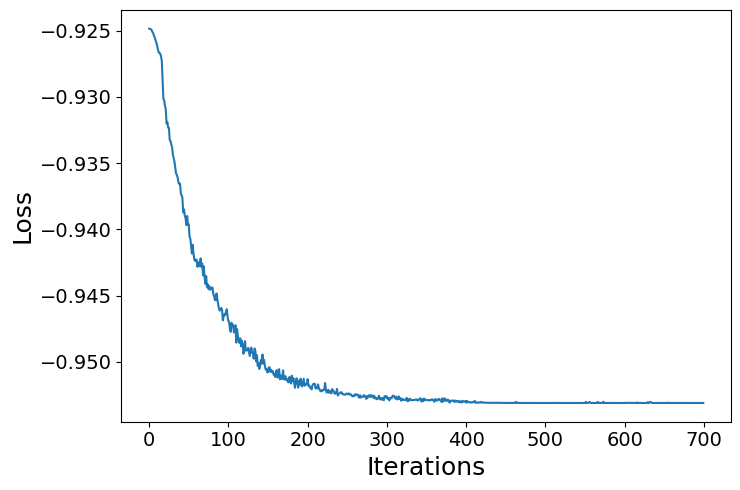

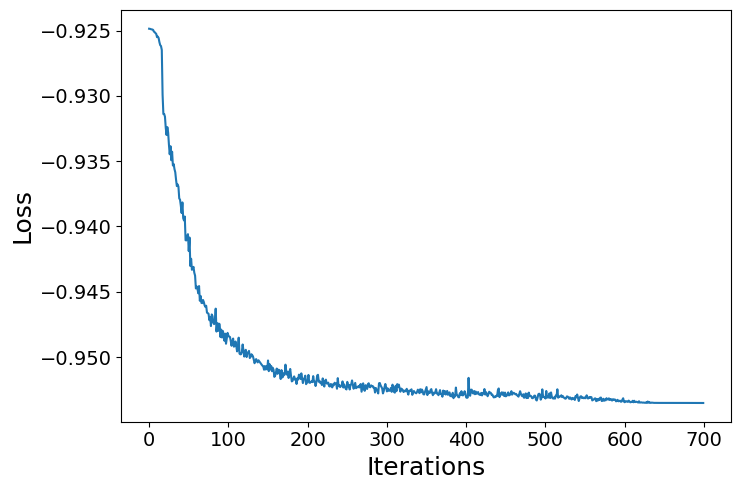

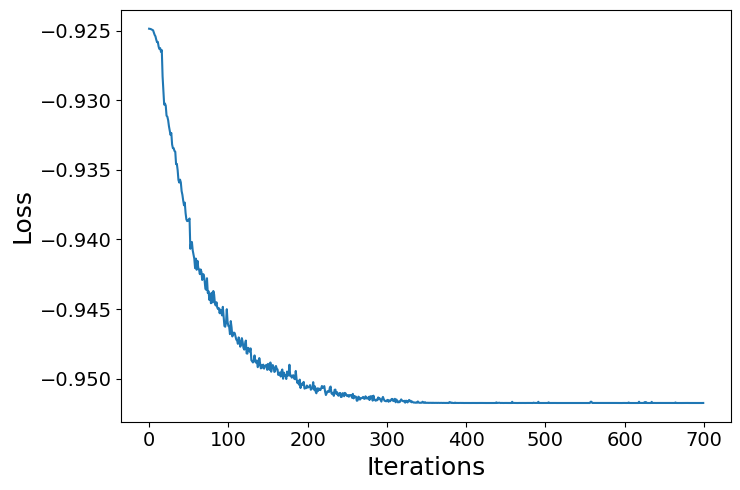

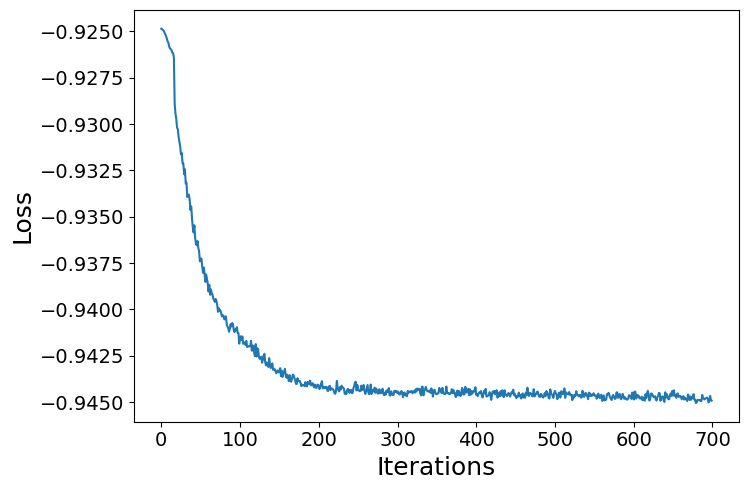

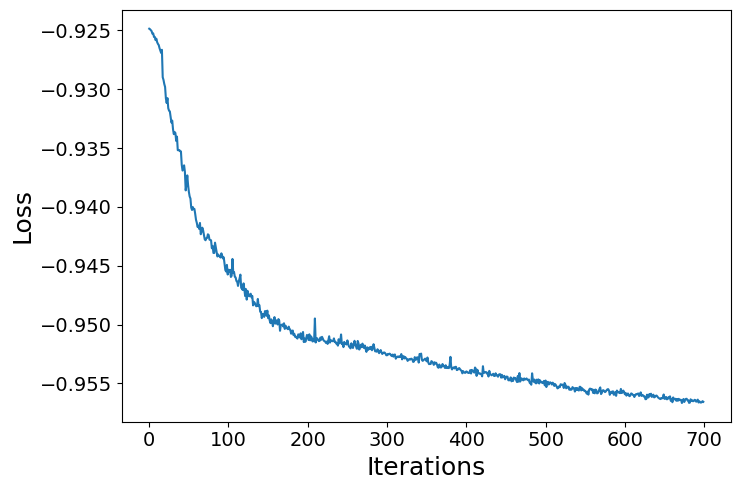

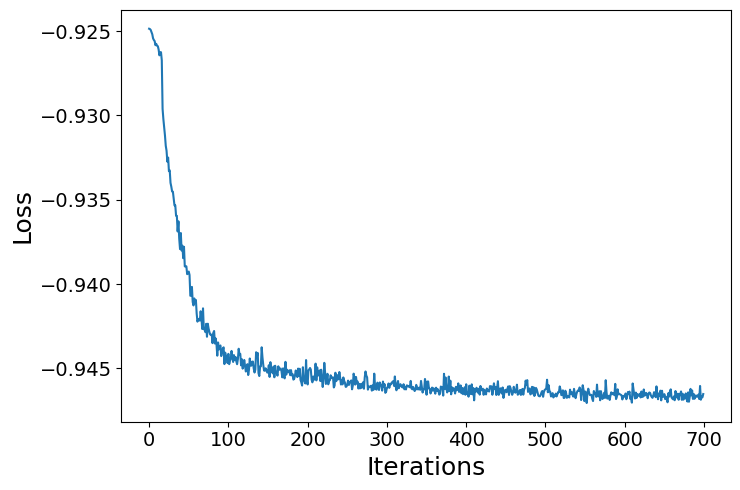

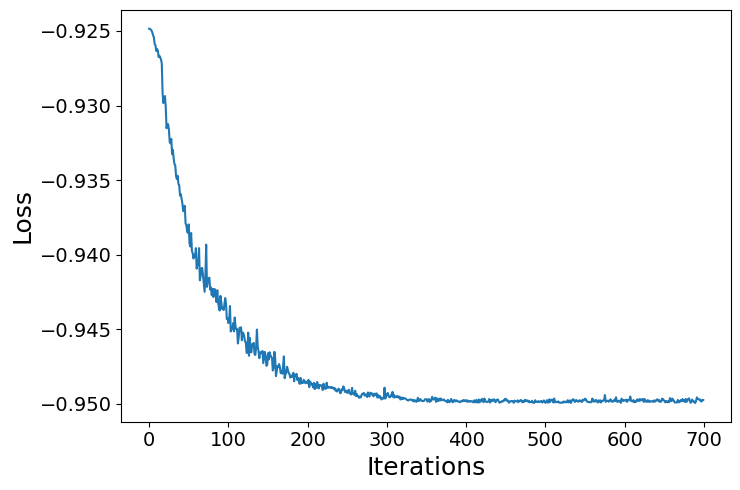

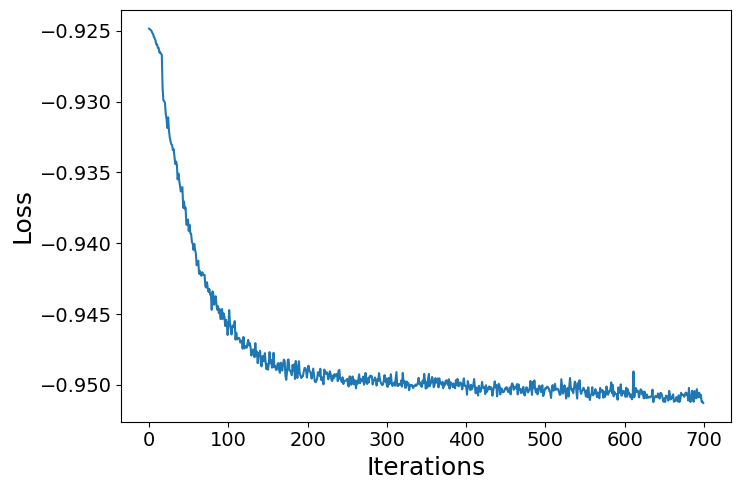

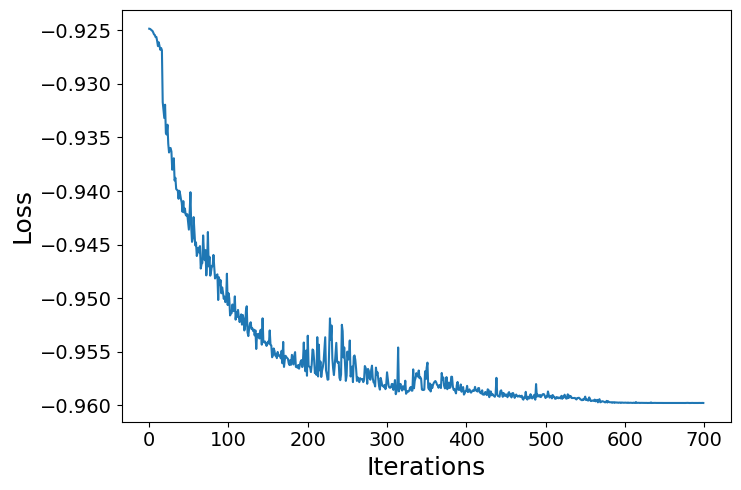

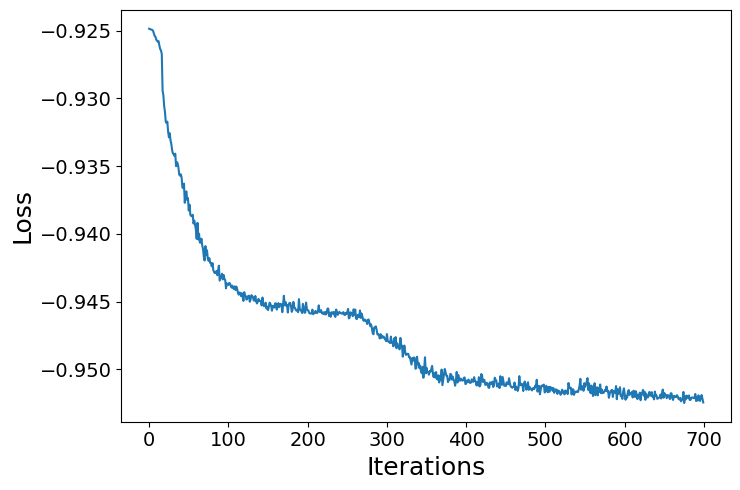

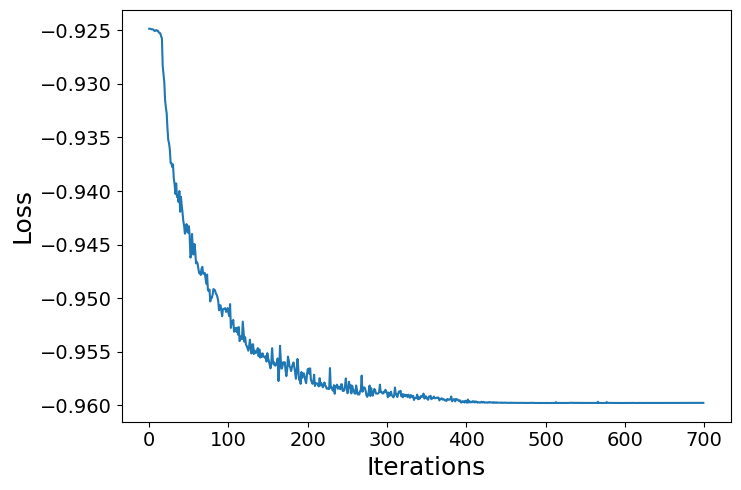

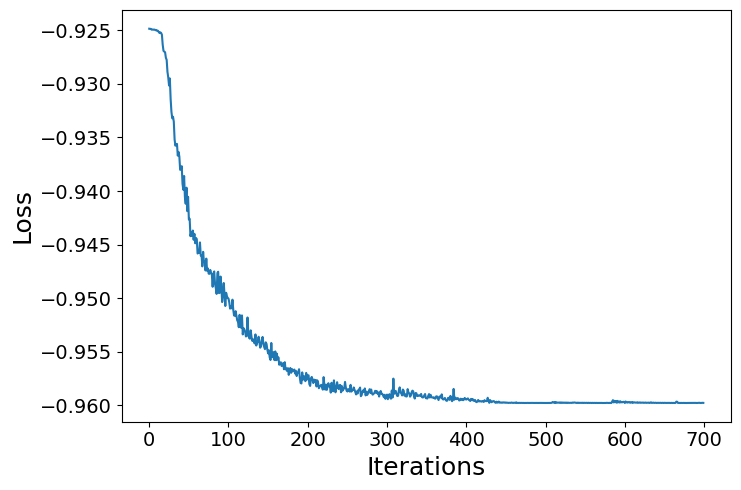

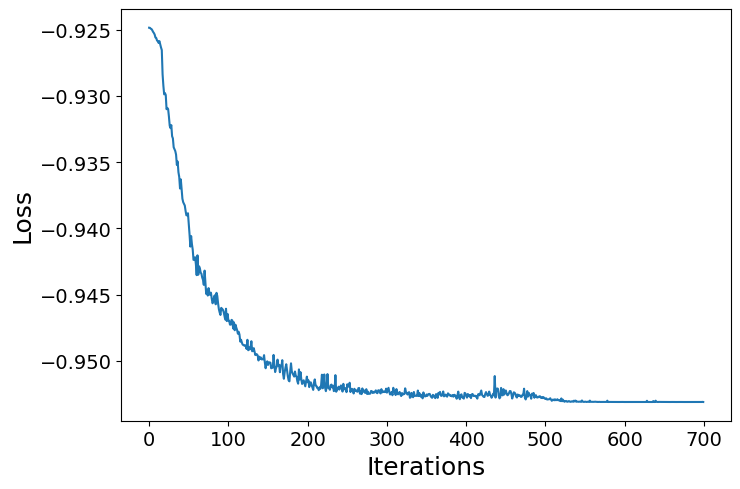

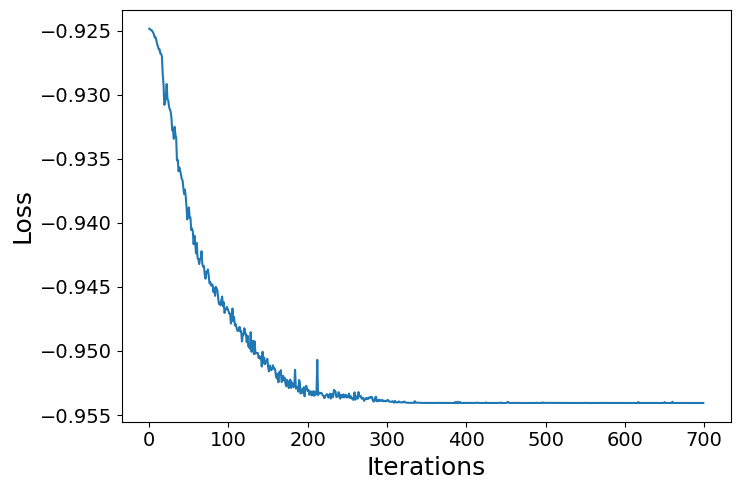

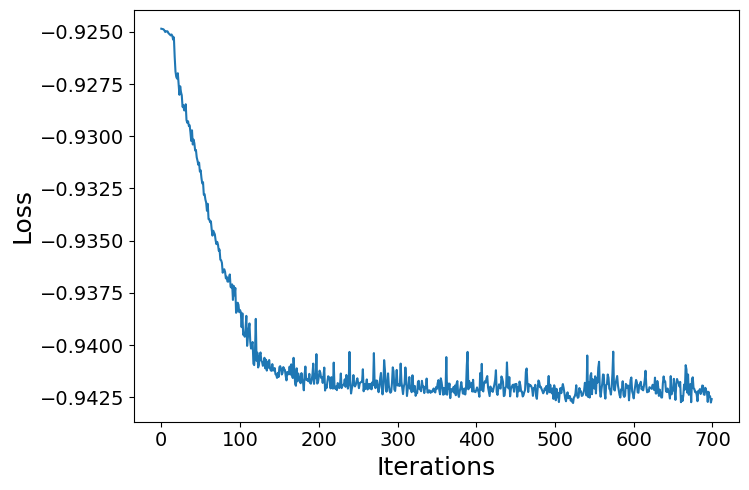

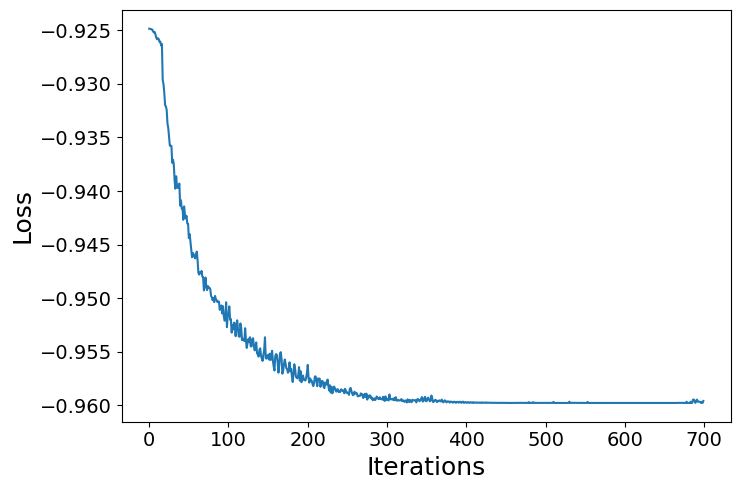

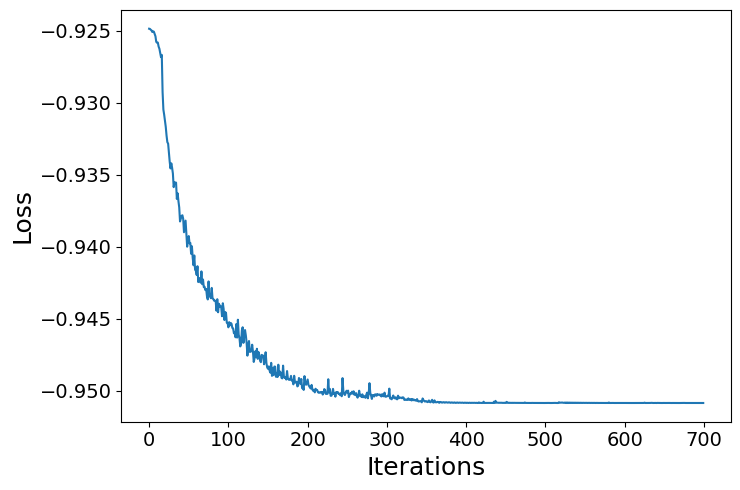

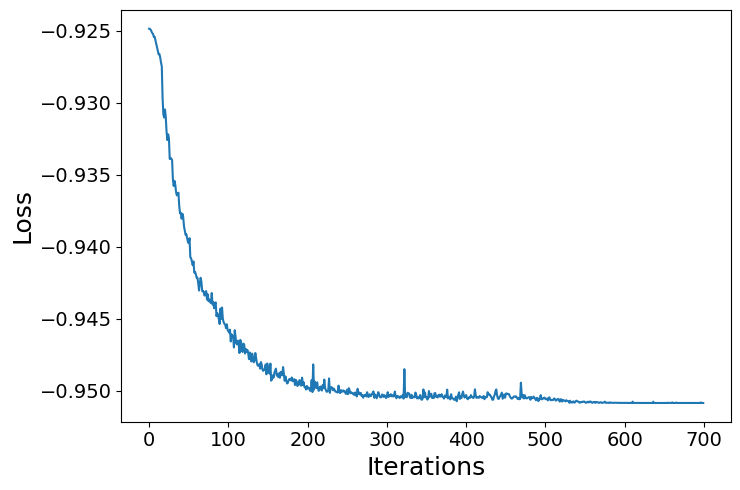

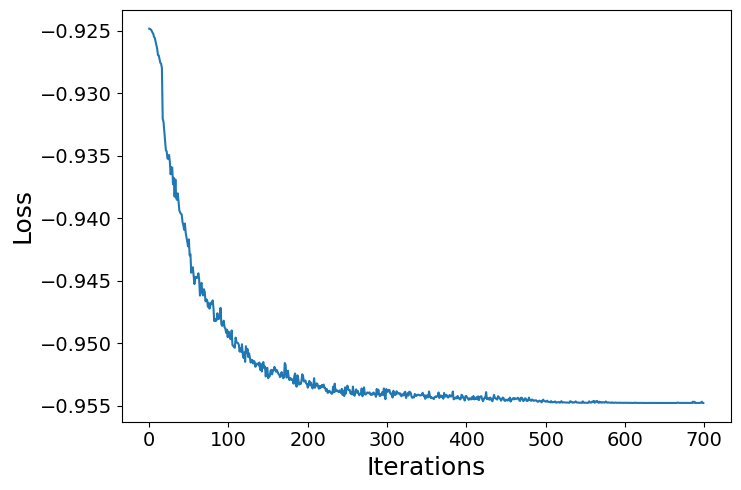

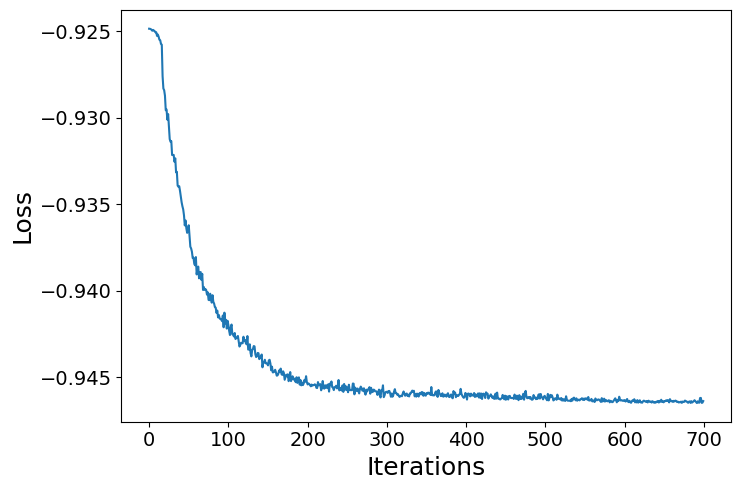

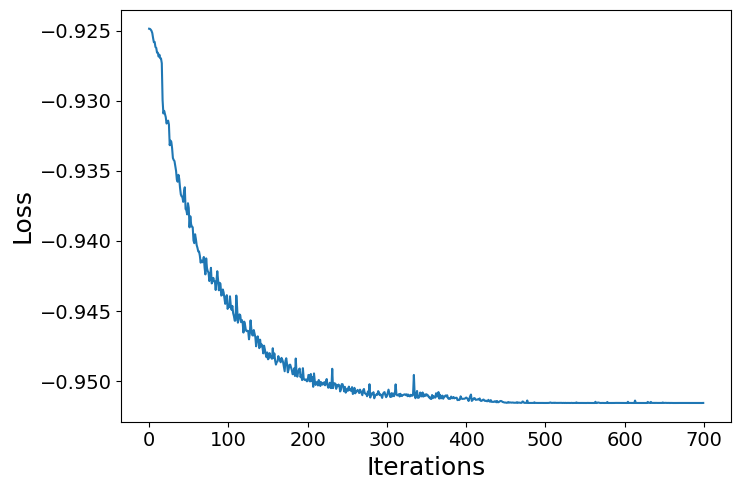

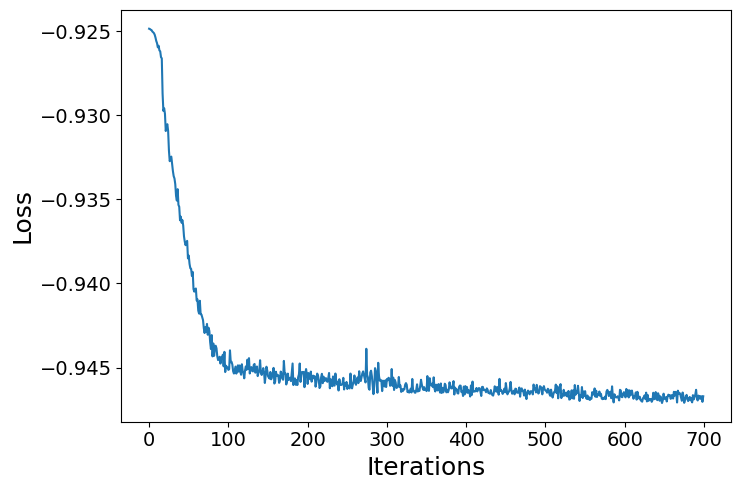

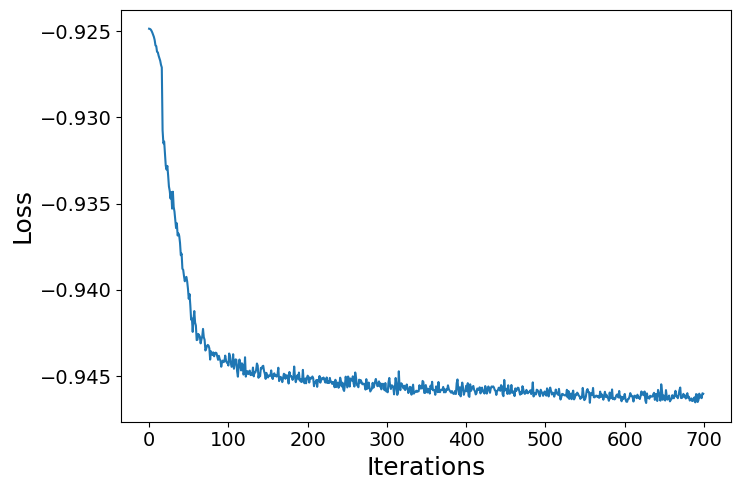

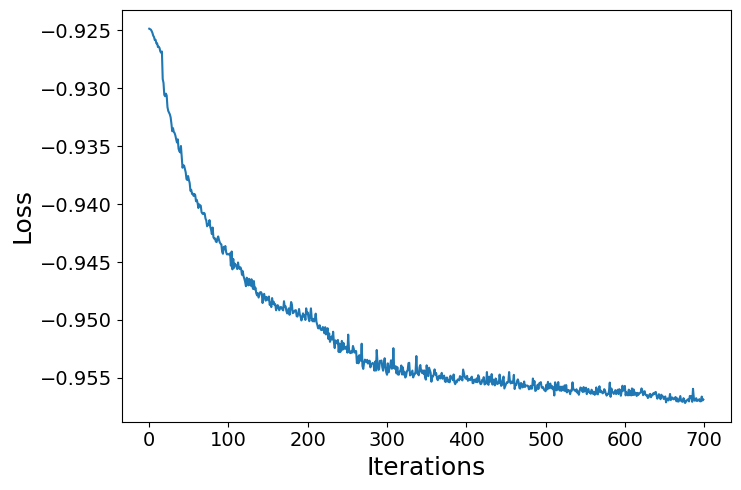

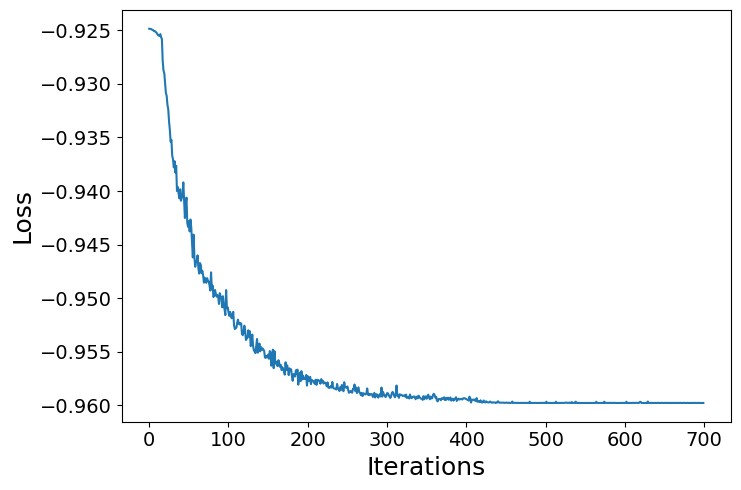

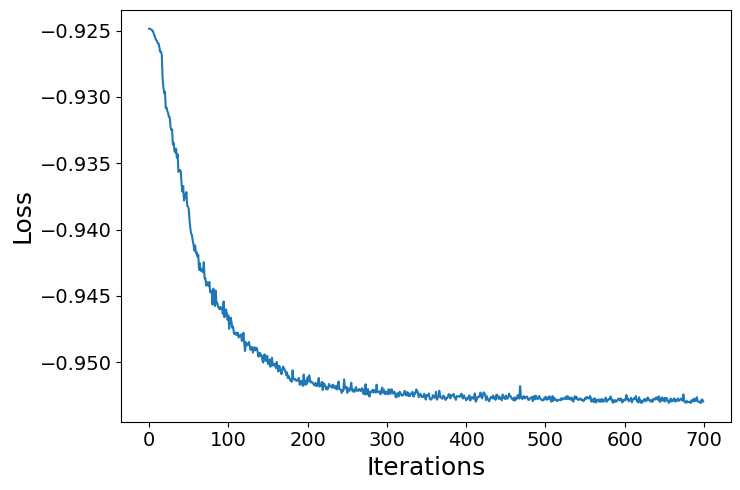

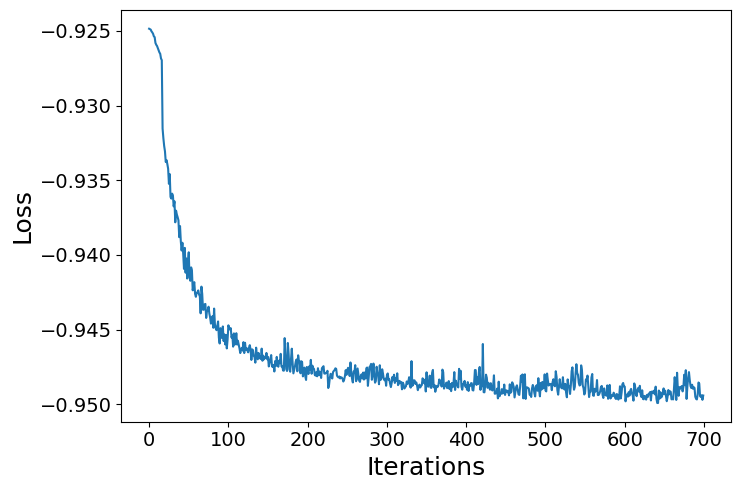

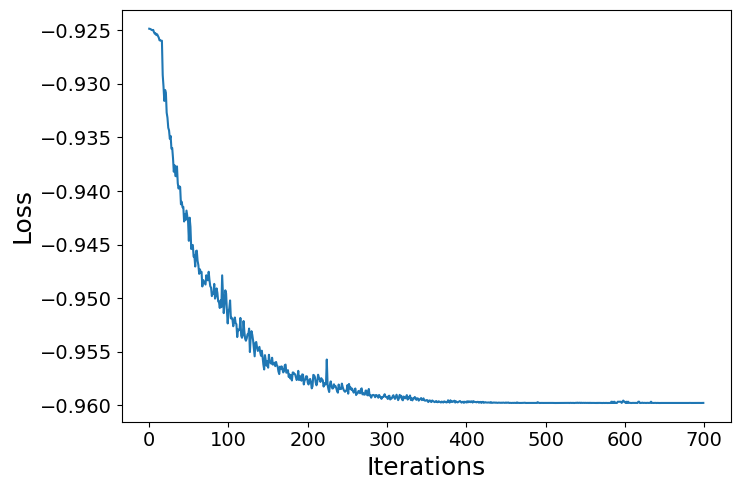

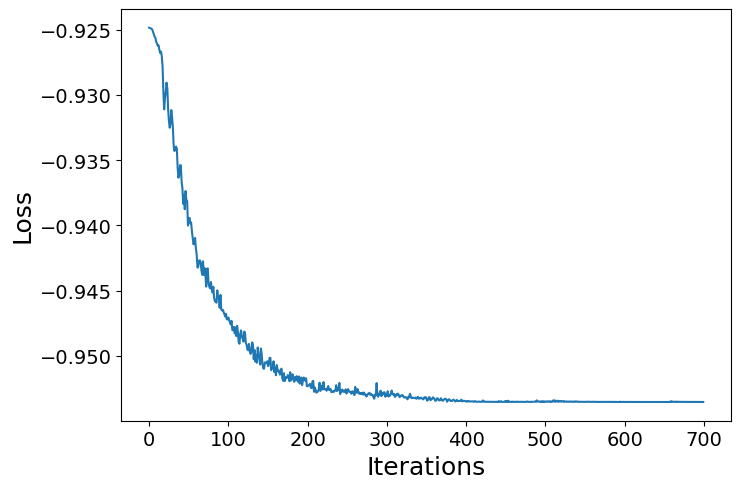

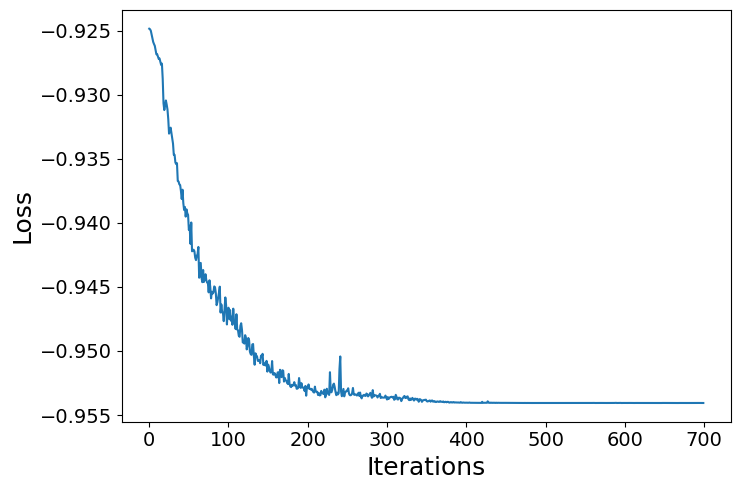

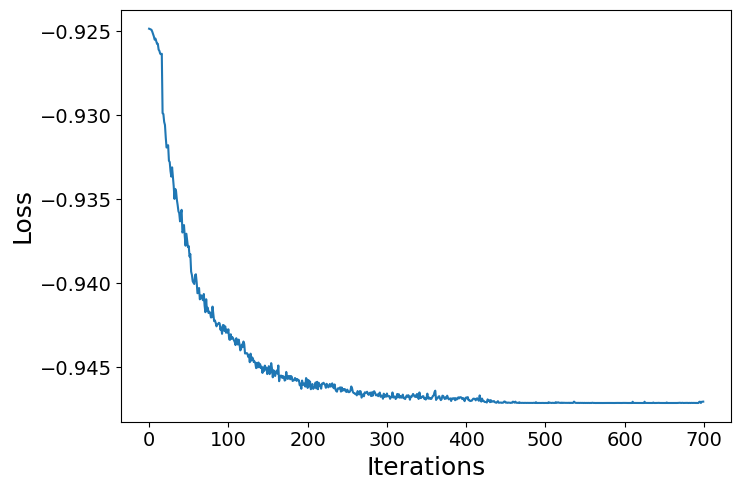

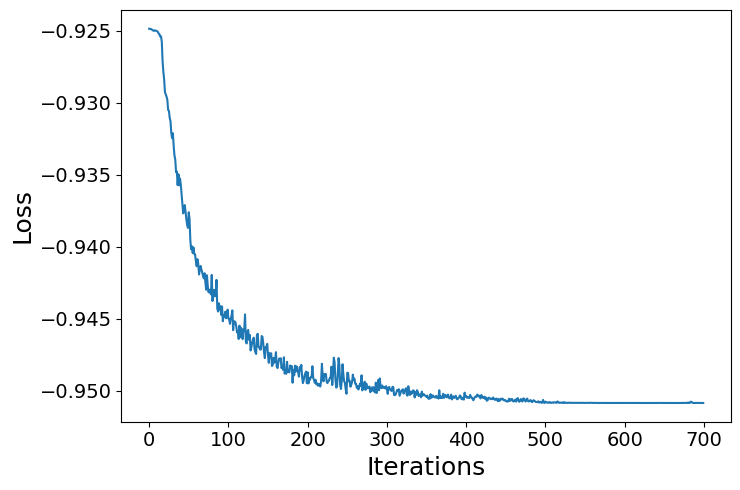

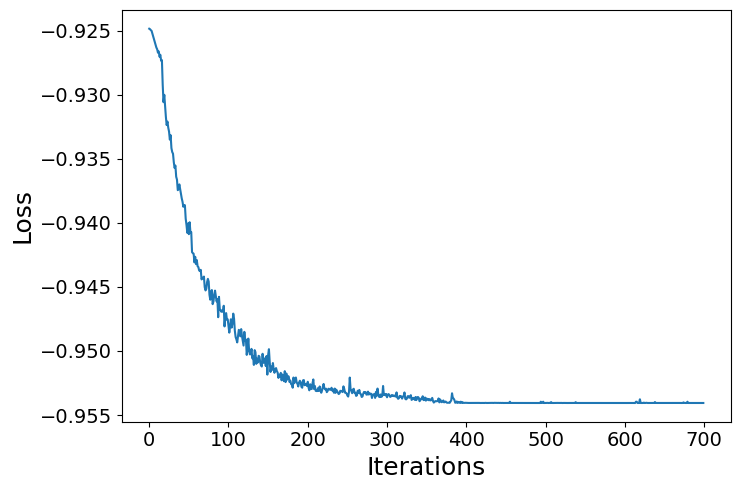

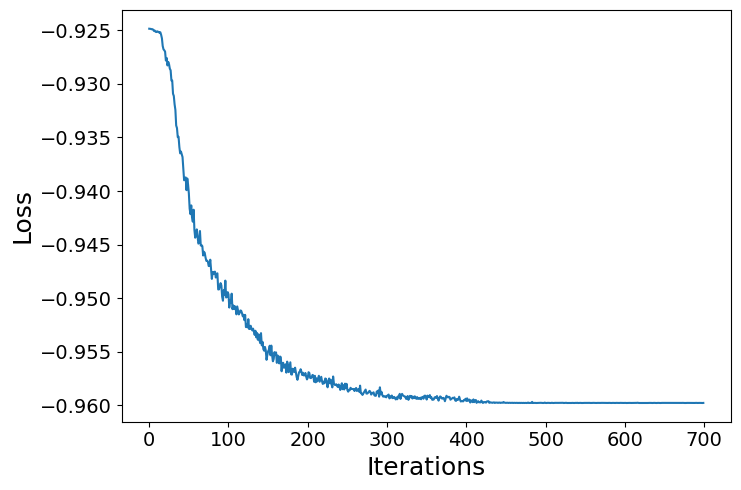

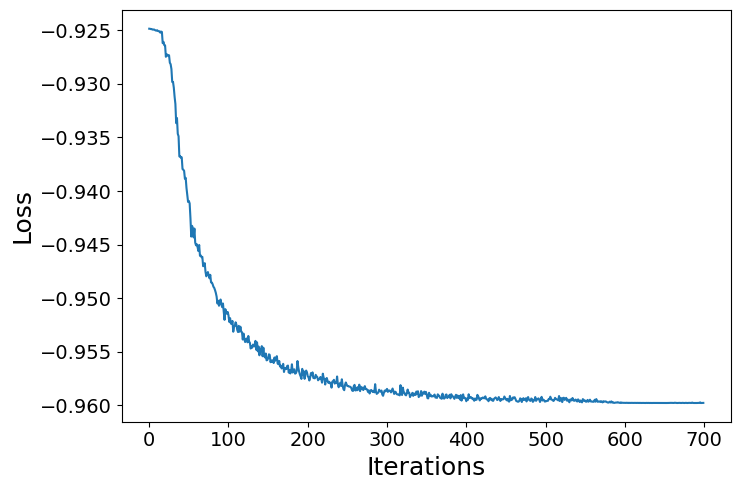

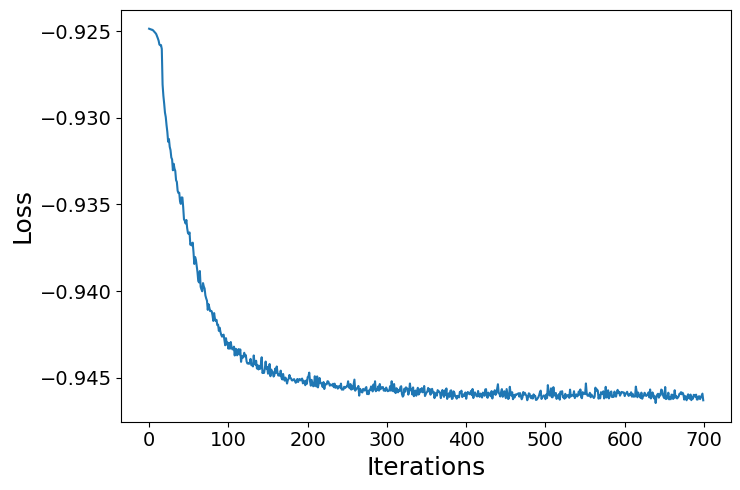

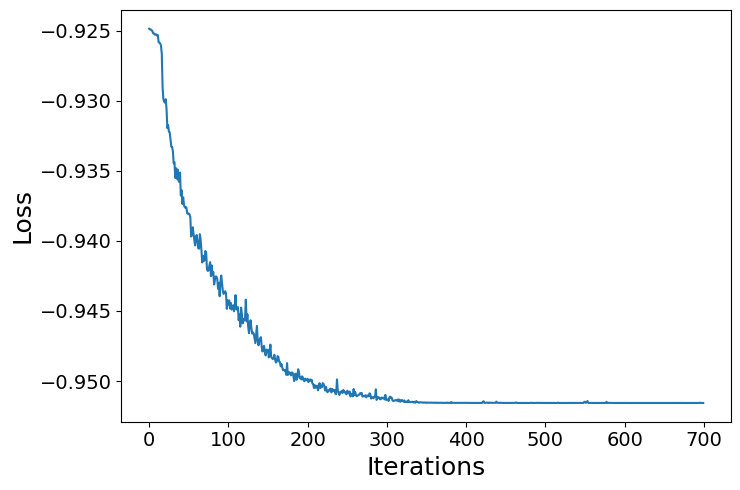

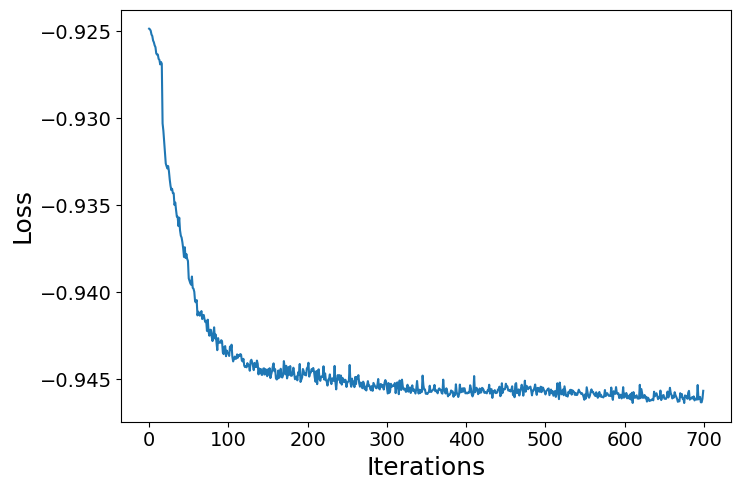

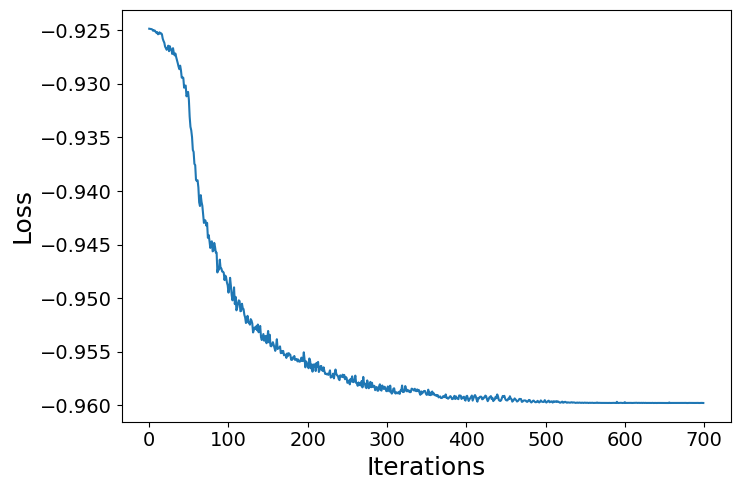

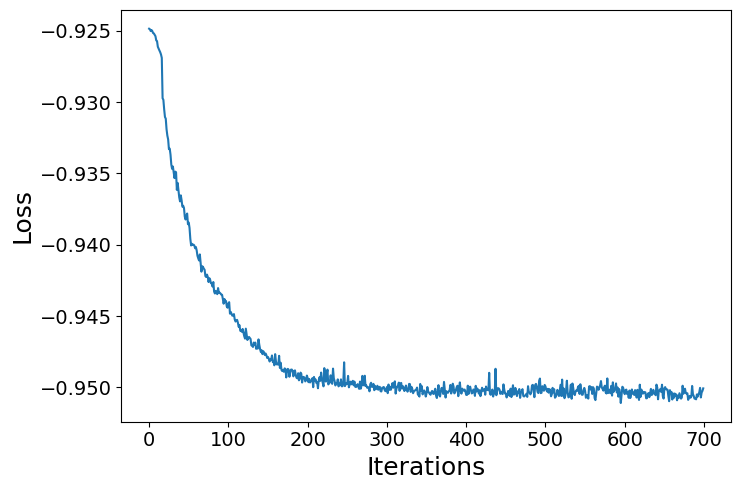

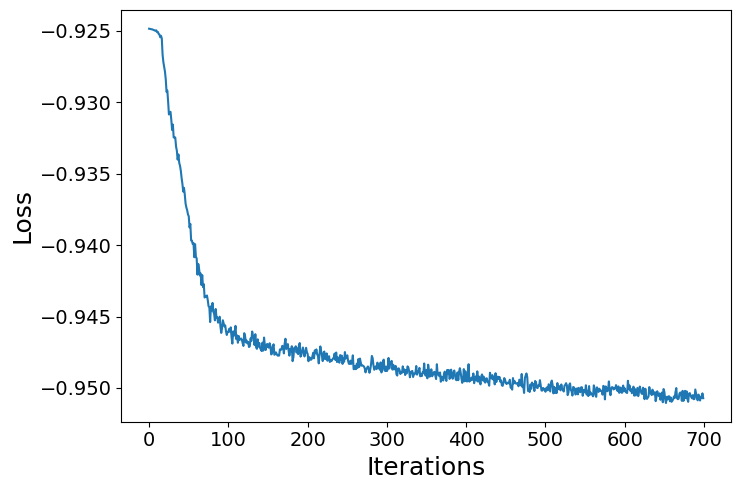

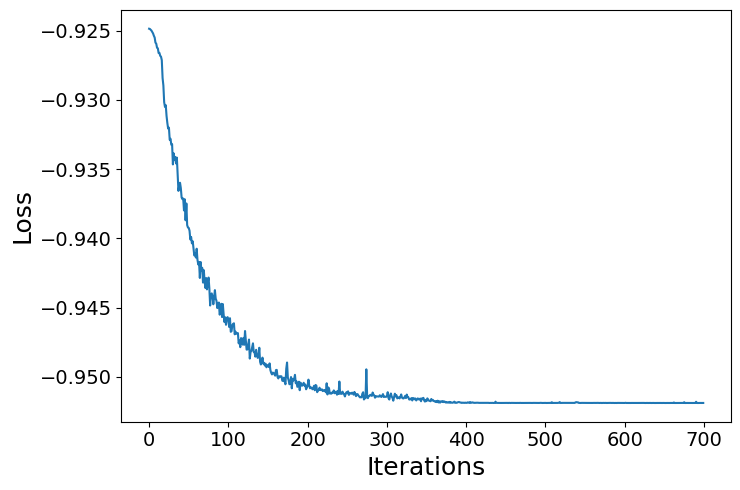

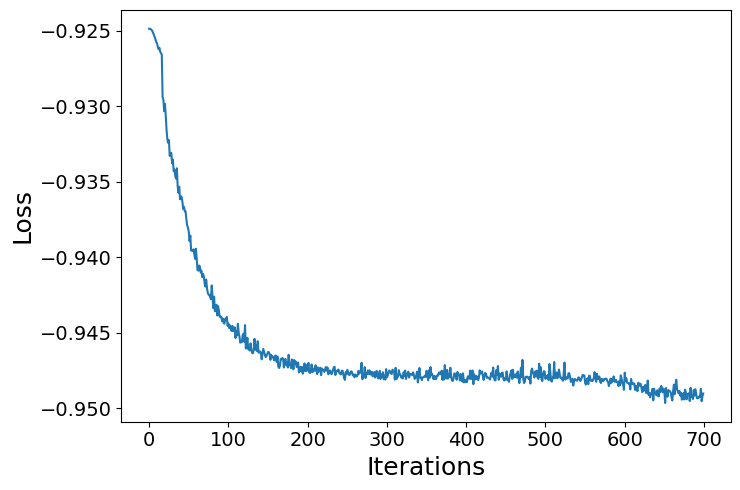

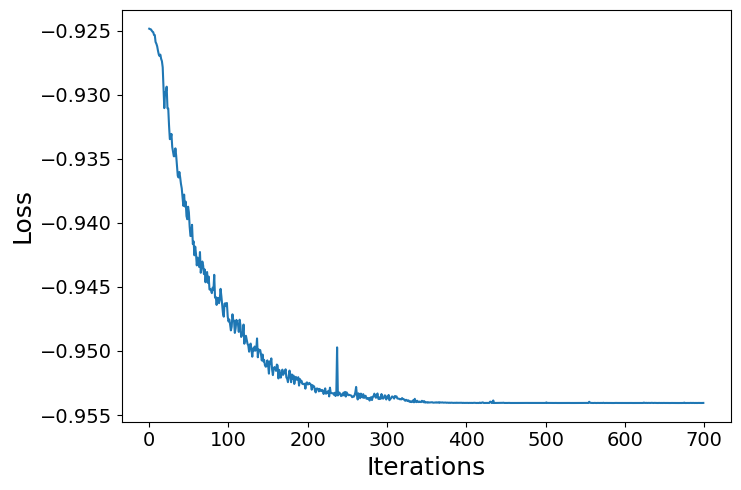

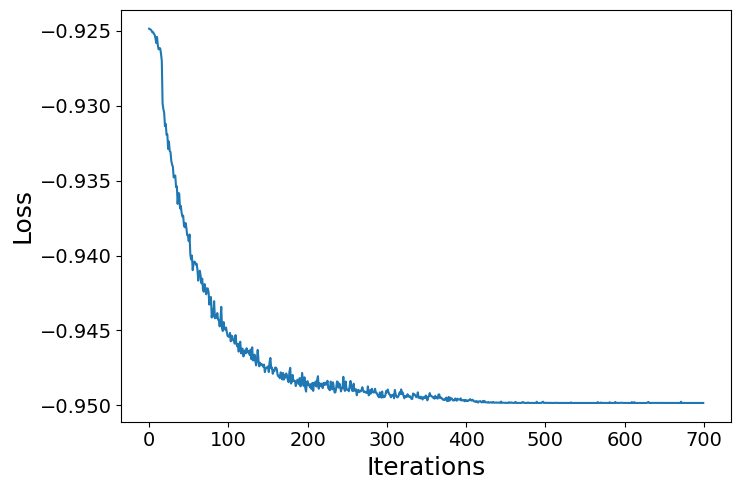

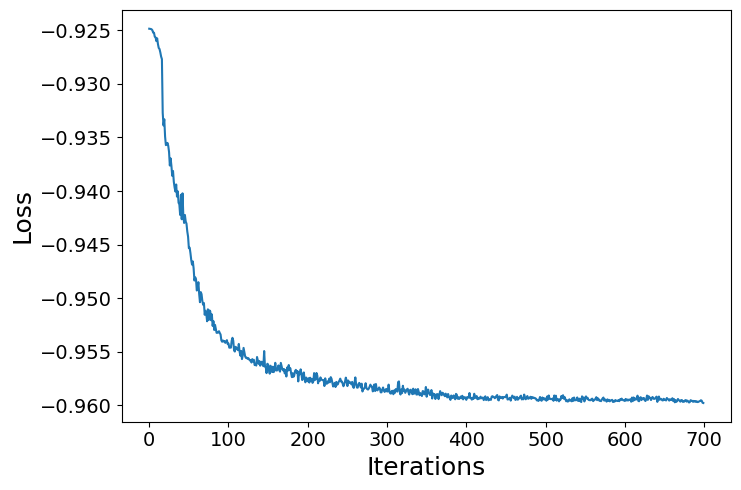

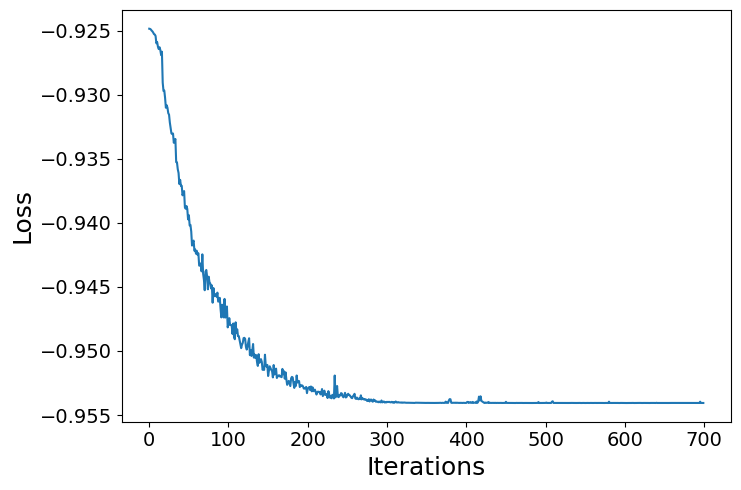

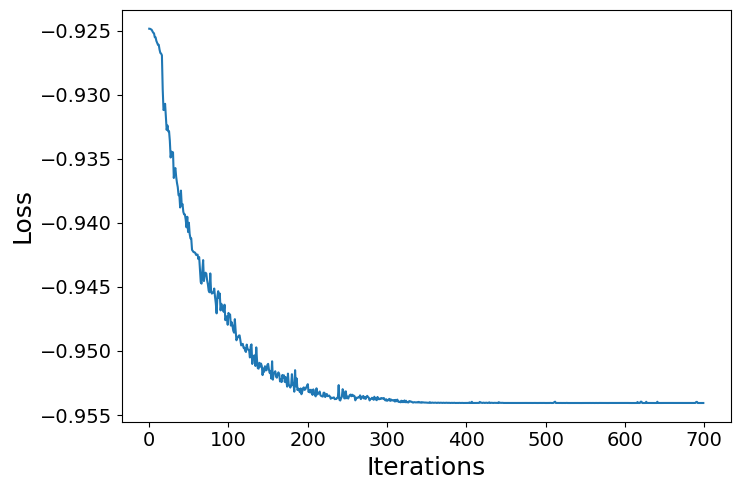

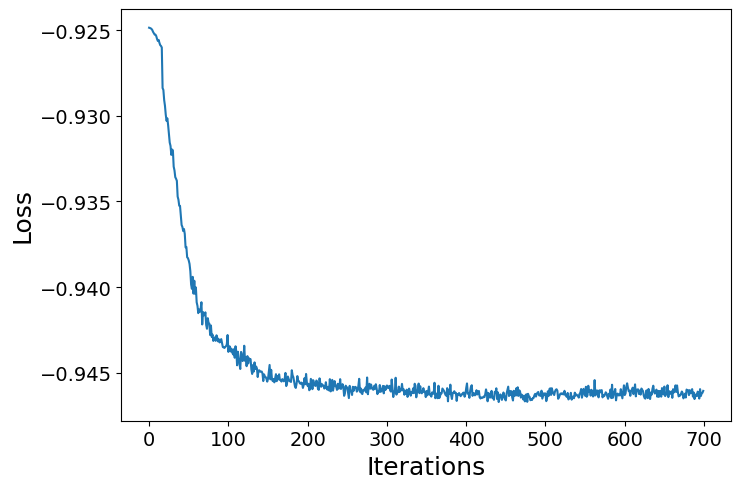

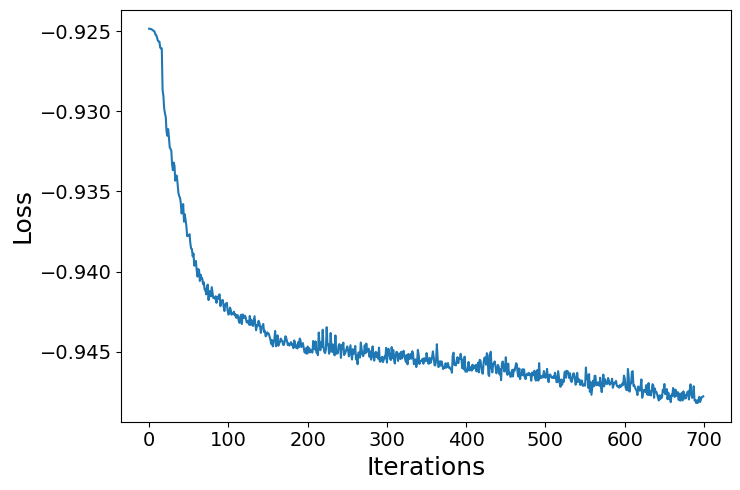

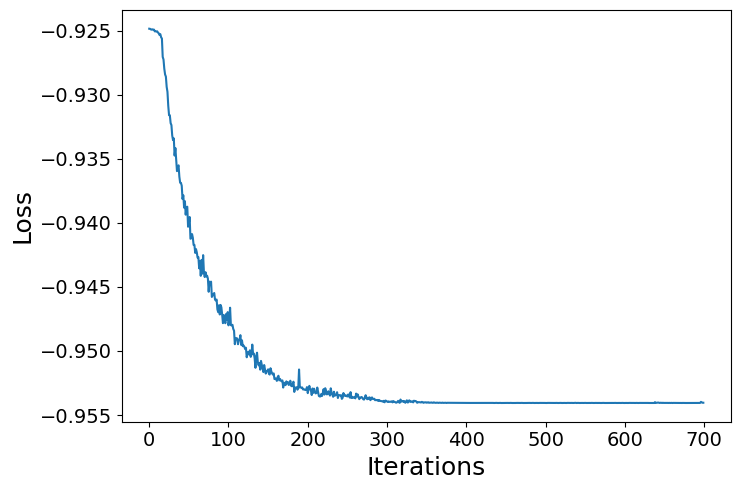

In [8]:
for seed in range(1,200,1):
    params.seed = seed
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.mkdir(str(params.ruta)+'/seed_'+str(seed))
    for i in range(1):
        glonet = GLOnet(params)
        glonet.train()
        glonet.viz_training()